In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose,STL
from scipy.stats import kendalltau
from dateutil.parser import parse
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LinearRegression

In [2]:
patients=[1135, 1450, 1464, 1497, 1504, 
          1511, 1541, 1559, 1572, 1582, 
          1586, 1603, 1607, 1609,1615, 
          1617, 1628, 1657, 1660, 1706]

In [3]:
# physical_patients=[1541,1559, 1572, 1582, 1586, 1592,1617, 1706] #1541,1559, 1572, 1582, 1586, 1592,1617, 1706

# Clinical information

To classify users based on their health status changes over multiple years, we'll develop a strategy to categorize them into:

* Users who remain healthy across all available years.
* Users who transition from healthy to MCI.
* Users who remain with MCI status throughout the observed years.

In [4]:
def read_clinical():
    clinical = pd.read_csv('filtered_clinical.csv', index_col=0)
    # Create a new order for the columns
    new_columns = ['sub_id']+['home_id'] +['study'] +[col for col in clinical.columns if (col != 'home_id' and col !='sub_id' and col != 'study')]
    # Reorder the DataFrame
    clinical = clinical[new_columns]
    
    
    return clinical

In [5]:
def find_truth(baseline_info):
    # Initialize the dictionary
    ground_truth_baseline = {}
    # Populate the dictionary
    for index, row in baseline_info.iterrows():
        patient = row['home_id']
        if patient in patients:  # Check if the patient is in the list of interest
            if patient not in ground_truth_baseline:
                ground_truth_baseline[patient] = {}  # Initialize a dictionary for this patient if not already present
            # Add date and conditions to the patient's dictionary
            ground_truth_baseline[patient][row['date_screen']] = [row['othcondx'], row['cogothx']]
    return ground_truth_baseline


def MCI_user(ground_truth_baseline):
    # List to store users (home_ids) with 'MCI' without NaN
    mci_users = {}
    healthy_users={}
    # Iterate through the dictionary
    for home_id, dates in ground_truth_baseline.items():
        for date, conditions in dates.items():
            # Check if the second element is not NaN
            if pd.notna(conditions[1]):  # Use pd.notna to check for non-NaN values effectively
#                 mci_users.append(home_id)
                mci_users[home_id]=date
            else:
                healthy_users[home_id]=date
    return mci_users,healthy_users


def unhealthy_user(ground_truth_baseline):
    # List to store users (home_ids) with 'MCI' without NaN
    unhealthy_users = []

    # Iterate through the dictionary
    for home_id, dates in ground_truth_baseline.items():
        for date, conditions in dates.items():
            # Check if the second element is not NaN
            if pd.notna(conditions[0]):  # Use pd.notna to check for non-NaN values effectively
                unhealthy_users.append(home_id)
    return unhealthy_users

In [6]:
clinical=read_clinical()
filtered_clinical=clinical[clinical['home_id'].isin(patients)]
# filtered_clinical

In [7]:
# find info
baseline_info=filtered_clinical[filtered_clinical['redcap_event_name']=='baseline_visit_arm_1']
second_year=filtered_clinical[filtered_clinical['redcap_event_name']=='month_12_arm_1']
third_year=filtered_clinical[filtered_clinical['redcap_event_name']=='month_24_arm_1']

In [8]:
ground_truth_baseline=find_truth(baseline_info)
# ground_truth_baseline
ground_truth_second_year=find_truth(second_year)
# ground_truth_second_year
ground_truth_third_year=find_truth(third_year)
# ground_truth_third_year

In [9]:
ground_truth_baseline=find_truth(baseline_info)
# ground_truth_baseline
ground_truth_second_year=find_truth(second_year)
# ground_truth_second_year
ground_truth_third_year=find_truth(third_year)
# ground_truth_third_year

In [10]:
mci_users_baseline,healthy_users_baseline= MCI_user(ground_truth_baseline)
# mci_users_baseline,healthy_users_baseline

mci_users_second_year,healthy_users_second_year= MCI_user(ground_truth_second_year)
# mci_users_second_year,healthy_users_second_year

mci_users_third_year,healthy_users_third_year= MCI_user(ground_truth_third_year)
# mci_users_third_year,healthy_users_third_year

# Convert all dictionary dates to datetime
healthy_users_baseline = {k: pd.to_datetime(v) for k, v in healthy_users_baseline.items()}
healthy_users_second_year = {k: pd.to_datetime(v) for k, v in healthy_users_second_year.items()}
mci_users_baseline = {k: pd.to_datetime(v) for k, v in mci_users_baseline.items()}
mci_users_second_year = {k: pd.to_datetime(v) for k, v in mci_users_second_year.items()}

healthy_users_third_year = {k: pd.to_datetime(v) for k, v in healthy_users_third_year.items()}
mci_users_third_year = {k: pd.to_datetime(v) for k, v in mci_users_third_year.items()}

In [11]:
# Initialize classification dictionaries
all_healthy = {}
from_healthy_to_mci = {}
remain_mci = {}

# Check for all healthy
for user, date in healthy_users_baseline.items():
    if user in healthy_users_second_year and user in healthy_users_third_year:
        all_healthy[user] = [date, healthy_users_second_year[user], healthy_users_third_year[user]]
    elif user in healthy_users_second_year and user not in mci_users_second_year:
        all_healthy[user] = [date, healthy_users_second_year[user]]

# Check for transition from healthy to MCI
for user, date in healthy_users_baseline.items():
    if user in mci_users_second_year :
        from_healthy_to_mci[user] = [date, mci_users_second_year.get(user, 'No Data')]

# Check for remain MCI
for user, date in mci_users_baseline.items():
    if user in mci_users_second_year:
        remain_mci[user] = [date, mci_users_second_year[user]]
    

In [12]:
# all_healthy,from_healthy_to_mci,remain_mci
len(all_healthy.keys())+len(from_healthy_to_mci.keys())+len(remain_mci.keys())

20

In [13]:
#evaluate seperately
all_healthy_user=all_healthy.keys()
from_healthy_to_mci_users=from_healthy_to_mci.keys()
remain_mci_users=remain_mci .keys()

In [14]:
physical_healthy=[1541,1559, 1572, 1582, 1586, 1592,1617, 1706]
all_healthy_user=[a for a in all_healthy_user if a not in physical_healthy]

In [15]:
len(all_healthy_user),len(physical_healthy),len(from_healthy_to_mci.keys()),len(remain_mci.keys())

(6, 8, 2, 5)

In [16]:
# all_healthy_user,physical_healthy,list(from_healthy_to_mci_users),list(remain_mci_users)

# Feature processing

In [17]:
def readData_dfs(patient):
    tm = pd.read_csv(f'{patient}_outing.csv')
    return tm

In [18]:
def readData_wandering(patient):
    tm = pd.read_csv(f'{patient}_wandering_patterns_ours_50th.csv') #/_wandering_patterns/_wandering_patterns_ours_90th/_wandering_patterns_ours_75th
    tm.rename(columns={'Inefficient_Ratio_Total': 'Inefficient_Ratio_Daily'}, inplace=True)
    #     # Convert all numeric columns to percentages
#     numeric_columns = tm.select_dtypes(include=['number']).columns  # Select numeric columns
#     tm[numeric_columns] = tm[numeric_columns] / 100
#     tm=tm.drop(columns=['Inefficient_Ratio_Daytime'])
    return tm

Handling NaN: The function checks for NaN values and fills them using the rolling mean calculated from the last three valid entries before the current index.

Edge Cases: For the first few weeks where less than three previous data points might be available, the function calculates the mean of available data.

In [19]:
# Manually calculate rolling mean with a window of 3
def manual_rolling_mean(df, column, window=3):
    values = df[column].values
    def rolling_mean(values, idx, window):
#         valid_vals = [v for v in values[idx-window:idx] if not np.isnan(v)]
        valid_vals = [v for v in values[max(0, idx-window):idx] if not np.isnan(v)]
        return round(np.mean(valid_vals),2) if valid_vals else np.nan

    for i in range(len(values)):
        if np.isnan(values[i]):
            values[i] = rolling_mean(values, i, window)

In [20]:
from scipy.stats import kendalltau
import pandas as pd

def mann_kendall_test_by_segments(df, column_name, period):
    # Ensure 'Month' column exists
    if 'Month' not in df.columns:
        raise ValueError("The DataFrame must contain a 'Month' column for this function.")

    # Results container
    results = []

    # Loop through data in segments
    for start in range(0, len(df) - period + 1):
        # Calculate the end of the segment
        end = start + period

        # Slice the DataFrame to get the segment
        segment = df.iloc[start:end]
        start_month = df.loc[segment.index[0], 'Month']
        end_month = df.loc[segment.index[-1], 'Month']

        # Apply Mann-Kendall test if the segment is sufficiently large
        if len(segment) > 1:  # Minimum size for a meaningful trend test
            tau, p_value = kendalltau(range(len(segment)), segment[column_name])

            # Logic for decreasing or increasing trends
            if column_name in ['Outings_days', 'Outings_hours']:
                if tau < 0 and p_value < 0.05:
                    results.append([start_month, end_month])
                    print(column_name, "From", start_month, "to", end_month, "Decreasing Trend")
                elif tau == 0 or p_value >= 0.05:
                    print(column_name, "From", start_month, "to", end_month, "No Trend",tau, p_value)

            else:  # For other columns
                if tau > 0 and p_value < 0.05:
                    results.append([start_month, end_month])
                    print(column_name, "From", start_month, "to", end_month, "Increasing Trend")
                elif tau == 0 or p_value >= 0.05:
                    print(column_name, "From", start_month, "to", end_month, "No Trend",tau,p_value)

    return results


## 1. Data Preparation and Feature Engineering:

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [22]:
def get_month_start(timestamp):
    return pd.Timestamp(year=timestamp.year, month=timestamp.month, day=1)


In [23]:
def determine_health_status(row, patient):
    month = row['Month']
    if patient not in physical_healthy:
        # Consolidate checks to avoid redundancy and ensure each patient is checked against all time frames
        if patient in healthy_users_baseline and patient in healthy_users_second_year:
            start_date = get_month_start(healthy_users_baseline[patient])
            end_date = get_month_start(healthy_users_second_year[patient])
            if start_date <= month <= end_date:
                return 'Healthy'

#         if patient in healthy_users_second_year and patient in healthy_users_third_year:
#             start_date = get_month_start(healthy_users_second_year[patient])
#             end_date = get_month_start(healthy_users_third_year[patient])
#             if start_date <= month <= end_date:
#                 return 'Healthy'

        if patient in mci_users_baseline and patient in mci_users_second_year:
            start_date = get_month_start(mci_users_baseline[patient])
            end_date = get_month_start(mci_users_second_year[patient])
            if start_date <= month <= end_date:
                return 'MCI'

        if patient in mci_users_second_year and patient in mci_users_third_year:
            start_date = get_month_start(mci_users_second_year[patient])
            end_date = get_month_start(mci_users_third_year[patient])
            if start_date <= month <= end_date:
                return 'MCI'

        # Check for transition from healthy to MCI
        if patient in healthy_users_baseline and patient in mci_users_second_year:
            healthy_start = get_month_start(healthy_users_baseline[patient])
            mci_end = get_month_start(mci_users_second_year[patient])
            if healthy_start == month:
                return 'Healthy'
            elif healthy_start < month < mci_end:
                return 'Potential Healthy'
            elif month == mci_end:
                return 'MCI'
            
    elif patient in physical_healthy:
        return'Potential Healthy' #Potential Healthy/MCI (Unknown)
#     if patient in mci_users_second_year and patient in mci_users_third_year:
#         mci_start = get_month_start(mci_users_second_year[patient])
#         next_mci_start = get_month_start(mci_users_third_year[patient])
#         if mci_start == month:
#             return 'MCI'
#         elif mci_start < month < next_mci_start:
#             return 'Potential MCI'
#         elif month == next_mci_start:
#             return 'MCI'

    return 'Unknown'  # Default if no condition matches


## 2. Anomoly detection

Combining Mann-Kendall with One-Class SVM or Isolation Forest can be an effective approach. The Mann-Kendall test can be used to identify trends in the data, and One-Class SVM or Isolation Forest can then be applied to detect anomalies within those trends.

In [24]:
# import matplotlib.pyplot as plt
# import pandas as pd

# def anomaly_detection(df, column_name, period):

#     # Training data: First 'period' months of available data
#     train_df = df.iloc[:period].copy()
    
#     # Calculate median and 95th percentile of training data to use as thresholds for anomaly detection
#     percentile_5_trend = train_df[column_name].quantile(0.05)
#     percentile_95_trend = train_df[column_name].quantile(0.95)
    
#     # Test data: Remaining data after the training period
#     test_df = df.iloc[period:].copy()

#     # Define anomalies based on the specific thresholds
#     if column_name in ['Outings_days', 'Outings_hours']:
#         # Anomalies are where the values are less than the median
#         test_df['anomaly'] = test_df[column_name].apply(lambda x: -1 if x < percentile_5_trend else 1)
#     else:
#         # Anomalies are where the values are greater than the 95th percentile
#         test_df['anomaly'] = test_df[column_name].apply(lambda x: -1 if x > percentile_95_trend else 1)

#     # Extract anomalies
#     anomalies = test_df[test_df['anomaly'] == -1]
    
#     # Plotting
#     plt.figure(figsize=(8, 3))
    
#     plt.plot(df['Month'], df[column_name], label=f'{column_name}', marker='o')  # Plot the trend data
#     plt.scatter(anomalies['Month'], anomalies[column_name], color='y', label='Potential Anomaly', zorder=5)  # Plot anomalies
    
#     # Depending on the column, decide which threshold to display
#     if column_name in ['Outings_days', 'Outings_hours']:
#         column_name=column_name+str(" trend")
#         plt.axhline(y=percentile_5_trend, color='g', linestyle='--', label='5th Percentile')
#     else:
#         plt.axhline(y=percentile_95_trend, color='g', linestyle='--', label='95th Percentile')
    
#     plt.title(f'Anomaly Detection in {column_name} Data for patient {patient}')
#     plt.xlabel('Month')
#     plt.ylabel(f'{column_name} Value')
#     plt.legend()
#     plt.grid(True)
#     plt.show()
#     results = []
#     # Return the DataFrame containing anomalies for further analysis
#     return df.loc[anomalies.index, 'Month'].tolist()


In [25]:
# Extract trend change periods from Mann-Kendall results
# Expand periods given by Mann-Kendall test results
def expand_mann_kendall_periods(periods):
    expanded_periods = set()
    for start, end in periods:
        current = start
        while current <= end:
            expanded_periods.add(current)
            current += pd.DateOffset(months=1)
    return expanded_periods


## <1> Combined_anomalies (trend + OCSVM&IFORREST)

In [26]:
# # Check for anomalies in detected trend changes
# def find_combined_anomalies(results, trend_periods):
#     combined_anomalies = {}
#     for feature, periods in trend_periods.items():
#         anomalies = set(results[feature][0])  #  threshold anomalies results are in the first position
# #         isolation_forest_anomalies = set(results[feature][1])  #  Isolation Forest results are in the second position
# #         consistent_anomalies = periods.intersection(anomalies, isolation_forest_anomalies) #intersection
#         combined_anomalies[feature] = anomalies
#     return combined_anomalies


In [27]:
def find_combined_anomalies(results, trend_periods):
    """
    Finds anomalies that overlap with detected trend changes.

    Parameters:
    - results: dict, anomaly detection results by feature (e.g., threshold anomalies, isolation forest anomalies).
    - trend_periods: dict, detected trend periods for each feature.

    Returns:
    - combined_anomalies: dict, anomalies that align with trend changes for each feature.
    """
    combined_anomalies = {}
    for feature, periods in trend_periods.items():
        # Get anomalies from threshold results for this feature
        if feature in results:
            anomalies = set(results[feature][0])  # Threshold anomalies
            # Find intersection with trend periods
            consistent_anomalies = periods.intersection(anomalies)
            combined_anomalies[feature] = consistent_anomalies
        else:
            # If no anomalies for this feature, return an empty set
            combined_anomalies[feature] = set()
    return combined_anomalies


In [28]:
# Extract and expand trend change periods from Mann-Kendall results
def extract_and_expand_mann_kendall_periods(results):
    trend_periods = {}
    for feature, methods in results.items():
        mann_kendall_periods = methods[-1]  
        if mann_kendall_periods:
            expanded_periods = expand_mann_kendall_periods(mann_kendall_periods)
            trend_periods[feature] = expanded_periods
    return trend_periods


In [29]:
# Function to decompose time series and return trend component
def decompose_series(series,period_training):
    decomposition = seasonal_decompose(series, model='additive', period=period_training, extrapolate_trend='freq') #
    deseasonal = series - decomposition.seasonal
    return decomposition.trend

In [30]:
# from statsmodels.tsa.seasonal import STL

# def decompose_series(series, period_training):
#     """
#     Decompose a time series using STL and return the trend component.
    
#     Parameters:
#     - series: The time series to decompose.
#     - period_training: The period for seasonal decomposition.
    
#     Returns:
#     - trend: The trend component of the decomposed series.
#     """
#     # Decompose the series using STL
#     stl = STL(series, period=period_training, robust=True)  # robust=True for robustness to outliers
#     result = stl.fit()
    
#     # Return the trend component
#     return result.trend


In [31]:
import matplotlib.pyplot as plt
import pandas as pd

def format_column_name(column_name):
    # Define a mapping for specific column names to their desired format
    name_mapping = {
        'Inefficient Ratio Daytime': 'Inefficient Wandering Ratio at Daytime',
        'Inefficient Ratio Nighttime': 'Inefficient Wandering Ratio at Nighttime',
        'Inefficient Ratio Sundowning': 'Inefficient Wandering Ratio at Sundown Hours',
        'Inefficient Ratio Daily': 'Inefficient Wandering Ratio in a Day',
        # Add other mappings as needed
    }
    column_name = column_name.replace('_', ' ')
    return name_mapping.get(column_name, column_name)

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

def anomaly_detection(df, column_name, period):
    # Replace underscores with spaces in column_name for display purposes
    display_column_name = format_column_name(column_name)
#     display_column_name =column_name.replace('_', ' ')
#     col_name=format_column_name(col_name)

    # Training data: First 'period' months of available data
    train_df = df.iloc[:period].copy()
    
    # Calculate median and 95th percentile of training data to use as thresholds for anomaly detection
    percentile_5_trend = train_df[column_name].quantile(0.05)
    percentile_95_trend = train_df[column_name].quantile(0.95)
    
    # Test data: Remaining data after the training period
    test_df = df.iloc[period:].copy()

    # Define anomalies based on the specific thresholds
    if column_name in ['Outings_days', 'Outings_hours']:
        # Anomalies are where the values are less than the 5th percentile
        test_df['anomaly'] = test_df[column_name].apply(lambda x: -1 if x < percentile_5_trend else 1)
    else:
        display_column_name += ' (%)'
        # Anomalies are where the values are greater than the 95th percentile
        test_df['anomaly'] = test_df[column_name].apply(lambda x: -1 if x > percentile_95_trend else 1)

    # Extract anomalies
    anomalies = test_df[test_df['anomaly'] == -1]
    
    # Plotting
    plt.figure(figsize=(10, 6))
    
    # Plot the trend data
    plt.plot(df['Month'], df[column_name], label=f'{display_column_name}', marker='o')
    
    # Plot anomalies
    plt.scatter(anomalies['Month'], anomalies[column_name], color='y', label='Potential Anomaly', zorder=5)
    
    # Depending on the column, decide which threshold to display
    if column_name in ['Outings_days', 'Outings_hours']:
        display_column_name += " trend"
        plt.axhline(y=percentile_5_trend, color='g', linestyle='--', label='5th Percentile')
    else:
        plt.axhline(y=percentile_95_trend, color='g', linestyle='--', label='95th Percentile')
    
    # Customize the plot
    plt.title(f'Anomaly Detection for Participant {patient} in {display_column_name}')
    plt.xlabel('Month')
    plt.ylabel(f'{display_column_name}')
    
    # Move the legend to the bottom
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=3)
    
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Return the DataFrame containing anomalies for further analysis
    return df.loc[anomalies.index, 'Month'].tolist()


Patient 1135 Months we have data: 0    2018-07-01
1    2018-08-01
2    2018-09-01
3    2018-10-01
4    2018-11-01
5    2018-12-01
6    2019-01-01
7    2019-02-01
8    2019-03-01
9    2019-04-01
10   2019-05-01
11   2019-06-01
12   2019-07-01
Name: Month, dtype: datetime64[ns]


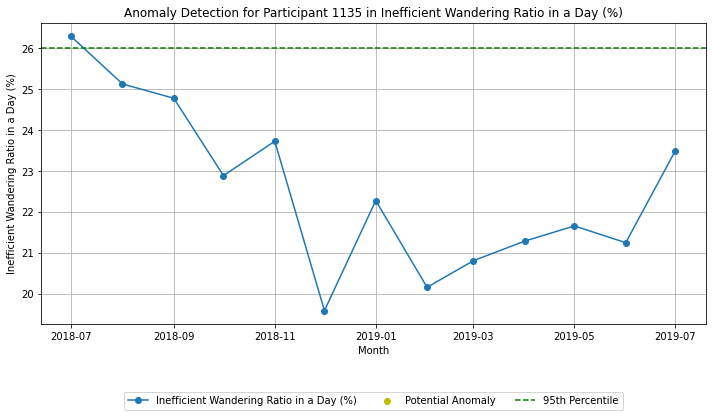

Inefficient_Ratio_Daily From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daily From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Daily From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daily From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Daily From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Daily From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555


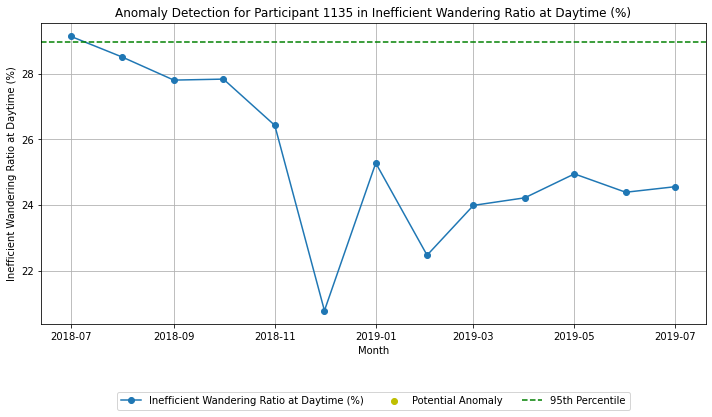

Inefficient_Ratio_Daytime From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daytime From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Daytime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daytime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Daytime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daytime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Daytime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555


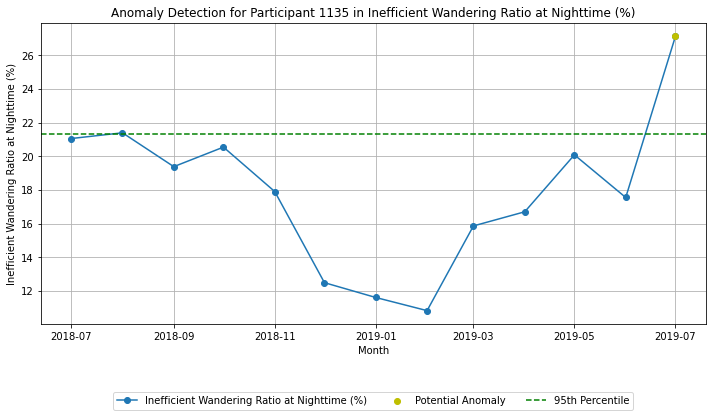

Inefficient_Ratio_Nighttime From 2018-07-01 00:00:00 to 2018-12-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Nighttime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Nighttime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Nighttime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Nighttime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Nighttime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 Increasing Trend


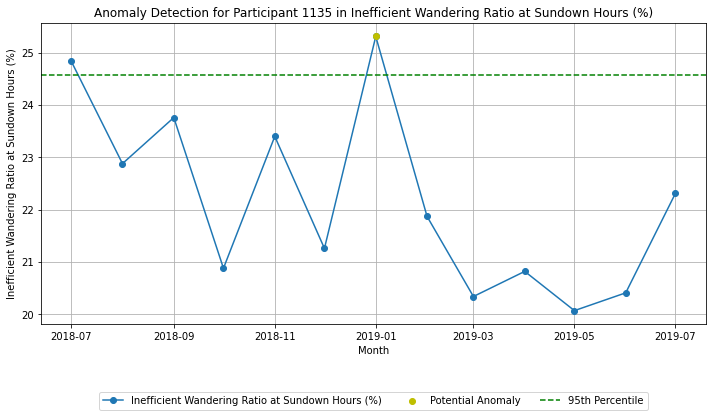

Inefficient_Ratio_Sundowning From 2018-07-01 00:00:00 to 2018-12-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Sundowning From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Sundowning From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Sundowning From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Sundowning From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Sundowning From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.06666666666666665 1.0


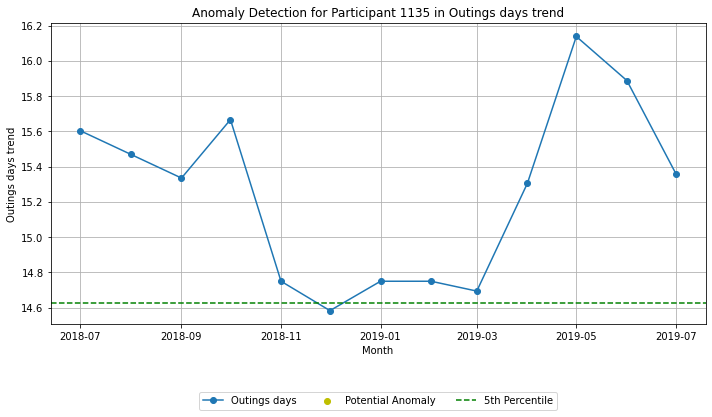

Outings_days From 2018-07-01 00:00:00 to 2018-12-01 00:00:00 No Trend -0.6 0.1361111111111111
Outings_days From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend -0.5520524474738833 0.12597116307723114
Outings_days From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.447213595499958 0.22701614597813402
Outings_days From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.447213595499958 0.22701614597813402
Outings_days From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.29814239699997197 0.4205962375999267
Outings_days From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.6900655593423543 0.05578260870684413
Outings_days From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.5520524474738833 0.12597116307723114
Outings_days From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222


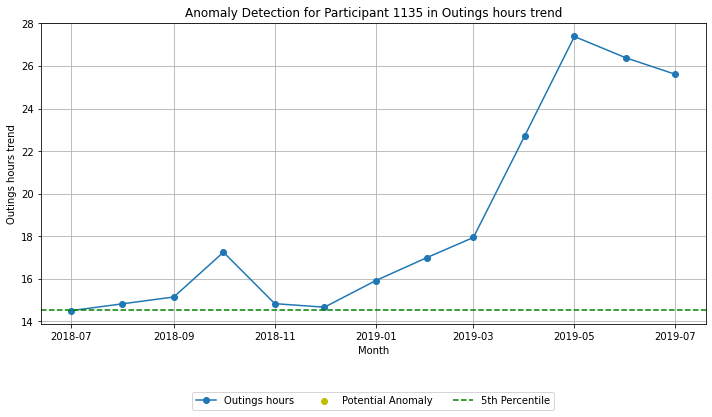

Outings_hours From 2018-07-01 00:00:00 to 2018-12-01 00:00:00 No Trend 0.2 0.7194444444444444
Outings_hours From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend 0.06666666666666665 1.0
Outings_hours From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend 0.06666666666666665 1.0
Outings_hours From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Outings_hours From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.6 0.1361111111111111
1135 Earliest detected deterioration: (Timestamp('2019-07-01 00:00:00'), 'Inefficient_Ratio_Nighttime') second_assessment date 2019-07-11 00:00:00
Patient 1450 Months we have data: 0    2018-04-01
1    2018-05-01
2    2018-06-01
3    2018-07-01
4    2018-08-01
5    2018-09-01
6    2018-10-01
7    2018-11-01
8    2018-12-01
9    2019-01-01
10   2019-02-01
11   2019-03-01
Name: Month, dtype: datetime64[ns]


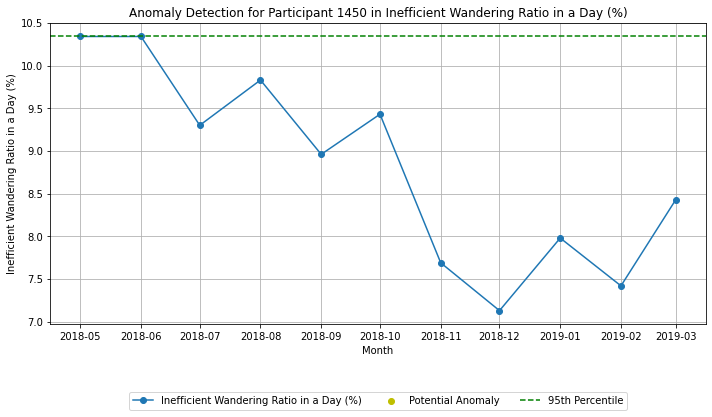

Inefficient_Ratio_Daily From 2018-05-01 00:00:00 to 2018-10-01 00:00:00 No Trend -0.5520524474738833 0.12597116307723114
Inefficient_Ratio_Daily From 2018-06-01 00:00:00 to 2018-11-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Daily From 2018-07-01 00:00:00 to 2018-12-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Daily From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Daily From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.06666666666666665 1.0


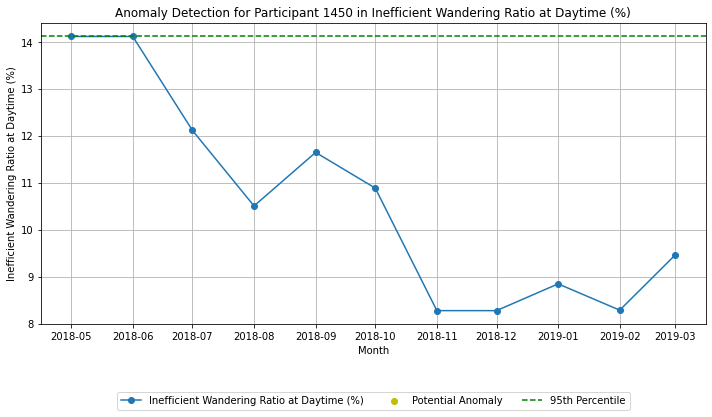

Inefficient_Ratio_Daytime From 2018-05-01 00:00:00 to 2018-10-01 00:00:00 No Trend -0.6900655593423543 0.05578260870684413
Inefficient_Ratio_Daytime From 2018-06-01 00:00:00 to 2018-11-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daytime From 2018-07-01 00:00:00 to 2018-12-01 00:00:00 No Trend -0.6900655593423543 0.05578260870684413
Inefficient_Ratio_Daytime From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend -0.41403933560541256 0.2511180012744736
Inefficient_Ratio_Daytime From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.41403933560541256 0.2511180012744736
Inefficient_Ratio_Daytime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend 0.13801311186847082 0.7020563949269414


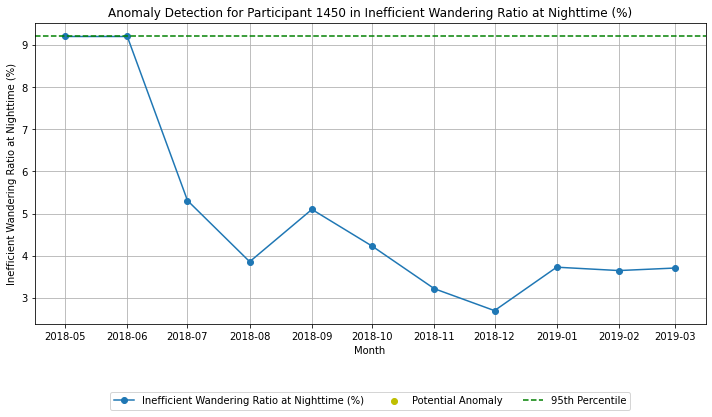

Inefficient_Ratio_Nighttime From 2018-05-01 00:00:00 to 2018-10-01 00:00:00 No Trend -0.6900655593423543 0.05578260870684413
Inefficient_Ratio_Nighttime From 2018-06-01 00:00:00 to 2018-11-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Nighttime From 2018-07-01 00:00:00 to 2018-12-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Nighttime From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Nighttime From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Nighttime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.06666666666666665 1.0


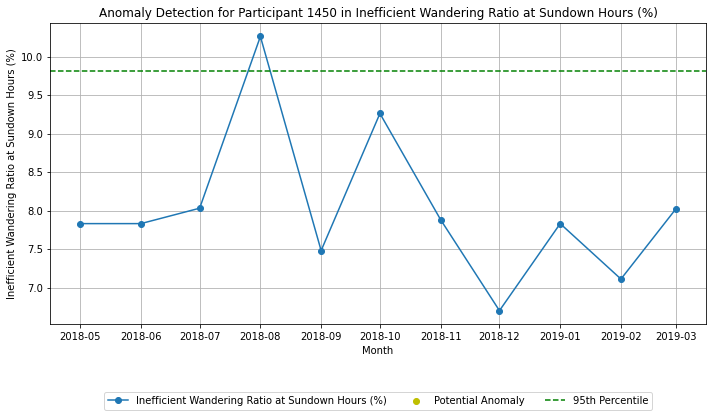

Inefficient_Ratio_Sundowning From 2018-05-01 00:00:00 to 2018-10-01 00:00:00 No Trend 0.27602622373694163 0.44421673013860674
Inefficient_Ratio_Sundowning From 2018-06-01 00:00:00 to 2018-11-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Sundowning From 2018-07-01 00:00:00 to 2018-12-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Sundowning From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.2 0.7194444444444444


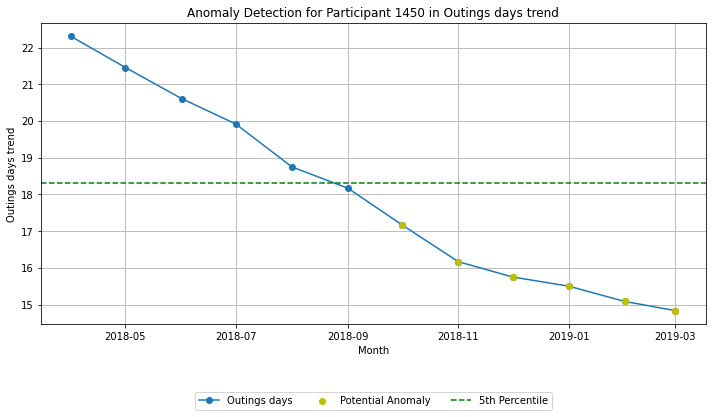

Outings_days From 2018-04-01 00:00:00 to 2018-09-01 00:00:00 Decreasing Trend
Outings_days From 2018-05-01 00:00:00 to 2018-10-01 00:00:00 Decreasing Trend
Outings_days From 2018-06-01 00:00:00 to 2018-11-01 00:00:00 Decreasing Trend
Outings_days From 2018-07-01 00:00:00 to 2018-12-01 00:00:00 Decreasing Trend
Outings_days From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 Decreasing Trend
Outings_days From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 Decreasing Trend
Outings_days From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 Decreasing Trend


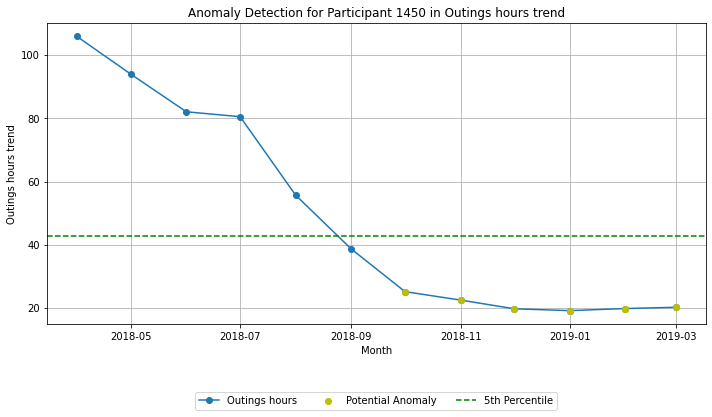

Outings_hours From 2018-04-01 00:00:00 to 2018-09-01 00:00:00 Decreasing Trend
Outings_hours From 2018-05-01 00:00:00 to 2018-10-01 00:00:00 Decreasing Trend
Outings_hours From 2018-06-01 00:00:00 to 2018-11-01 00:00:00 Decreasing Trend
Outings_hours From 2018-07-01 00:00:00 to 2018-12-01 00:00:00 Decreasing Trend
Outings_hours From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 Decreasing Trend
Outings_hours From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Outings_hours From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
1450 Earliest detected deterioration: (Timestamp('2018-10-01 00:00:00'), 'Outings_days') second_assessment date 2019-03-06 00:00:00
Patient 1464 Months we have data: 0    2018-05-01
1    2018-06-01
2    2018-07-01
3    2018-08-01
4    2018-09-01
5    2018-10-01
6    2018-11-01
7    2018-12-01
8    2019-01-01
9    2019-02-01
10   2019-03-01
11   2019-04-01
Name: Month, dtype: datet

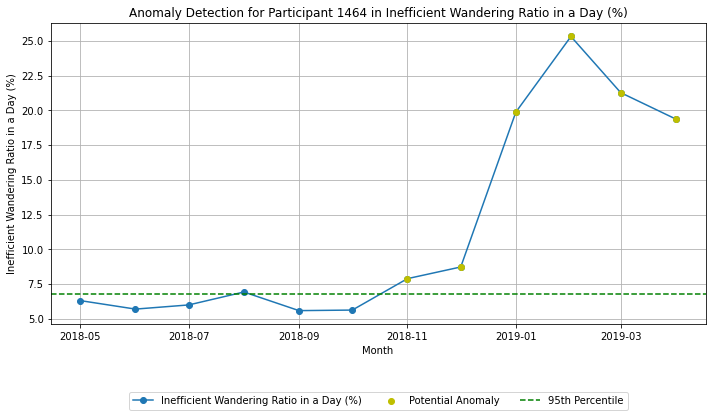

Inefficient_Ratio_Daily From 2018-05-01 00:00:00 to 2018-10-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daily From 2018-06-01 00:00:00 to 2018-11-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Daily From 2018-07-01 00:00:00 to 2018-12-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daily From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 Increasing Trend
Inefficient_Ratio_Daily From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 Increasing Trend
Inefficient_Ratio_Daily From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222


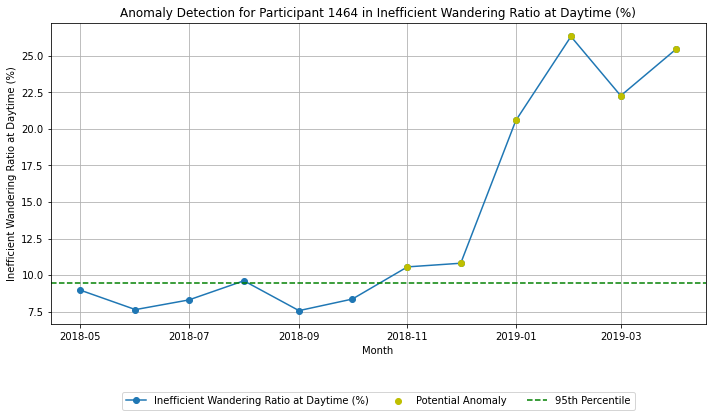

Inefficient_Ratio_Daytime From 2018-05-01 00:00:00 to 2018-10-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Daytime From 2018-06-01 00:00:00 to 2018-11-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daytime From 2018-07-01 00:00:00 to 2018-12-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daytime From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daytime From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 Increasing Trend
Inefficient_Ratio_Daytime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 Increasing Trend
Inefficient_Ratio_Daytime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555


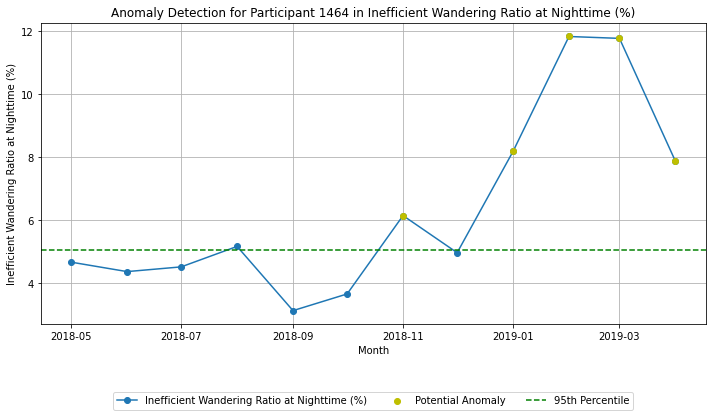

Inefficient_Ratio_Nighttime From 2018-05-01 00:00:00 to 2018-10-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Nighttime From 2018-06-01 00:00:00 to 2018-11-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2018-07-01 00:00:00 to 2018-12-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Nighttime From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 Increasing Trend
Inefficient_Ratio_Nighttime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Nighttime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444


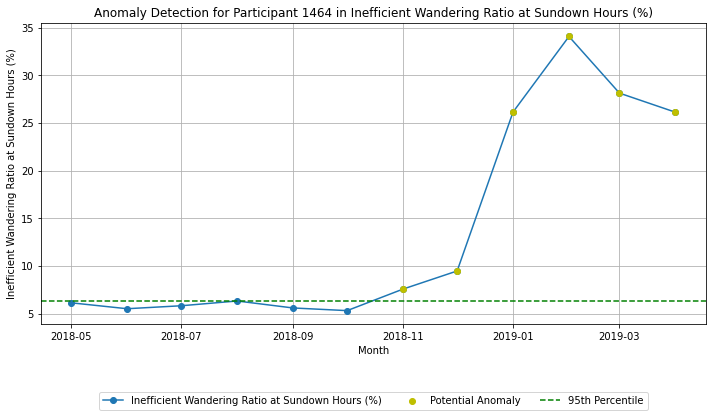

Inefficient_Ratio_Sundowning From 2018-05-01 00:00:00 to 2018-10-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Sundowning From 2018-06-01 00:00:00 to 2018-11-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Sundowning From 2018-07-01 00:00:00 to 2018-12-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Sundowning From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Sundowning From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 Increasing Trend
Inefficient_Ratio_Sundowning From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 Increasing Trend
Inefficient_Ratio_Sundowning From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222


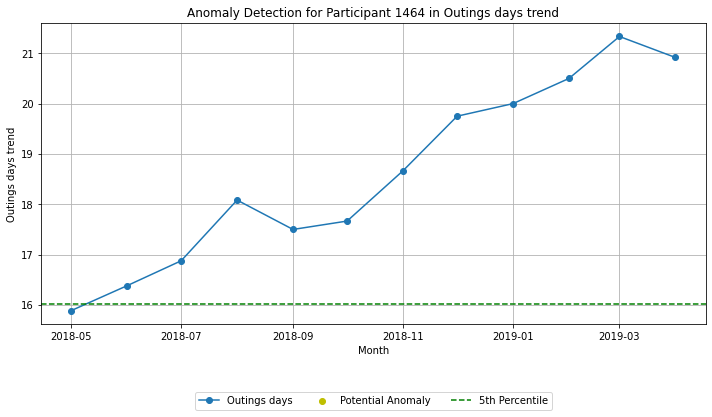

Outings_days From 2018-05-01 00:00:00 to 2018-10-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Outings_days From 2018-06-01 00:00:00 to 2018-11-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Outings_days From 2018-07-01 00:00:00 to 2018-12-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Outings_days From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555


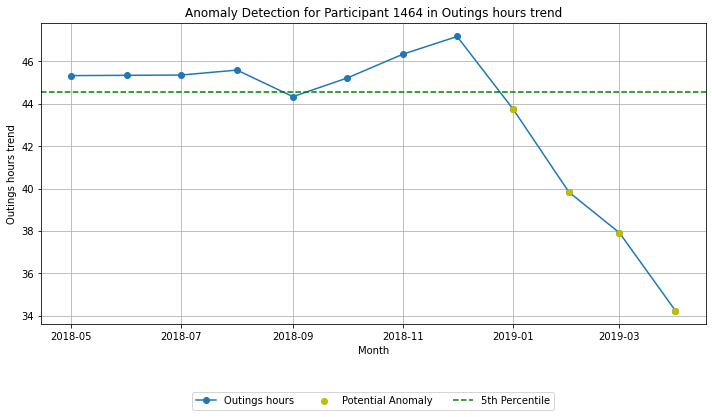

Outings_hours From 2018-05-01 00:00:00 to 2018-10-01 00:00:00 No Trend -0.06666666666666665 1.0
Outings_hours From 2018-06-01 00:00:00 to 2018-11-01 00:00:00 No Trend 0.2 0.7194444444444444
Outings_hours From 2018-07-01 00:00:00 to 2018-12-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Outings_hours From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend 0.06666666666666665 1.0
Outings_hours From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.2 0.7194444444444444
Outings_hours From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.6 0.1361111111111111
Outings_hours From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 Decreasing Trend
1464 Earliest detected deterioration: (Timestamp('2018-11-01 00:00:00'), 'Inefficient_Ratio_Daily') second_assessment date 2019-04-26 00:00:00
Patient 1497 Months we have data: 0    2018-07-01
1    2018-08-01
2    2018-09-01
3    2018-10-01
4    2018-11-01
5    2018-12-01
6    2019-01-01
7    2019-02-01
8    2019-03-01
9    2019-04-01


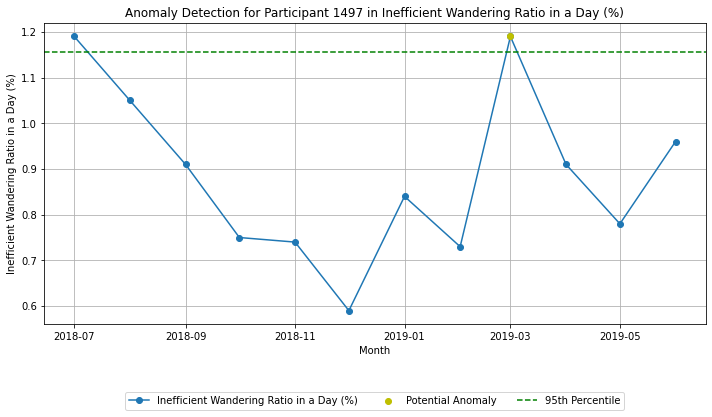

Inefficient_Ratio_Daily From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Daily From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Daily From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daily From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.2 0.7194444444444444


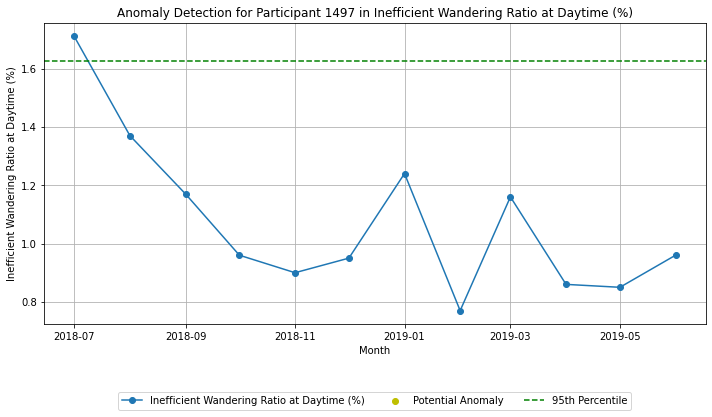

Inefficient_Ratio_Daytime From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daytime From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daytime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Daytime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Daytime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daytime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.2 0.7194444444444444


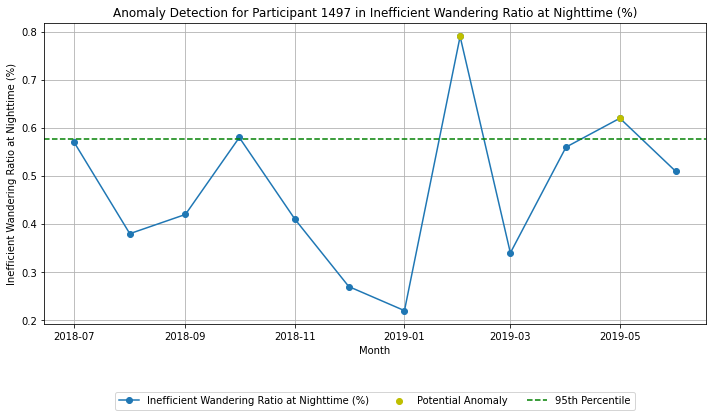

Inefficient_Ratio_Nighttime From 2018-07-01 00:00:00 to 2018-12-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Nighttime From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Nighttime From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Nighttime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.2 0.7194444444444444


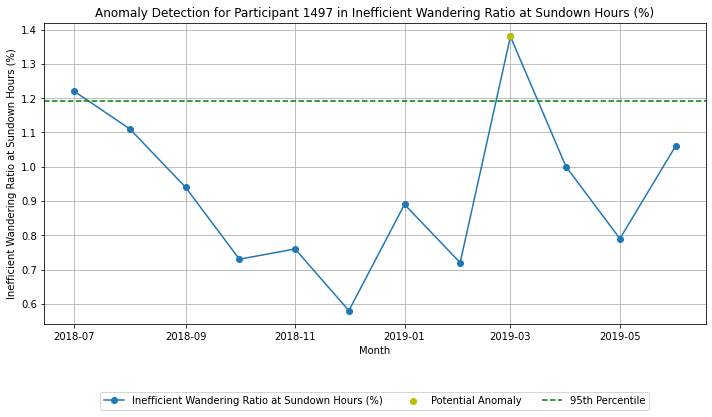

Inefficient_Ratio_Sundowning From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Sundowning From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Sundowning From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Sundowning From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.2 0.7194444444444444


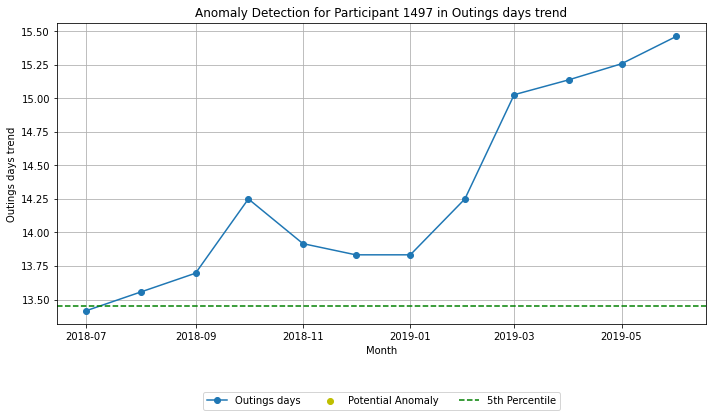

Outings_days From 2018-07-01 00:00:00 to 2018-12-01 00:00:00 No Trend 0.6 0.1361111111111111
Outings_days From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend 0.27602622373694163 0.44421673013860674
Outings_days From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend 0.13801311186847082 0.7020563949269414
Outings_days From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend 0.13801311186847082 0.7020563949269414
Outings_days From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.6900655593423543 0.05578260870684413


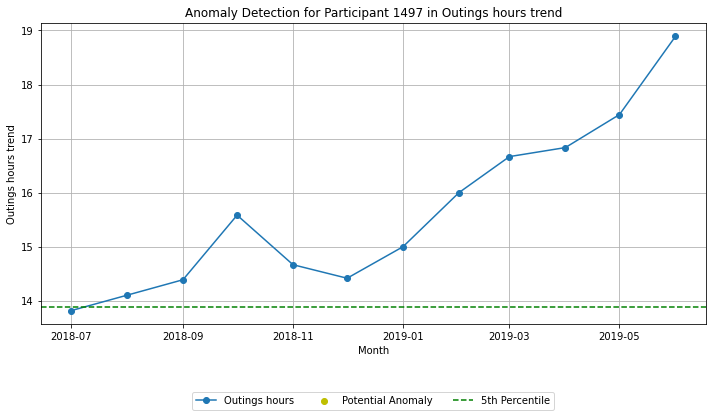

Outings_hours From 2018-07-01 00:00:00 to 2018-12-01 00:00:00 No Trend 0.6 0.1361111111111111
Outings_hours From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Outings_hours From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Outings_hours From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
1497 Earliest detected deterioration: None second_assessment date 2019-06-06 00:00:00
Patient 1504 Months we have data: 0    2018-08-01
1    2018-09-01
2    2018-10-01
3    2018-11-01
4    2018-12-01
5    2019-01-01
6    2019-02-01
7    2019-03-01
8    2019-04-01
9    2019-05-01
10   2019-06-01
Name: Month, dtype: datetime64[ns]


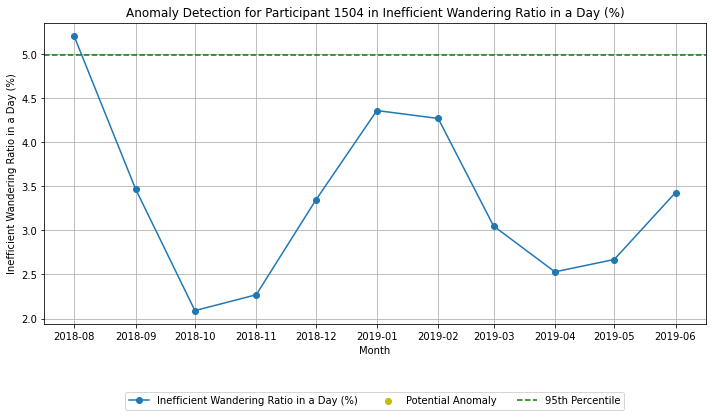

Inefficient_Ratio_Daily From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Daily From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Daily From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Daily From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222


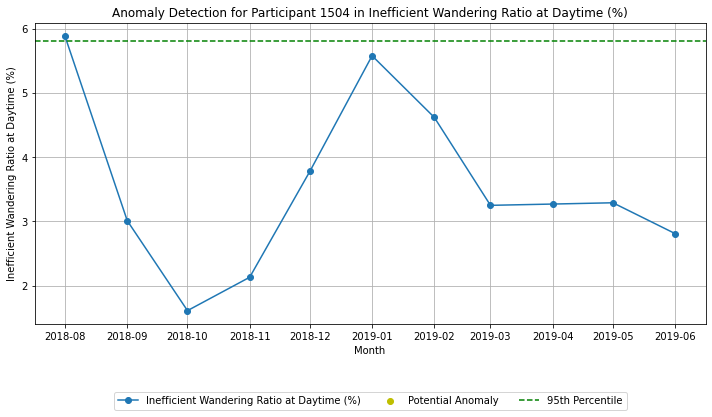

Inefficient_Ratio_Daytime From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Daytime From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daytime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daytime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Daytime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daytime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.6 0.1361111111111111


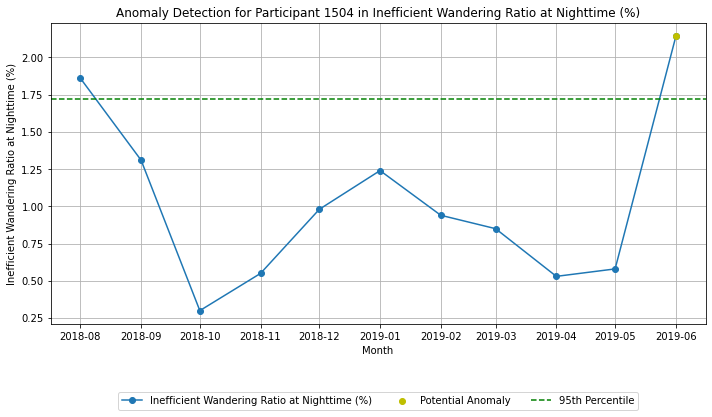

Inefficient_Ratio_Nighttime From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Nighttime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Nighttime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Nighttime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Nighttime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.2 0.7194444444444444


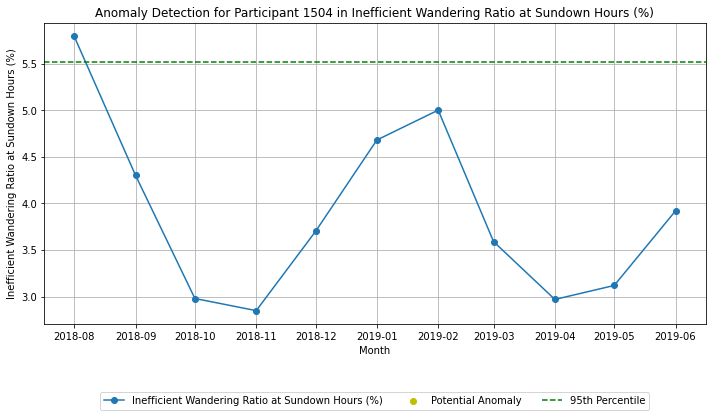

Inefficient_Ratio_Sundowning From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Sundowning From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Sundowning From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444


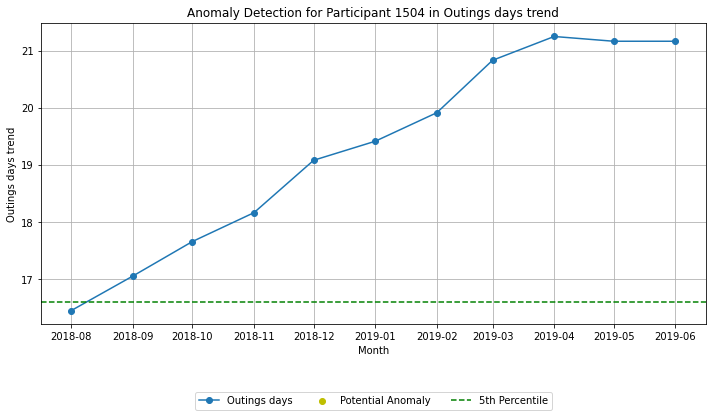

Outings_days From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.6900655593423543 0.05578260870684413


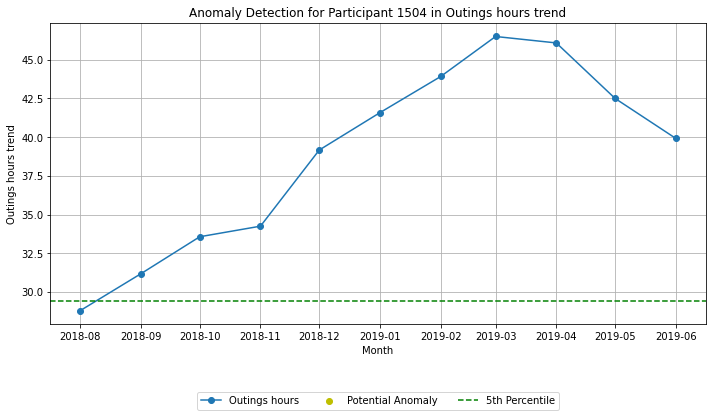

Outings_hours From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Outings_hours From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.2 0.7194444444444444
1504 Earliest detected deterioration: None second_assessment date 2019-06-12 00:00:00
Patient 1511 Months we have data: 0    2018-08-01
1    2018-09-01
2    2018-10-01
3    2018-11-01
4    2018-12-01
5    2019-01-01
6    2019-02-01
7    2019-03-01
8    2019-04-01
9    2019-05-01
10   2019-06-01
Name: Month, dtype: datetime64[ns]


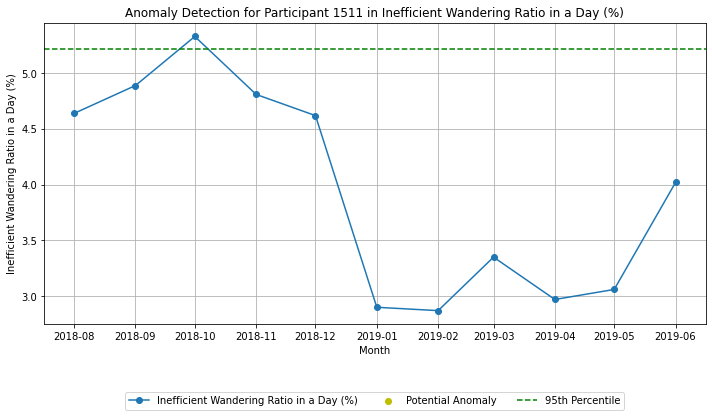

Inefficient_Ratio_Daily From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daily From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Daily From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.6 0.1361111111111111


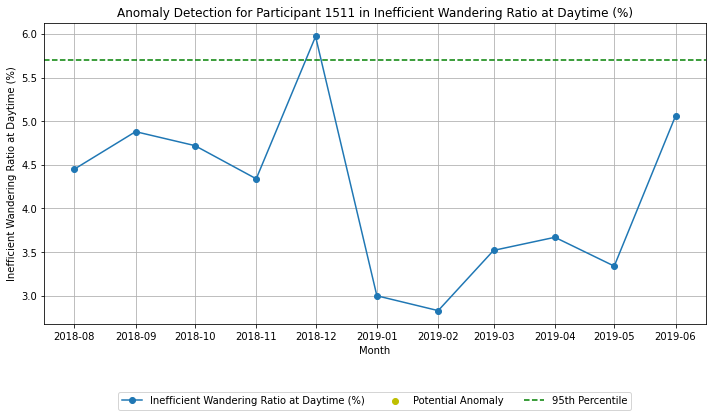

Inefficient_Ratio_Daytime From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Daytime From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Daytime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daytime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Daytime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Daytime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.6 0.1361111111111111


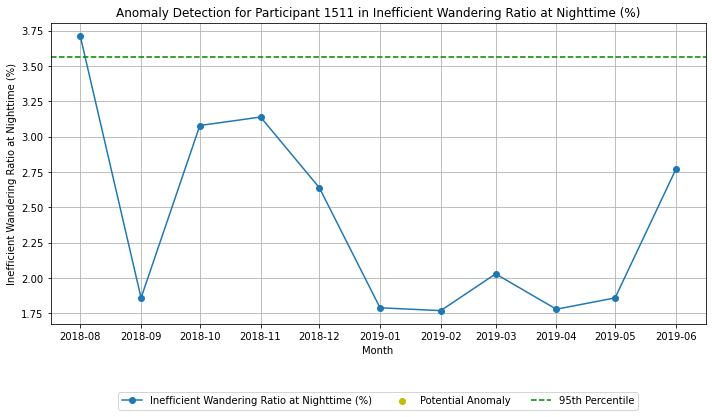

Inefficient_Ratio_Nighttime From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Nighttime From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Nighttime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Nighttime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Nighttime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222


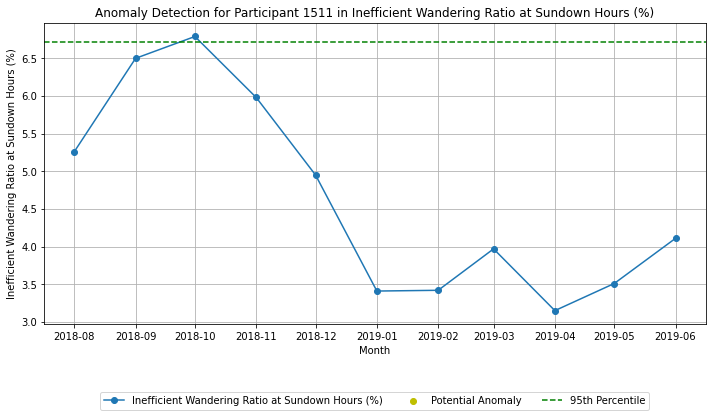

Inefficient_Ratio_Sundowning From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Sundowning From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Sundowning From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Sundowning From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Sundowning From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222


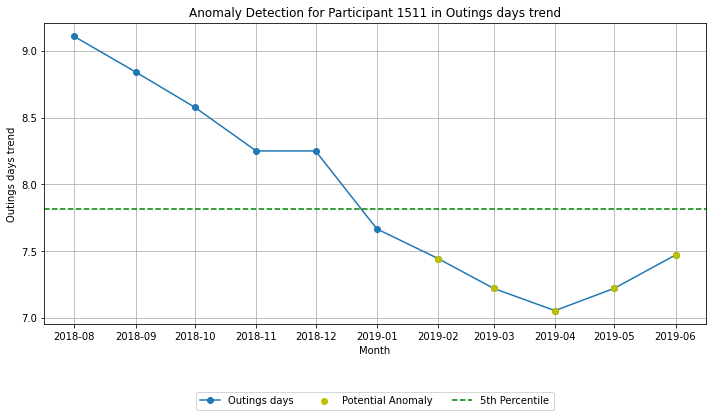

Outings_days From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 Decreasing Trend
Outings_days From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 Decreasing Trend
Outings_days From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 Decreasing Trend
Outings_days From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 Decreasing Trend
Outings_days From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 Decreasing Trend
Outings_days From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444


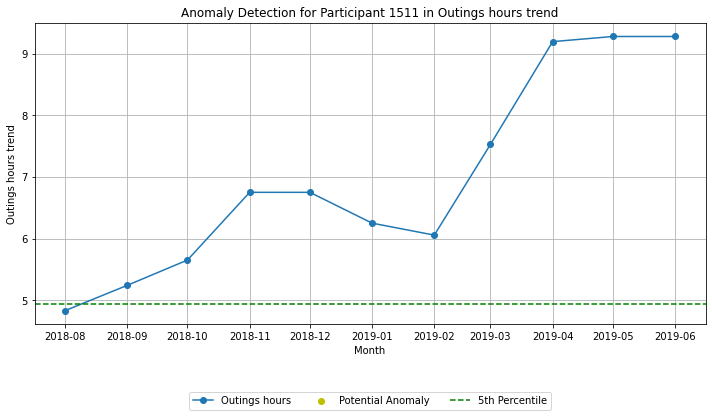

Outings_hours From 2018-08-01 00:00:00 to 2019-01-01 00:00:00 No Trend 0.6 0.1361111111111111
Outings_hours From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend 0.2 0.7194444444444444
Outings_hours From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend 0.2 0.7194444444444444
Outings_hours From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.2 0.7194444444444444
Outings_hours From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.6 0.1361111111111111
1511 Earliest detected deterioration: (Timestamp('2019-02-01 00:00:00'), 'Outings_days') second_assessment date 2019-06-17 00:00:00
Patient 1541 Months we have data: 0    2018-09-01
1    2018-10-01
2    2018-11-01
3    2018-12-01
4    2019-01-01
5    2019-02-01
6    2019-03-01
7    2019-04-01
8    2019-05-01
9    2019-06-01
10   2019-07-01
Name: Month, dtype: datetime64[ns]


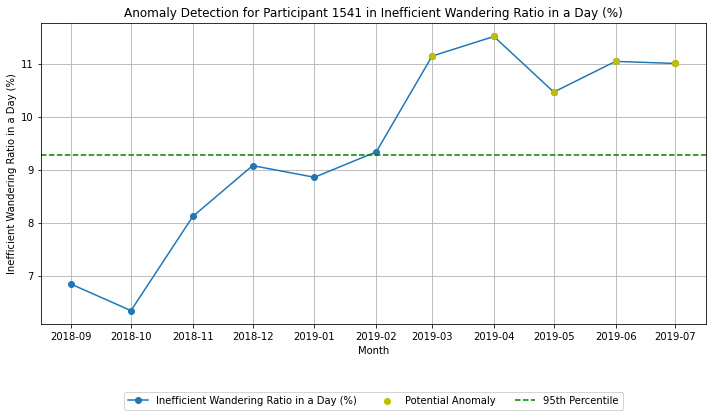

Inefficient_Ratio_Daily From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daily From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 Increasing Trend
Inefficient_Ratio_Daily From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 Increasing Trend
Inefficient_Ratio_Daily From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daily From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.06666666666666665 1.0


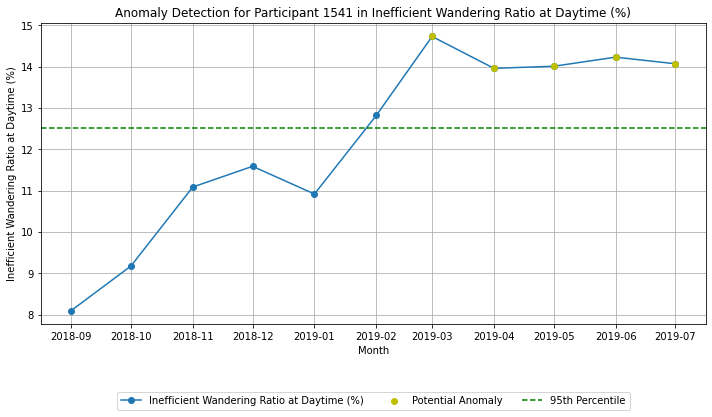

Inefficient_Ratio_Daytime From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daytime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daytime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daytime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daytime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daytime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444


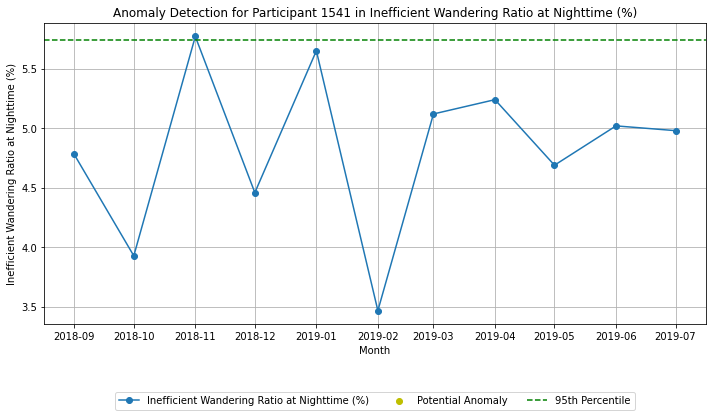

Inefficient_Ratio_Nighttime From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Nighttime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Nighttime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.06666666666666665 1.0


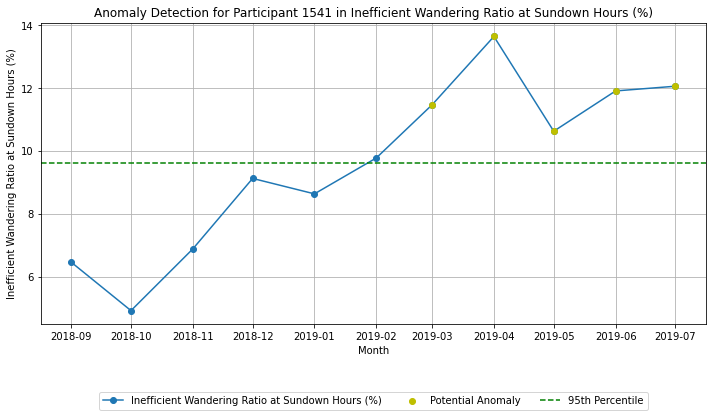

Inefficient_Ratio_Sundowning From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Sundowning From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 Increasing Trend
Inefficient_Ratio_Sundowning From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 Increasing Trend
Inefficient_Ratio_Sundowning From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Sundowning From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Sundowning From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222


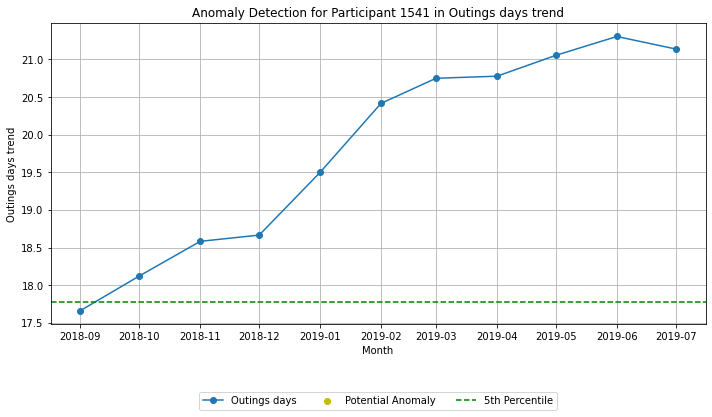

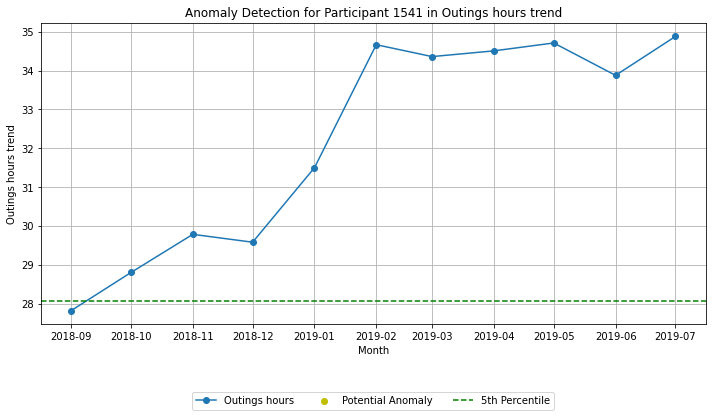

Outings_hours From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Outings_hours From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.6 0.1361111111111111
Outings_hours From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Outings_hours From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.2 0.7194444444444444
Outings_hours From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.2 0.7194444444444444
1541 Earliest detected deterioration: (Timestamp('2019-03-01 00:00:00'), 'Inefficient_Ratio_Daily') second_assessment date 2019-07-31 00:00:00
Patient 1559 Months we have data: 0    2018-09-01
1    2018-10-01
2    2018-11-01
3    2018-12-01
4    2019-01-01
5    2019-02-01
6    2019-03-01
7    2019-04-01
8    2019-05-01
9    2019-06-01
10   2019-07-01
Name: Month, dtype: datetime64[ns]


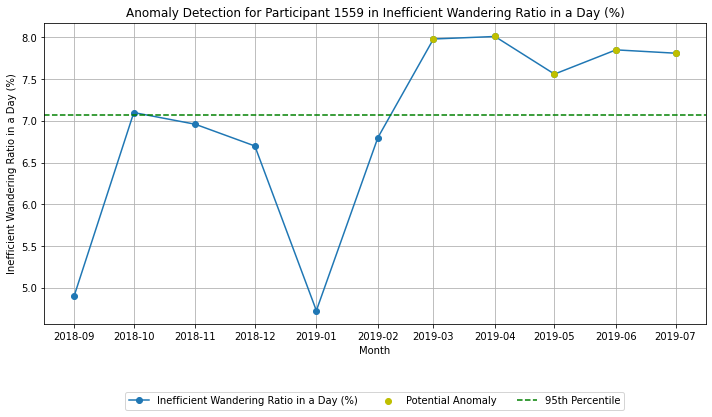

Inefficient_Ratio_Daily From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Daily From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Daily From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daily From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.06666666666666665 1.0


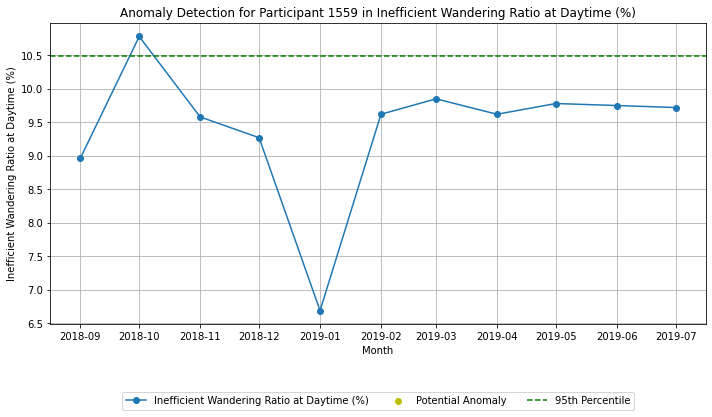

Inefficient_Ratio_Daytime From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Daytime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Daytime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.41403933560541256 0.2511180012744736
Inefficient_Ratio_Daytime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.5520524474738833 0.12597116307723114
Inefficient_Ratio_Daytime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.41403933560541256 0.2511180012744736
Inefficient_Ratio_Daytime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.0 1.0


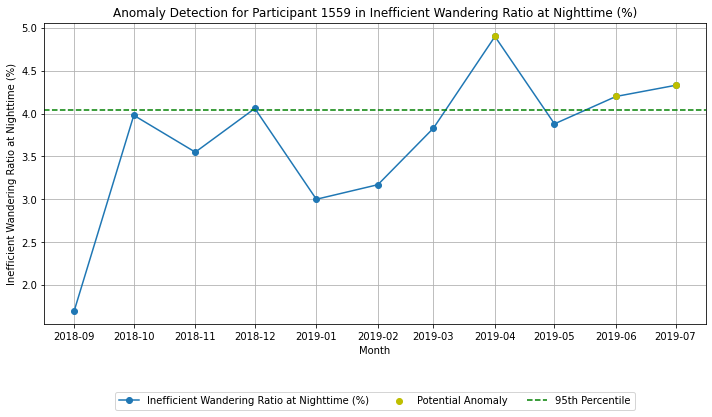

Inefficient_Ratio_Nighttime From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Nighttime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Nighttime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Nighttime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Nighttime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.6 0.1361111111111111


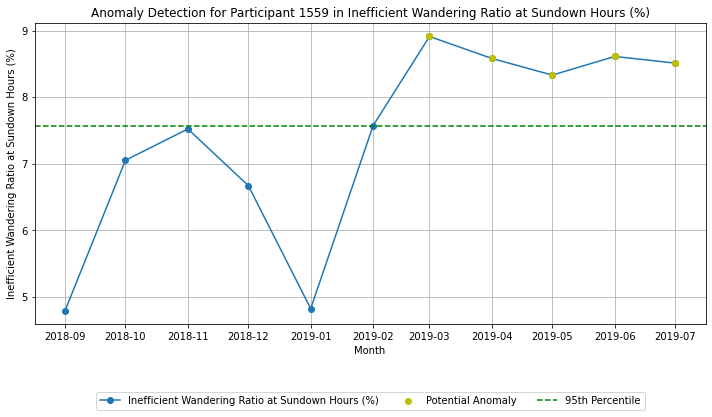

Inefficient_Ratio_Sundowning From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Sundowning From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Sundowning From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.06666666666666665 1.0


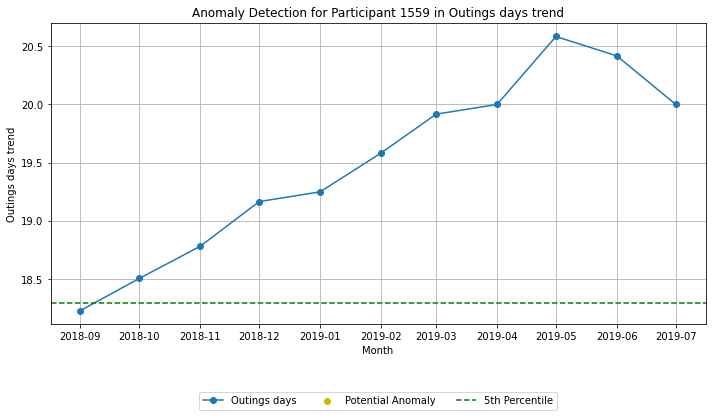

Outings_days From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.5520524474738833 0.12597116307723114


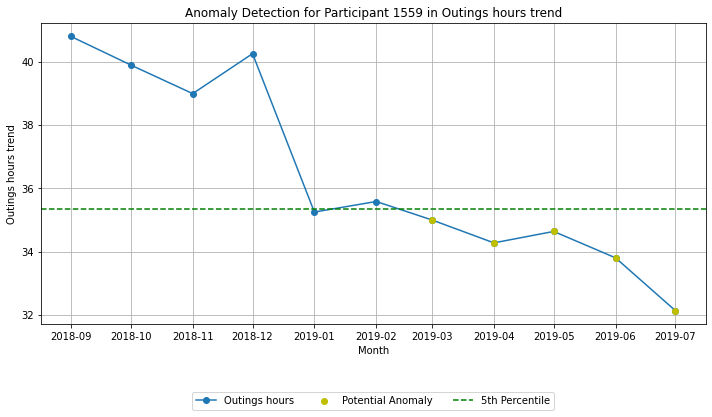

Outings_hours From 2018-09-01 00:00:00 to 2019-02-01 00:00:00 No Trend -0.6 0.1361111111111111
Outings_hours From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.6 0.1361111111111111
Outings_hours From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Outings_hours From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Outings_hours From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Outings_hours From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 Decreasing Trend
1559 Earliest detected deterioration: (Timestamp('2019-03-01 00:00:00'), 'Outings_hours') second_assessment date 2019-07-22 00:00:00
Patient 1572 Months we have data: 0   2018-10-01
1   2018-11-01
2   2018-12-01
3   2019-01-01
4   2019-02-01
5   2019-03-01
6   2019-04-01
7   2019-05-01
8   2019-06-01
9   2019-07-01
Name: Month, dtype: datetime64[ns]


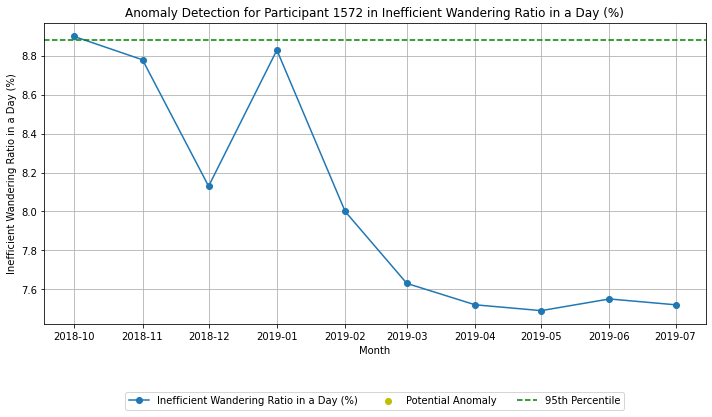

Inefficient_Ratio_Daily From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daily From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daily From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daily From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.5520524474738833 0.12597116307723114


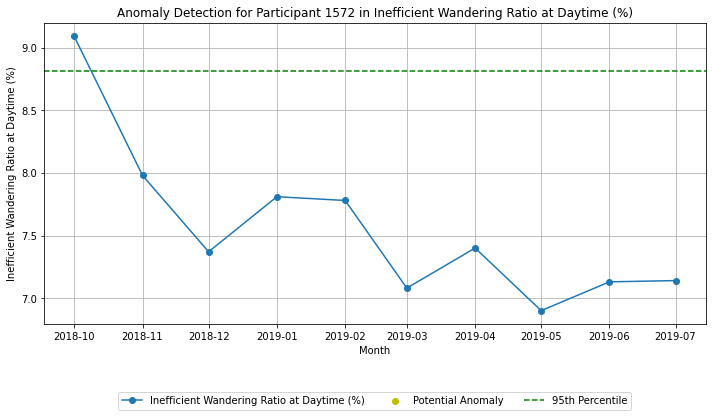

Inefficient_Ratio_Daytime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daytime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daytime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daytime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Daytime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.2 0.7194444444444444


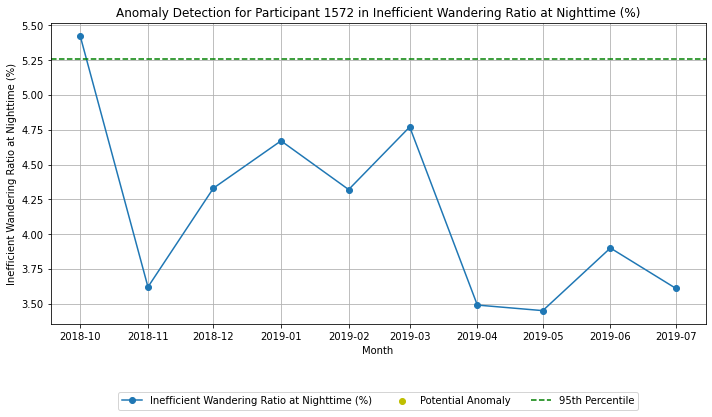

Inefficient_Ratio_Nighttime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Nighttime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Nighttime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Nighttime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Nighttime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444


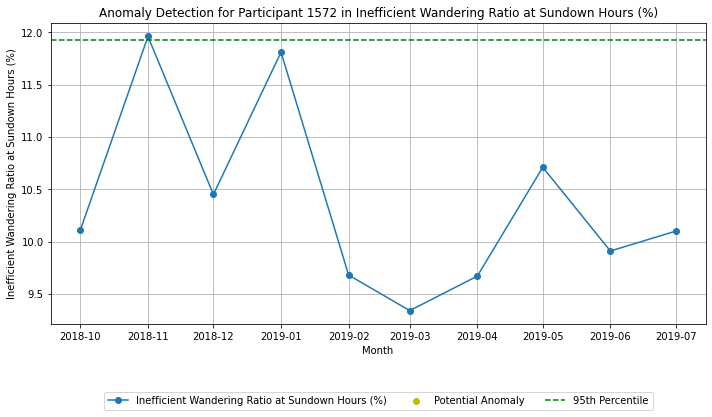

Inefficient_Ratio_Sundowning From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Sundowning From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Sundowning From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Sundowning From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222


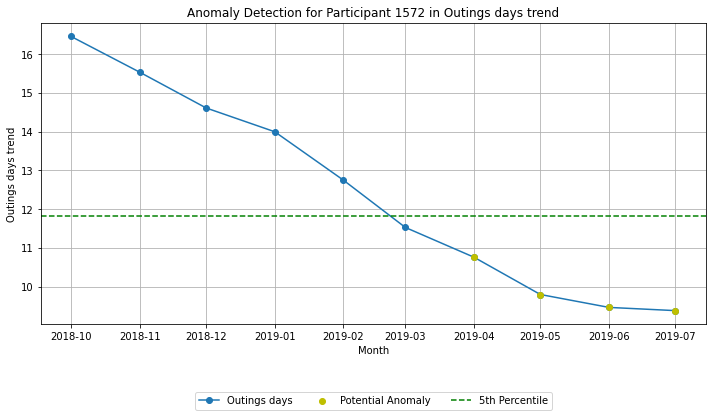

Outings_days From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 Decreasing Trend
Outings_days From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 Decreasing Trend
Outings_days From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 Decreasing Trend
Outings_days From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 Decreasing Trend
Outings_days From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 Decreasing Trend


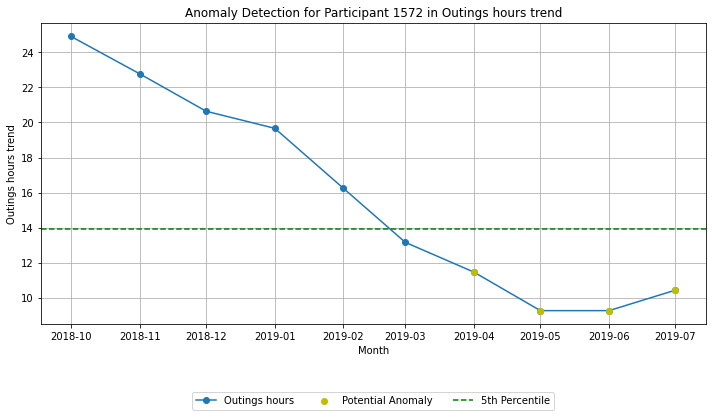

Outings_hours From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 Decreasing Trend
Outings_hours From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 Decreasing Trend
Outings_hours From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 Decreasing Trend
Outings_hours From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 Decreasing Trend
Outings_hours From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.6900655593423543 0.05578260870684413
1572 Earliest detected deterioration: (Timestamp('2019-04-01 00:00:00'), 'Outings_days') second_assessment date 2019-07-24 00:00:00
Patient 1582 Months we have data: 0    2018-10-01
1    2018-11-01
2    2018-12-01
3    2019-01-01
4    2019-02-01
5    2019-03-01
6    2019-04-01
7    2019-05-01
8    2019-06-01
9    2019-07-01
10   2019-08-01
11   2019-09-01
Name: Month, dtype: datetime64[ns]


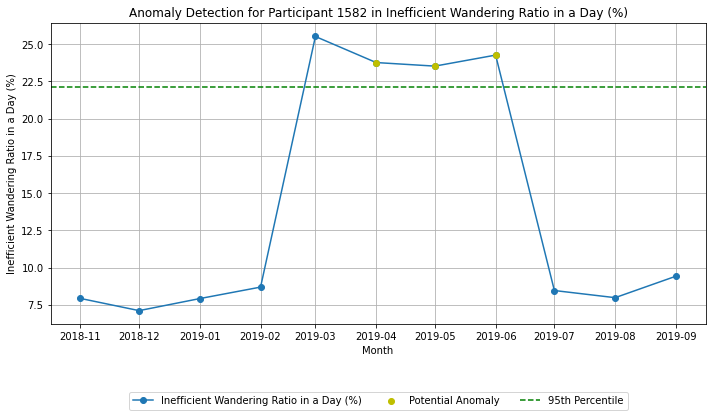

Inefficient_Ratio_Daily From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daily From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daily From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Daily From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daily From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222


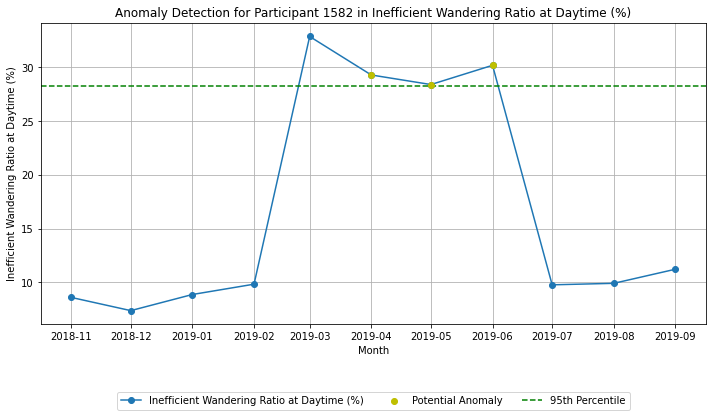

Inefficient_Ratio_Daytime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daytime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daytime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daytime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Daytime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Daytime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444


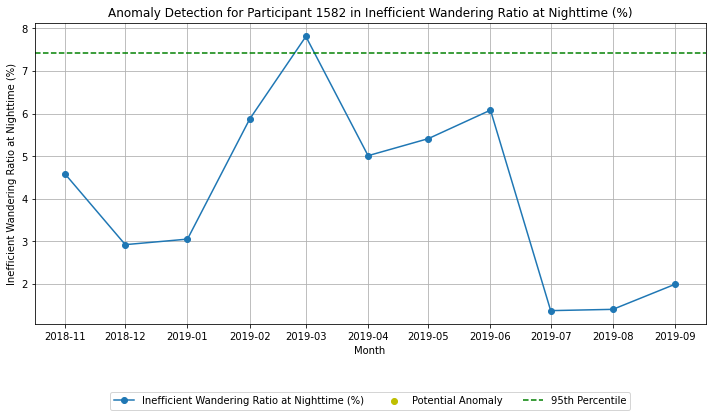

Inefficient_Ratio_Nighttime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Nighttime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Nighttime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Nighttime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Nighttime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Nighttime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.2 0.7194444444444444


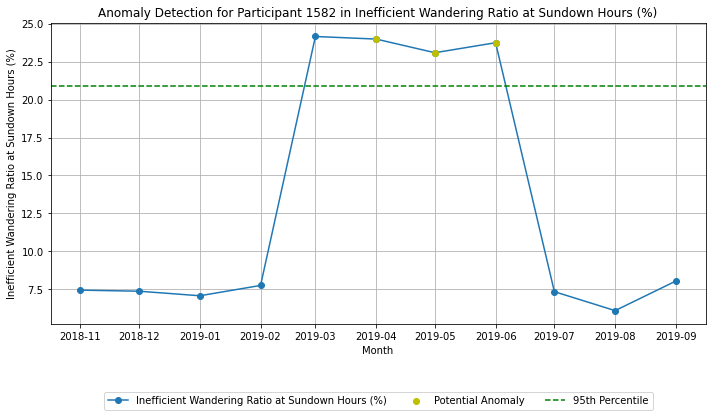

Inefficient_Ratio_Sundowning From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Sundowning From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Sundowning From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.6 0.1361111111111111


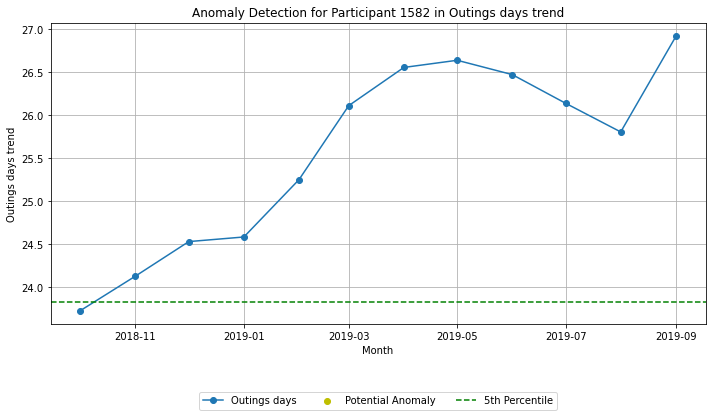

Outings_days From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Outings_days From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Outings_days From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Outings_days From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.2 0.7194444444444444


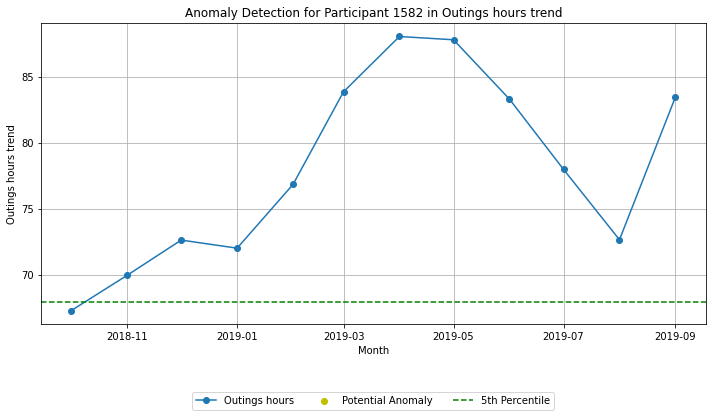

Outings_hours From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Outings_hours From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Outings_hours From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.06666666666666665 1.0
Outings_hours From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Outings_hours From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.6 0.1361111111111111
1582 Earliest detected deterioration: None second_assessment date 2019-09-13 00:00:00
Patient 1586 Months we have data: 0   2018-10-01
1   2018-11-01
2   2018-12-01
3   2019-01-01
4   2019-02-01
5   2019-03-01
6   2019-04-01
7   2019-05-01
8   2019-06-01
9   2019-07-01
Name: Month, dtype: datetime64[ns]


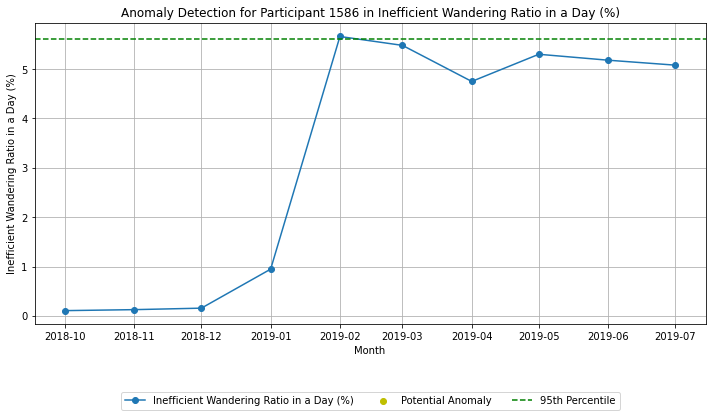

Inefficient_Ratio_Daily From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 Increasing Trend
Inefficient_Ratio_Daily From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daily From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daily From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Daily From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.6 0.1361111111111111


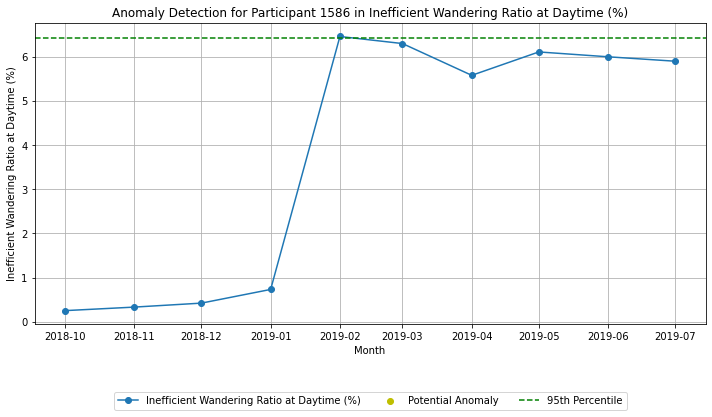

Inefficient_Ratio_Daytime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 Increasing Trend
Inefficient_Ratio_Daytime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daytime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daytime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Daytime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.6 0.1361111111111111


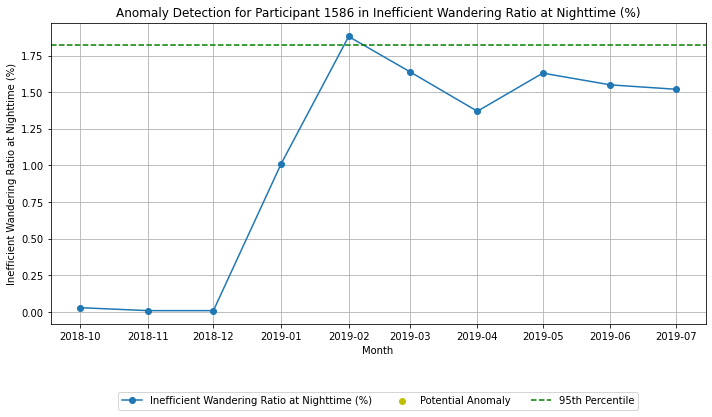

Inefficient_Ratio_Nighttime From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend 0.5520524474738833 0.12597116307723114
Inefficient_Ratio_Nighttime From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.5520524474738833 0.12597116307723114
Inefficient_Ratio_Nighttime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Nighttime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Nighttime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.6 0.1361111111111111


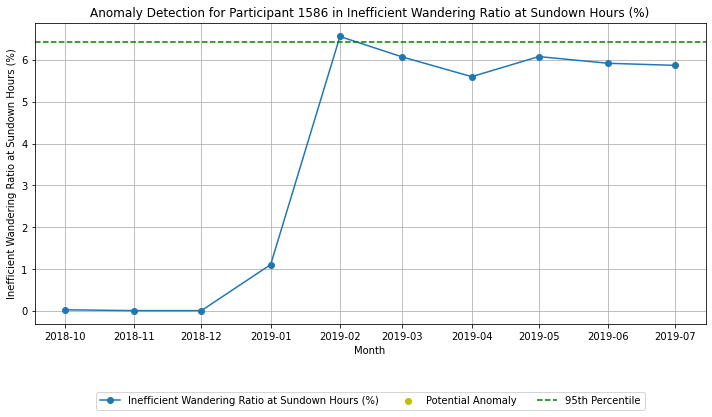

Inefficient_Ratio_Sundowning From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 No Trend 0.5520524474738833 0.12597116307723114
Inefficient_Ratio_Sundowning From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 No Trend 0.5520524474738833 0.12597116307723114
Inefficient_Ratio_Sundowning From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Sundowning From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222


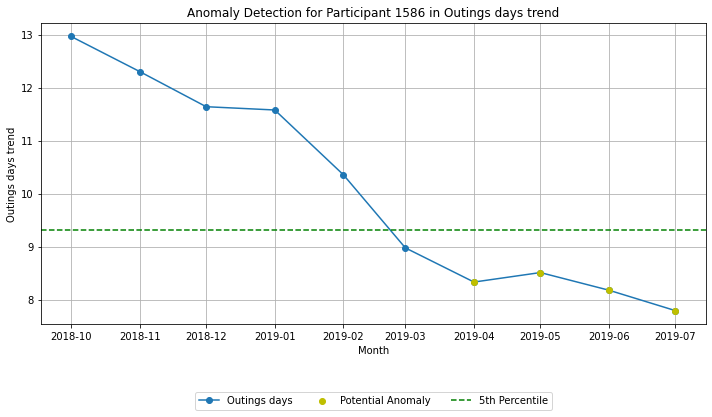

Outings_days From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 Decreasing Trend
Outings_days From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 Decreasing Trend
Outings_days From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 Decreasing Trend
Outings_days From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 Decreasing Trend
Outings_days From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 Decreasing Trend


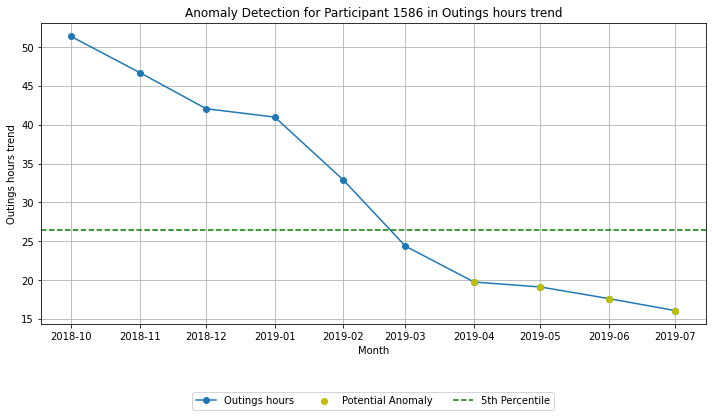

Outings_hours From 2018-10-01 00:00:00 to 2019-03-01 00:00:00 Decreasing Trend
Outings_hours From 2018-11-01 00:00:00 to 2019-04-01 00:00:00 Decreasing Trend
Outings_hours From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 Decreasing Trend
Outings_hours From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 Decreasing Trend
Outings_hours From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 Decreasing Trend
1586 Earliest detected deterioration: (Timestamp('2019-04-01 00:00:00'), 'Outings_days') second_assessment date 2019-07-26 00:00:00
Patient 1603 Months we have data: 0   2019-01-01
1   2019-02-01
2   2019-03-01
3   2019-04-01
4   2019-05-01
5   2019-06-01
6   2019-07-01
7   2019-08-01
8   2019-09-01
Name: Month, dtype: datetime64[ns]


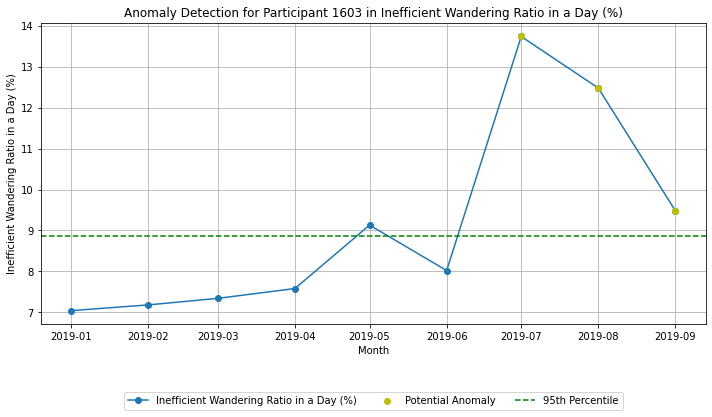

Inefficient_Ratio_Daily From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 Increasing Trend
Inefficient_Ratio_Daily From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 Increasing Trend
Inefficient_Ratio_Daily From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daily From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222


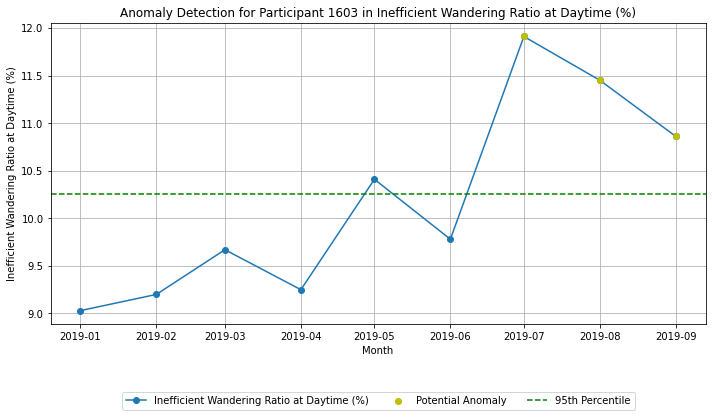

Inefficient_Ratio_Daytime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daytime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daytime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daytime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222


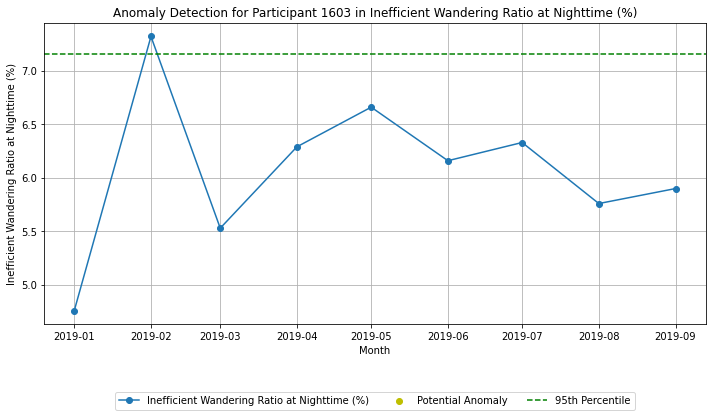

Inefficient_Ratio_Nighttime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Nighttime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Nighttime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222


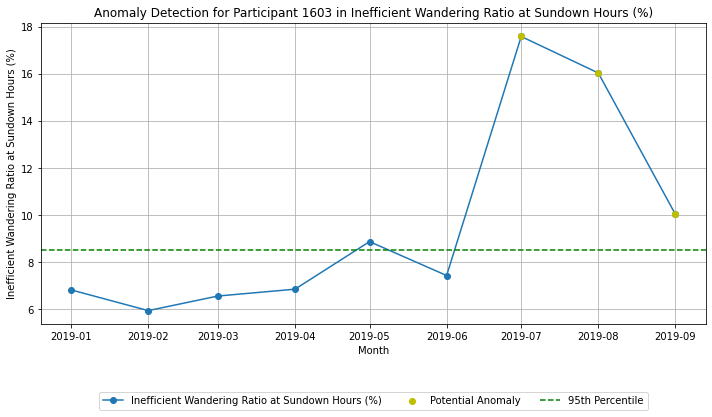

Inefficient_Ratio_Sundowning From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Sundowning From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 Increasing Trend
Inefficient_Ratio_Sundowning From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Sundowning From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222


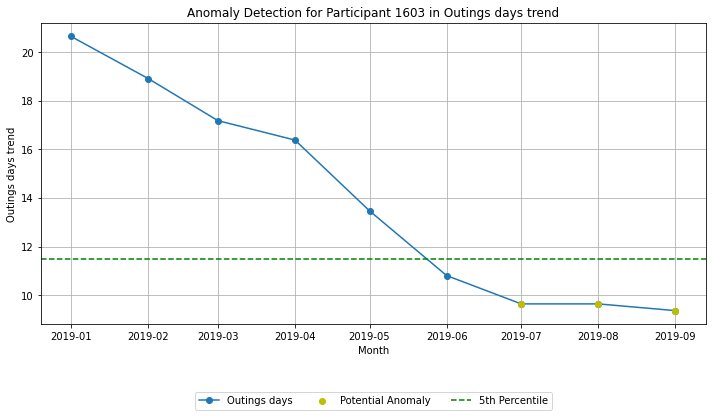

Outings_days From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 Decreasing Trend
Outings_days From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 Decreasing Trend
Outings_days From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 Decreasing Trend
Outings_days From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 Decreasing Trend


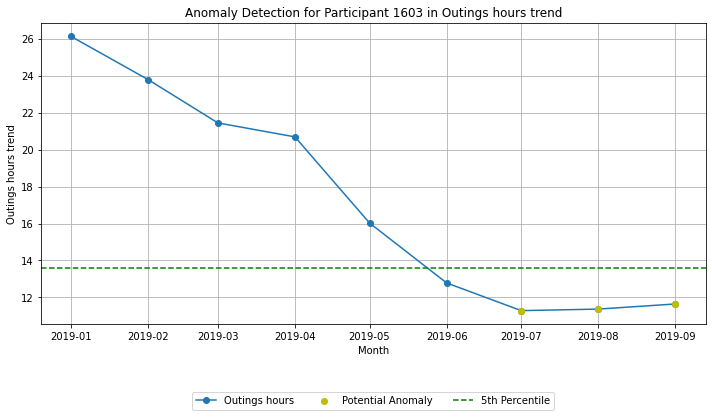

Outings_hours From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 Decreasing Trend
Outings_hours From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 Decreasing Trend
Outings_hours From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 Decreasing Trend
Outings_hours From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.6 0.1361111111111111
1603 Earliest detected deterioration: (Timestamp('2019-07-01 00:00:00'), 'Inefficient_Ratio_Daily') second_assessment date 2019-09-13 00:00:00
Patient 1607 Months we have data: 0   2019-03-01
1   2019-04-01
2   2019-05-01
3   2019-06-01
4   2019-07-01
5   2019-08-01
6   2019-09-01
7   2019-10-01
8   2019-11-01
Name: Month, dtype: datetime64[ns]


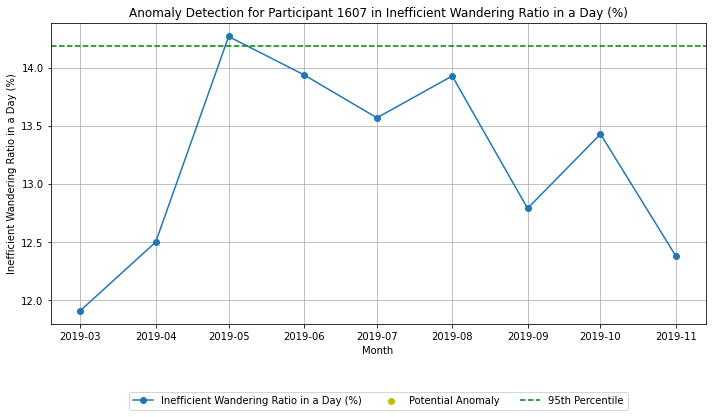

Inefficient_Ratio_Daily From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daily From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Daily From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daily From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555


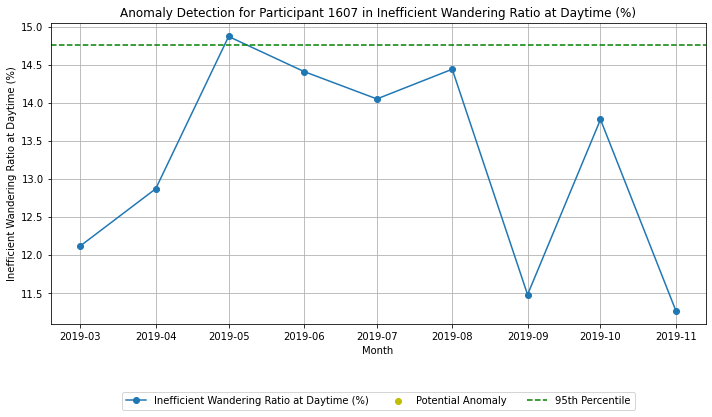

Inefficient_Ratio_Daytime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daytime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Daytime From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Daytime From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend -0.6 0.1361111111111111


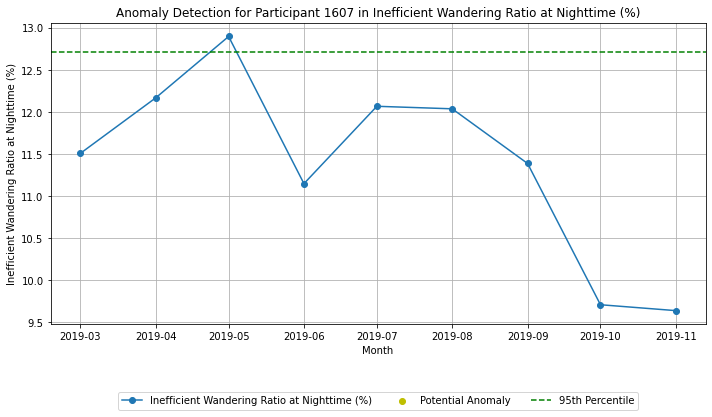

Inefficient_Ratio_Nighttime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Nighttime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Nighttime From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Nighttime From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend -0.6 0.1361111111111111


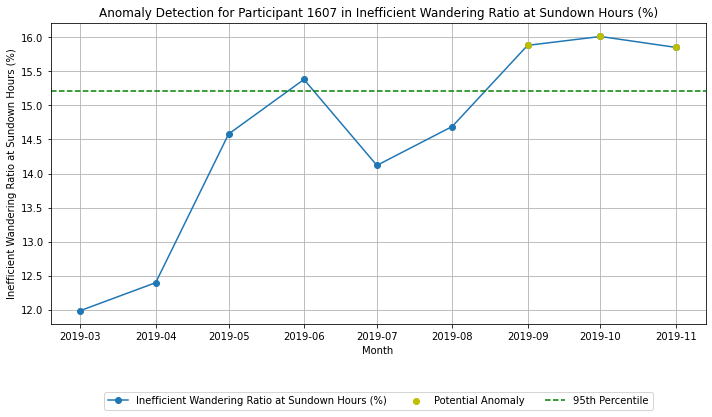

Inefficient_Ratio_Sundowning From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Sundowning From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Sundowning From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Sundowning From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222


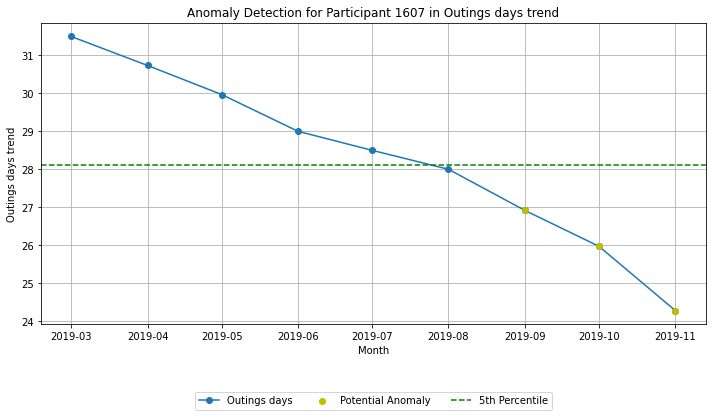

Outings_days From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 Decreasing Trend
Outings_days From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 Decreasing Trend
Outings_days From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 Decreasing Trend
Outings_days From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 Decreasing Trend


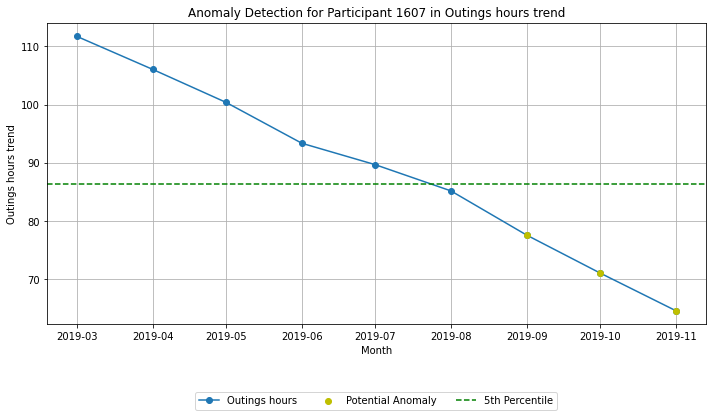

Outings_hours From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 Decreasing Trend
Outings_hours From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 Decreasing Trend
Outings_hours From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 Decreasing Trend
Outings_hours From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 Decreasing Trend
1607 Earliest detected deterioration: (Timestamp('2019-09-01 00:00:00'), 'Outings_days') second_assessment date 2019-11-05 00:00:00
Patient 1609 Months we have data: 0    2019-01-01
1    2019-02-01
2    2019-03-01
3    2019-04-01
4    2019-05-01
5    2019-06-01
6    2019-07-01
7    2019-08-01
8    2019-09-01
9    2019-10-01
10   2019-11-01
Name: Month, dtype: datetime64[ns]


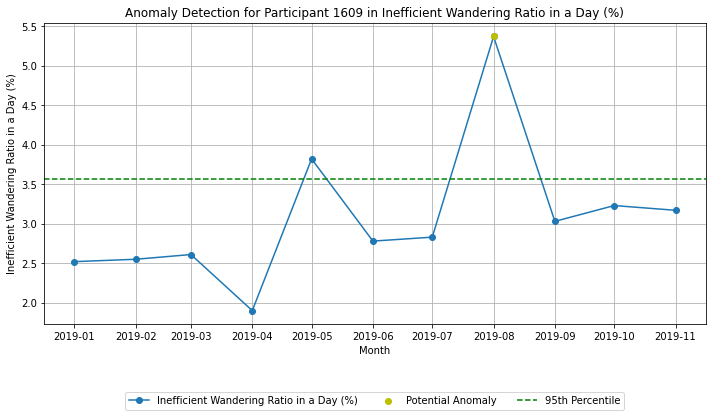

Inefficient_Ratio_Daily From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daily From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Daily From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222


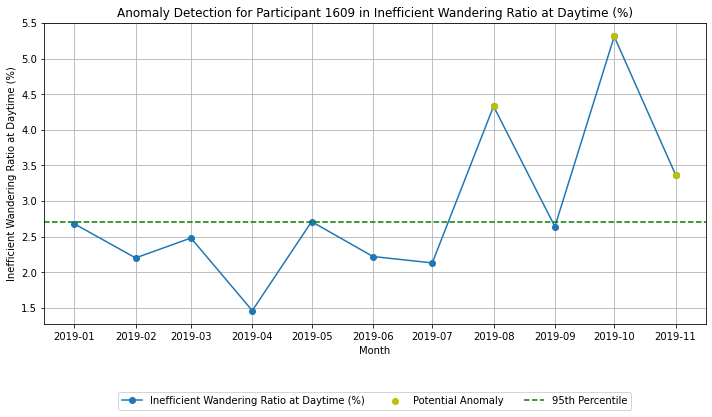

Inefficient_Ratio_Daytime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Daytime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Daytime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Daytime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daytime From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daytime From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222


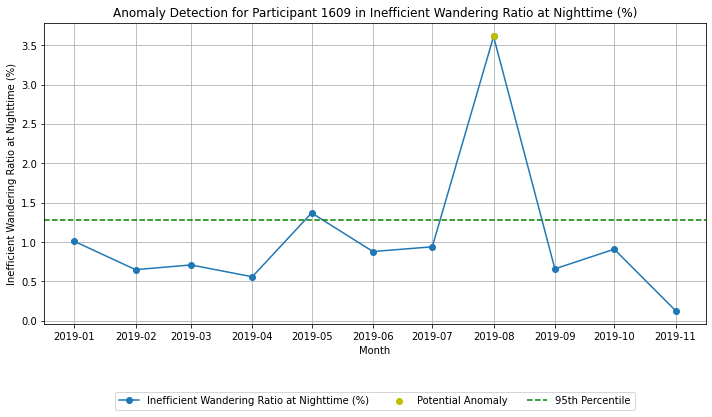

Inefficient_Ratio_Nighttime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Nighttime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Nighttime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Nighttime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444


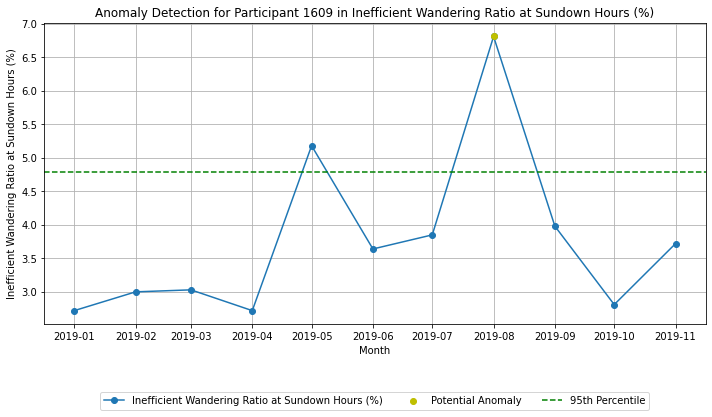

Inefficient_Ratio_Sundowning From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.5520524474738833 0.12597116307723114
Inefficient_Ratio_Sundowning From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Sundowning From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Sundowning From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend -0.06666666666666665 1.0


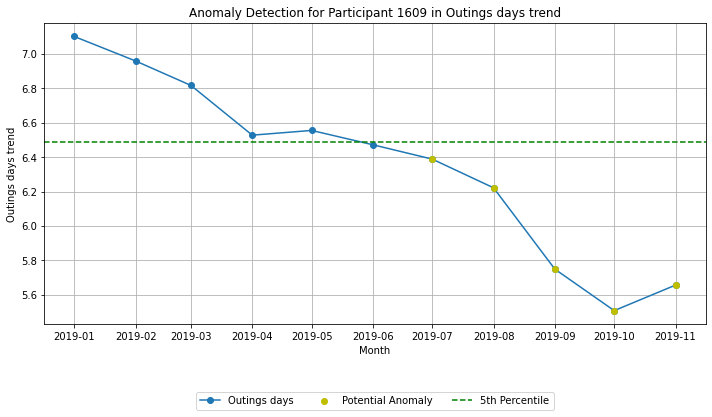

Outings_days From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 Decreasing Trend
Outings_days From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 Decreasing Trend
Outings_days From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 Decreasing Trend
Outings_days From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 Decreasing Trend
Outings_days From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 Decreasing Trend
Outings_days From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 Decreasing Trend


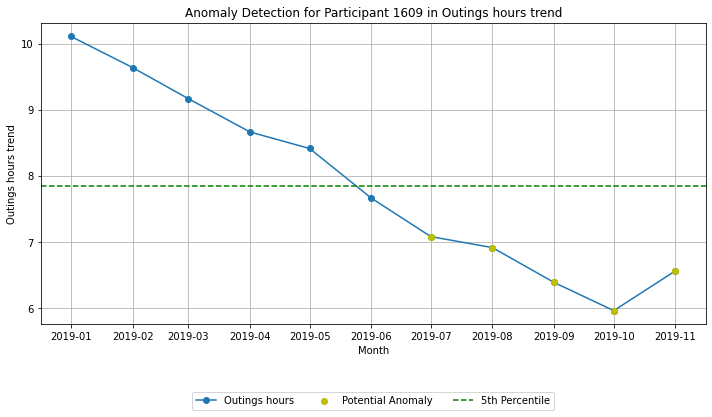

Outings_hours From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 Decreasing Trend
Outings_hours From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 Decreasing Trend
Outings_hours From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 Decreasing Trend
Outings_hours From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 Decreasing Trend
Outings_hours From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 Decreasing Trend
Outings_hours From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
1609 Earliest detected deterioration: (Timestamp('2019-07-01 00:00:00'), 'Outings_days') second_assessment date 2019-11-14 00:00:00
Patient 1615 Months we have data: 0   2019-01-01
1   2019-02-01
2   2019-03-01
3   2019-04-01
4   2019-05-01
5   2019-06-01
6   2019-07-01
7   2019-08-01
8   2019-09-01
9   2019-10-01
Name: Month, dtype: datetime64[ns]


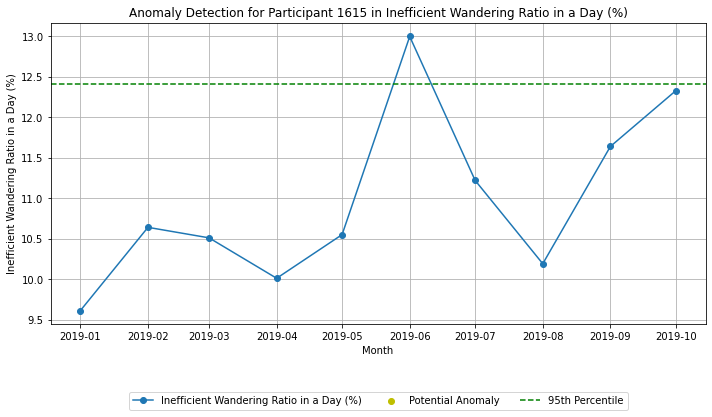

Inefficient_Ratio_Daily From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daily From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Daily From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daily From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.2 0.7194444444444444


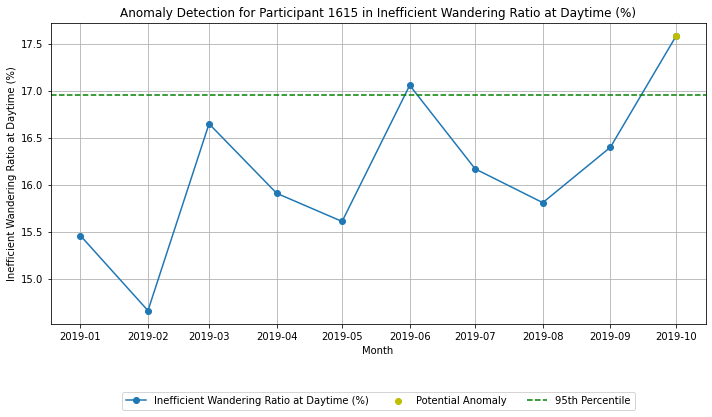

Inefficient_Ratio_Daytime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daytime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daytime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Daytime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Daytime From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222


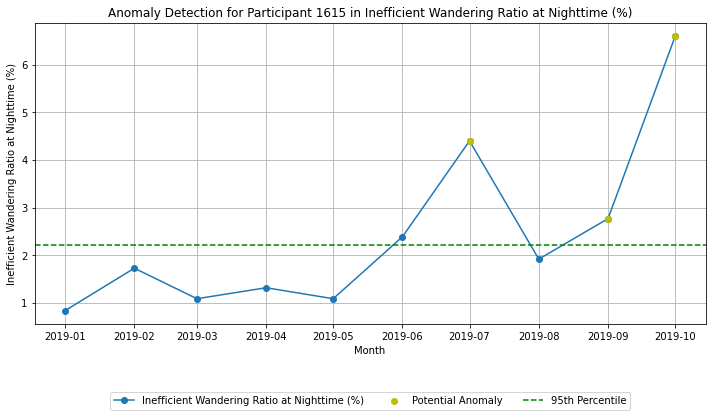

Inefficient_Ratio_Nighttime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.41403933560541256 0.2511180012744736
Inefficient_Ratio_Nighttime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.41403933560541256 0.2511180012744736
Inefficient_Ratio_Nighttime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.5520524474738833 0.12597116307723114
Inefficient_Ratio_Nighttime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Nighttime From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.6 0.1361111111111111


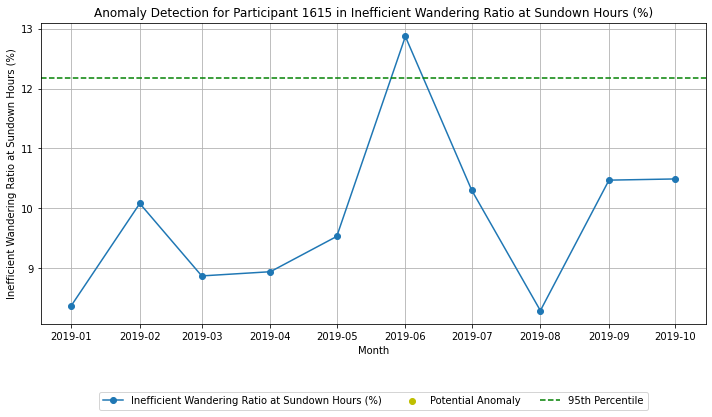

Inefficient_Ratio_Sundowning From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Sundowning From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Sundowning From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Sundowning From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.2 0.7194444444444444


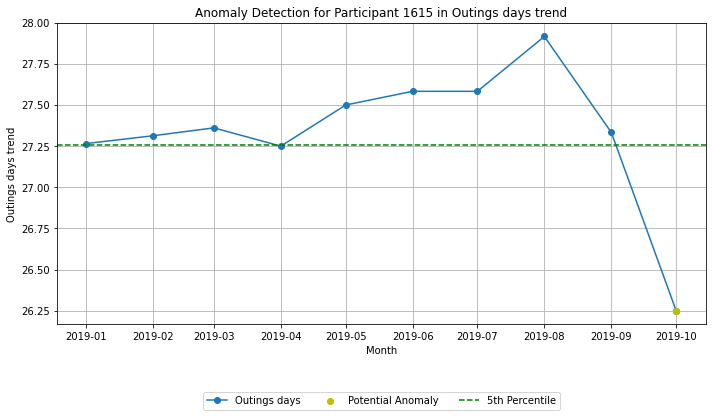

Outings_days From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.6 0.1361111111111111
Outings_days From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.6 0.1361111111111111
Outings_days From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Outings_days From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Outings_days From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444


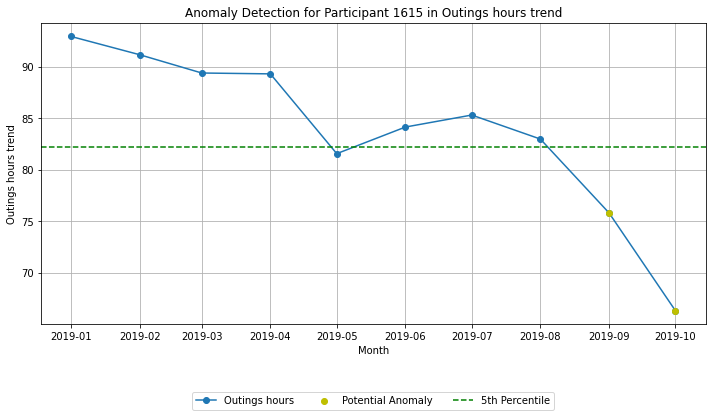

Outings_hours From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 Decreasing Trend
Outings_hours From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.6 0.1361111111111111
Outings_hours From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Outings_hours From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Outings_hours From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
1615 Earliest detected deterioration: None second_assessment date 2019-10-28 00:00:00
Patient 1617 Months we have data: 0    2018-12-01
1    2019-01-01
2    2019-02-01
3    2019-03-01
4    2019-04-01
5    2019-05-01
6    2019-06-01
7    2019-07-01
8    2019-08-01
9    2019-09-01
10   2019-10-01
11   2019-11-01
Name: Month, dtype: datetime64[ns]


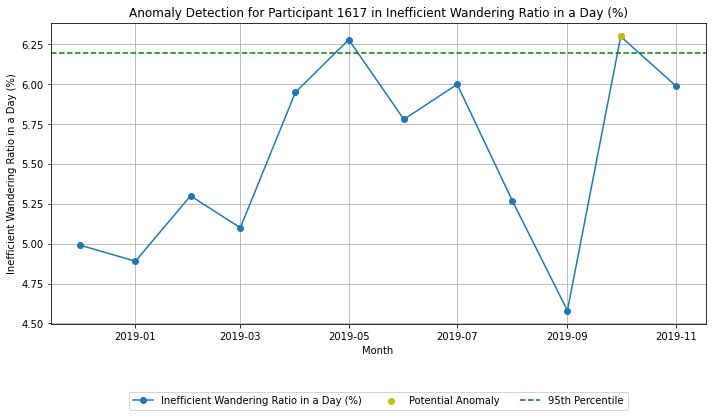

Inefficient_Ratio_Daily From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daily From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daily From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Daily From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Daily From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Daily From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend 0.06666666666666665 1.0


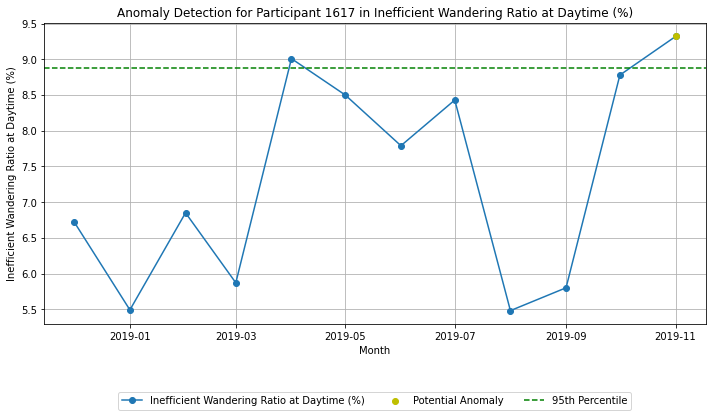

Inefficient_Ratio_Daytime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daytime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daytime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Daytime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daytime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daytime From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Daytime From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222


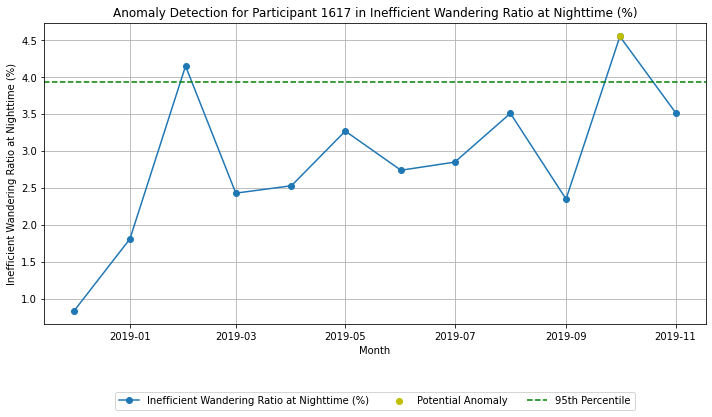

Inefficient_Ratio_Nighttime From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Nighttime From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Nighttime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Nighttime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Nighttime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Nighttime From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222


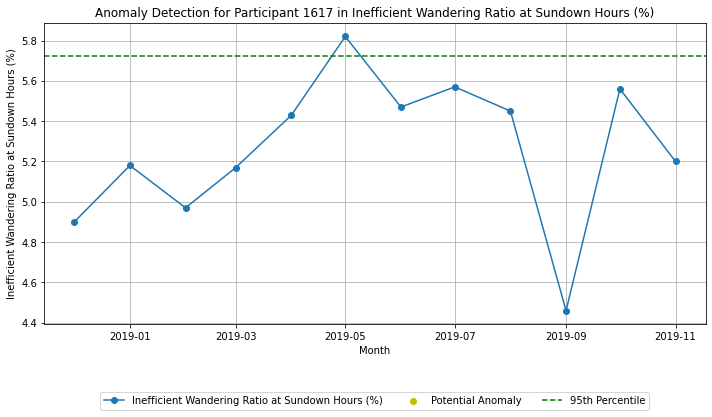

Inefficient_Ratio_Sundowning From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Sundowning From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Sundowning From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Sundowning From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Sundowning From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Sundowning From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444


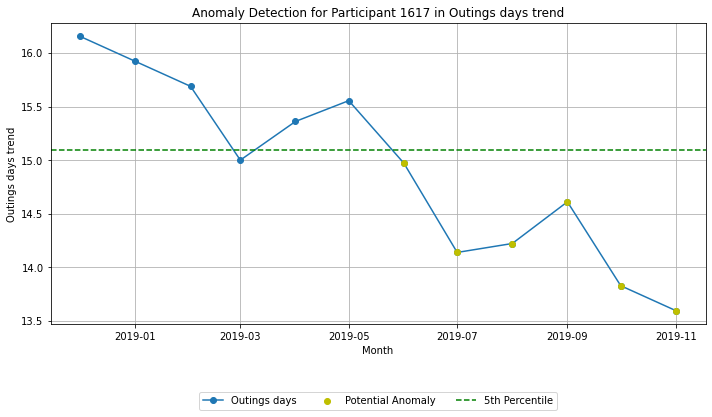

Outings_days From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend -0.6 0.1361111111111111
Outings_days From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.6 0.1361111111111111
Outings_days From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.6 0.1361111111111111
Outings_days From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Outings_days From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Outings_days From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend -0.6 0.1361111111111111
Outings_days From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend -0.6 0.1361111111111111


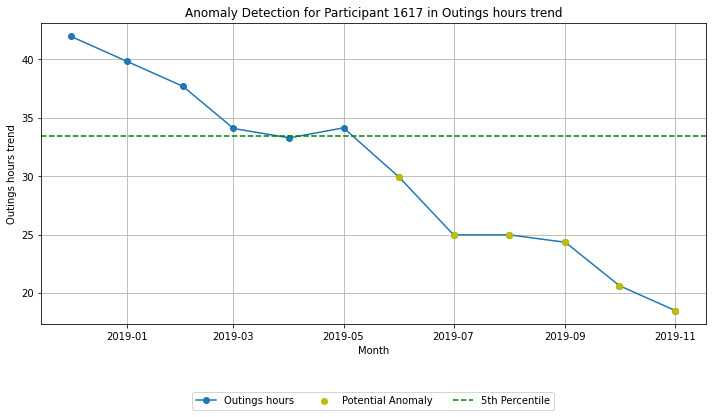

Outings_hours From 2018-12-01 00:00:00 to 2019-05-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Outings_hours From 2019-01-01 00:00:00 to 2019-06-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Outings_hours From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Outings_hours From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Outings_hours From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 Decreasing Trend
Outings_hours From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 Decreasing Trend
Outings_hours From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 Decreasing Trend
1617 Earliest detected deterioration: (Timestamp('2019-06-01 00:00:00'), 'Outings_hours') second_assessment date 2019-11-29 00:00:00
Patient 1628 Months we have data: 0   2019-02-01
1   2019-03-01
2   2019-04-01
3   2019-05-01
4   2019-06-01
5   2019-07-01
6   2019-08-01
7   2019-09-01
8   2019-10-01
Name: Month, dtyp

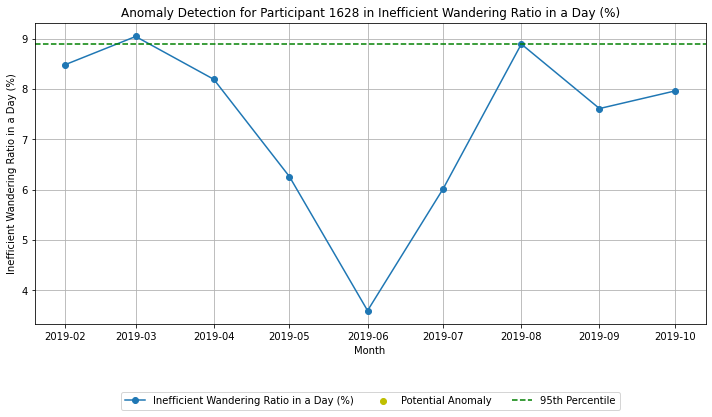

Inefficient_Ratio_Daily From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daily From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daily From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Daily From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222


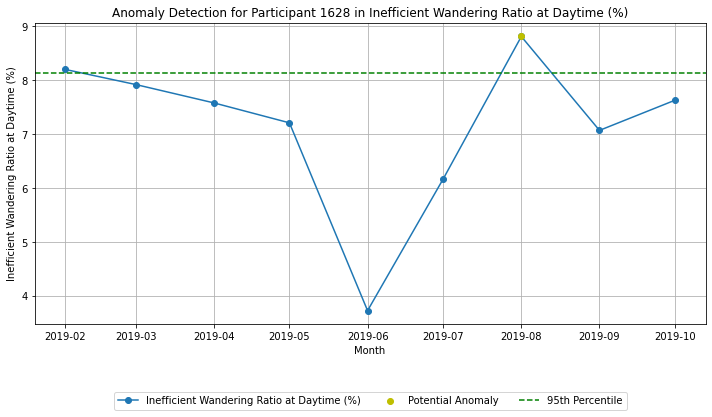

Inefficient_Ratio_Daytime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Daytime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Daytime From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444


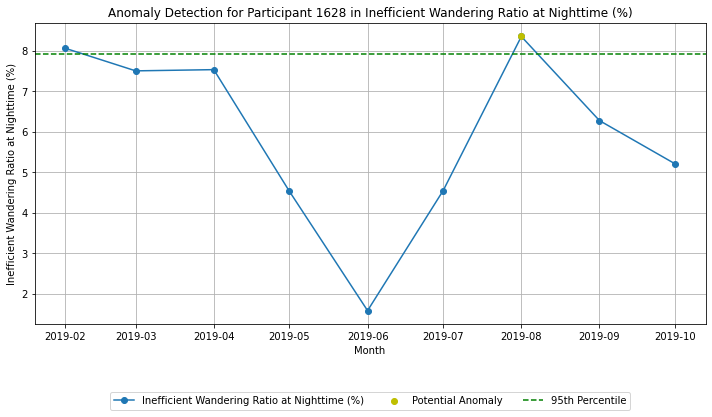

Inefficient_Ratio_Nighttime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Nighttime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Nighttime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222


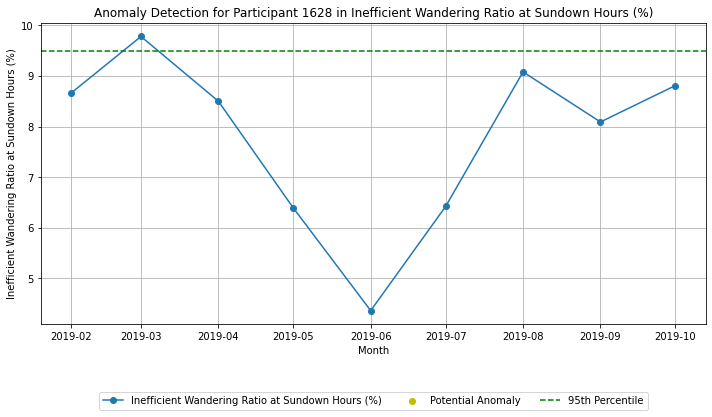

Inefficient_Ratio_Sundowning From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Sundowning From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Sundowning From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Sundowning From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.6 0.1361111111111111


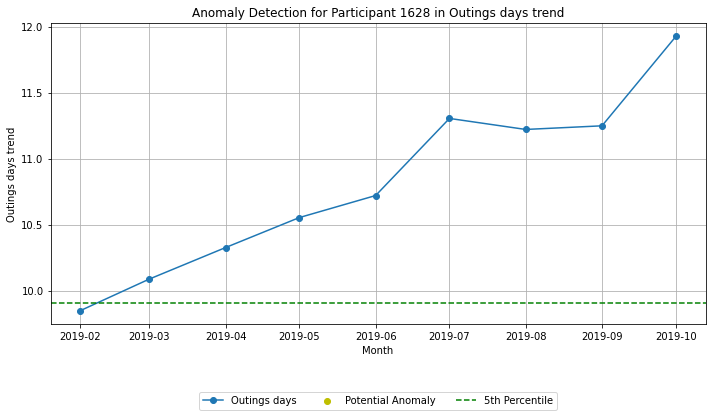

Outings_days From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Outings_days From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555


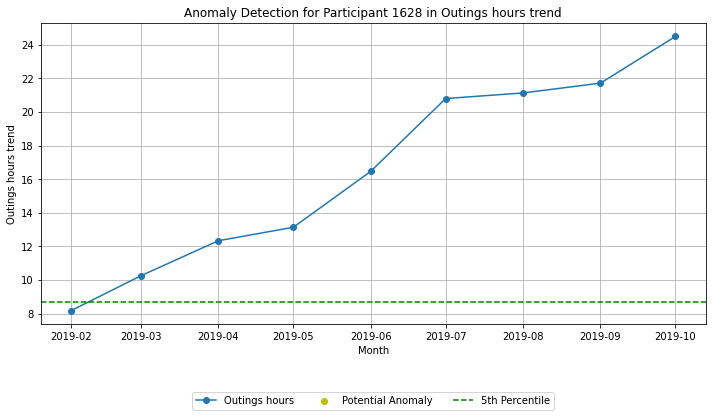

1628 Earliest detected deterioration: None second_assessment date 2019-10-23 00:00:00
Patient 1657 Months we have data: 0    2019-02-01
1    2019-03-01
2    2019-04-01
3    2019-05-01
4    2019-06-01
5    2019-07-01
6    2019-08-01
7    2019-09-01
8    2019-10-01
9    2019-11-01
10   2019-12-01
Name: Month, dtype: datetime64[ns]


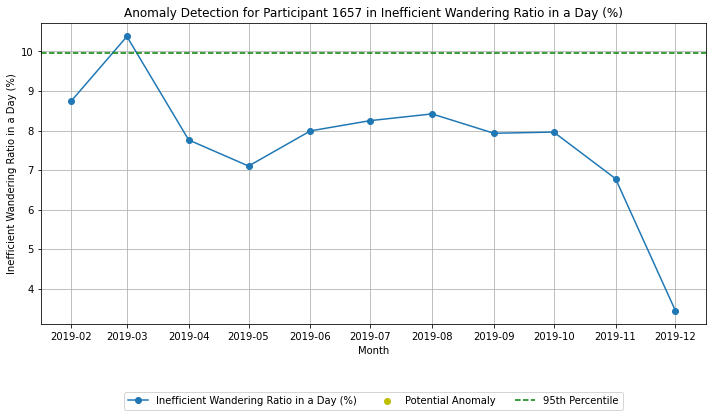

Inefficient_Ratio_Daily From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Daily From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Daily From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Daily From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Daily From 2019-07-01 00:00:00 to 2019-12-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555


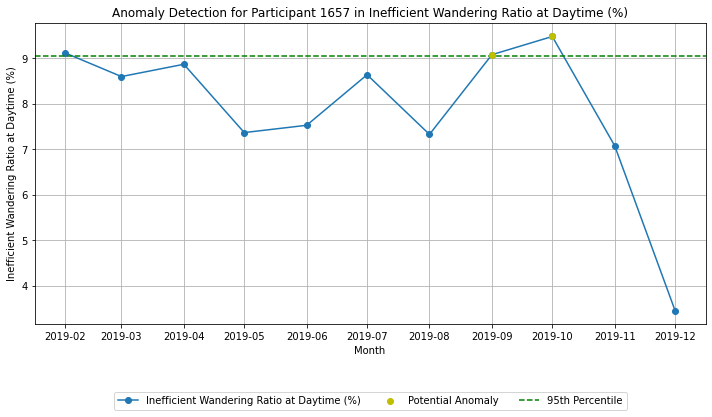

Inefficient_Ratio_Daytime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daytime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daytime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Daytime From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daytime From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Daytime From 2019-07-01 00:00:00 to 2019-12-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444


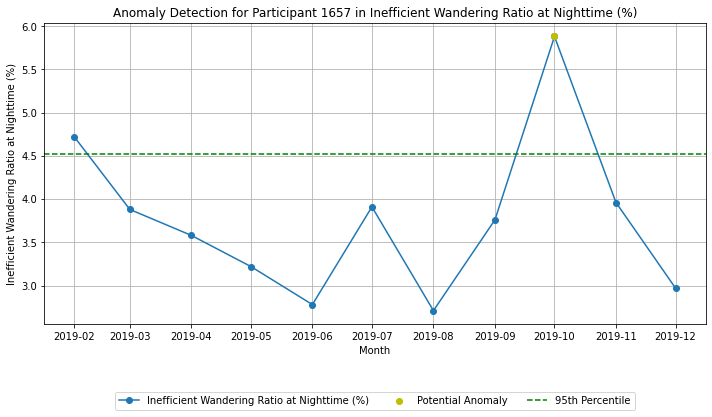

Inefficient_Ratio_Nighttime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Nighttime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Nighttime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Nighttime From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Nighttime From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Nighttime From 2019-07-01 00:00:00 to 2019-12-01 00:00:00 No Trend 0.06666666666666665 1.0


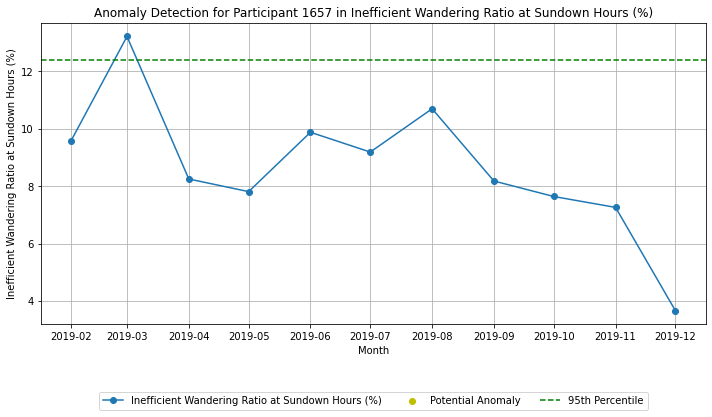

Inefficient_Ratio_Sundowning From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Sundowning From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Sundowning From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Sundowning From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Sundowning From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555


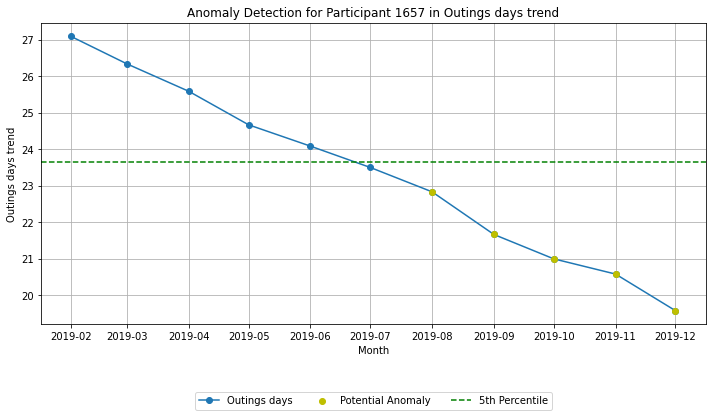

Outings_days From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 Decreasing Trend
Outings_days From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 Decreasing Trend
Outings_days From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 Decreasing Trend
Outings_days From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 Decreasing Trend
Outings_days From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 Decreasing Trend
Outings_days From 2019-07-01 00:00:00 to 2019-12-01 00:00:00 Decreasing Trend


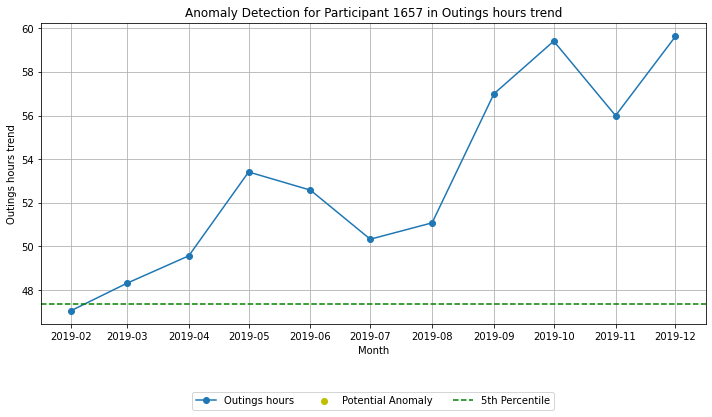

Outings_hours From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.6 0.1361111111111111
Outings_hours From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Outings_hours From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Outings_hours From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Outings_hours From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Outings_hours From 2019-07-01 00:00:00 to 2019-12-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
1657 Earliest detected deterioration: (Timestamp('2019-08-01 00:00:00'), 'Outings_days') second_assessment date 2019-12-12 00:00:00
Patient 1660 Months we have data: 0   2019-02-01
1   2019-03-01
2   2019-04-01
3   2019-05-01
4   2019-06-01
5   2019-07-01
6   2019-08-01
7   2019-09-01
8   2019-10-01
9   2019-11-01
Name: Month, dtype: datetime64[ns]


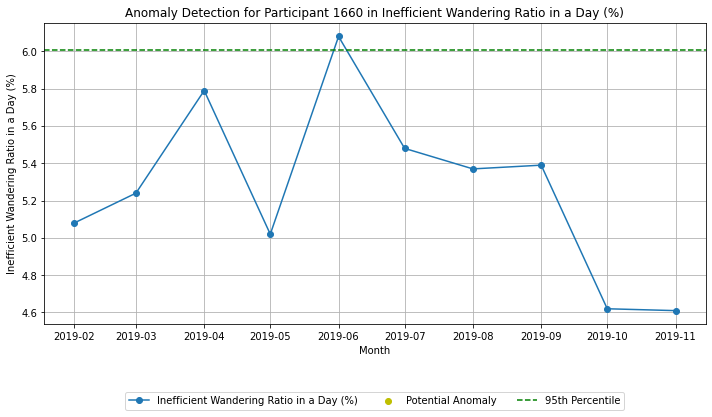

Inefficient_Ratio_Daily From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daily From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.06666666666666665 1.0
Inefficient_Ratio_Daily From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Daily From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444


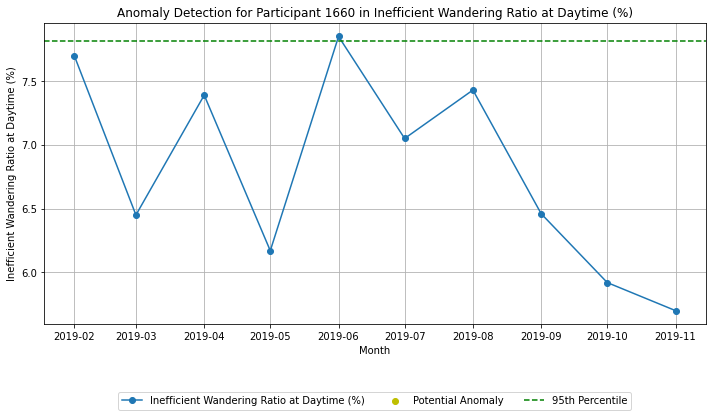

Inefficient_Ratio_Daytime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Daytime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Daytime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.06666666666666665 1.0
Inefficient_Ratio_Daytime From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444


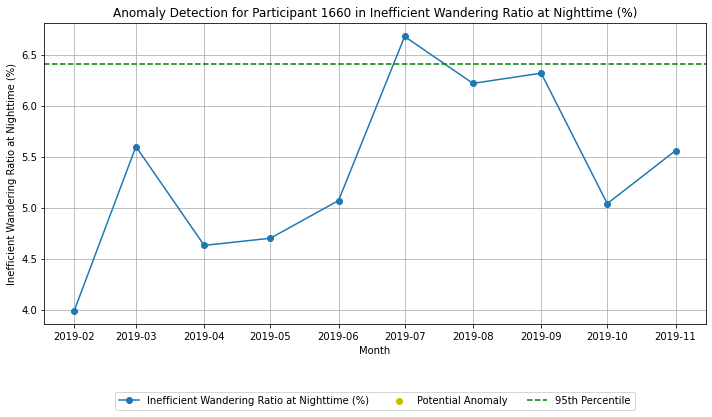

Inefficient_Ratio_Nighttime From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Nighttime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Nighttime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Nighttime From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend -0.2 0.7194444444444444


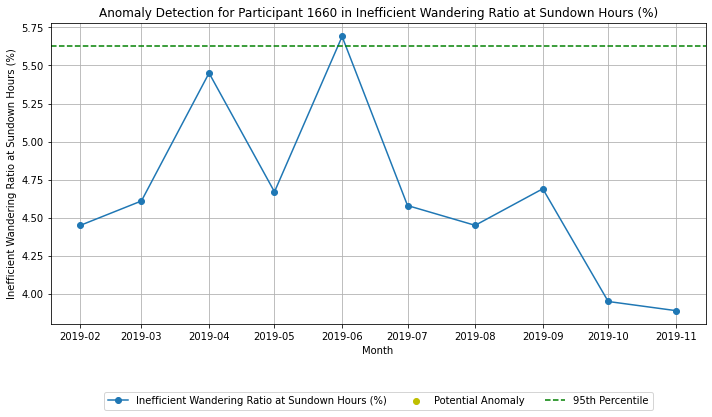

Inefficient_Ratio_Sundowning From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Sundowning From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Sundowning From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Sundowning From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend -0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend -0.7333333333333333 0.05555555555555555


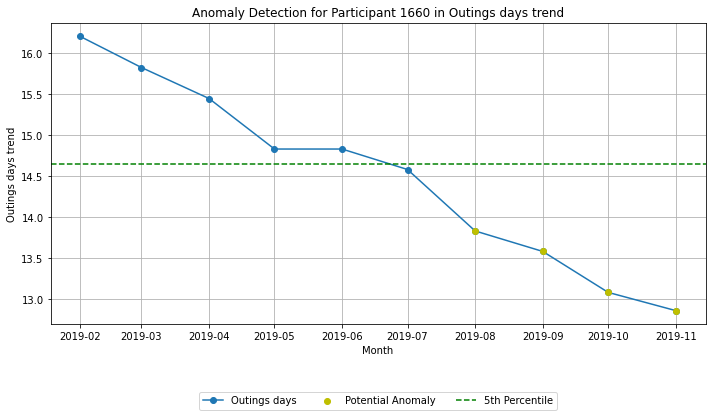

Outings_days From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 Decreasing Trend
Outings_days From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 Decreasing Trend
Outings_days From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 Decreasing Trend
Outings_days From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 Decreasing Trend
Outings_days From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 Decreasing Trend


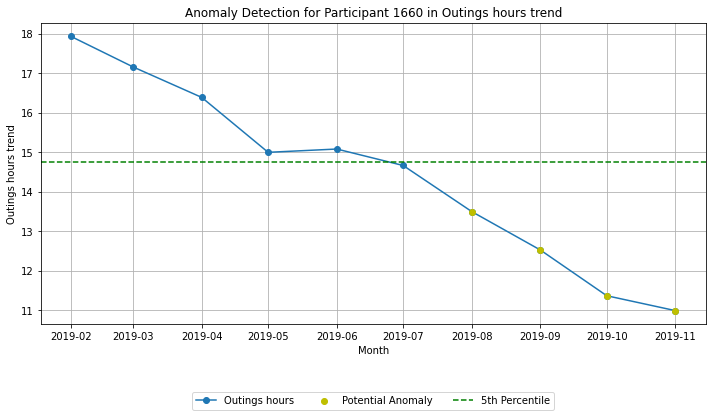

Outings_hours From 2019-02-01 00:00:00 to 2019-07-01 00:00:00 Decreasing Trend
Outings_hours From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 Decreasing Trend
Outings_hours From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 Decreasing Trend
Outings_hours From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 Decreasing Trend
Outings_hours From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 Decreasing Trend
1660 Earliest detected deterioration: (Timestamp('2019-08-01 00:00:00'), 'Outings_days') second_assessment date 2019-11-27 00:00:00
Patient 1706 Months we have data: 0    2019-03-01
1    2019-04-01
2    2019-05-01
3    2019-06-01
4    2019-07-01
5    2019-08-01
6    2019-09-01
7    2019-10-01
8    2019-11-01
9    2019-12-01
10   2020-01-01
11   2020-02-01
Name: Month, dtype: datetime64[ns]


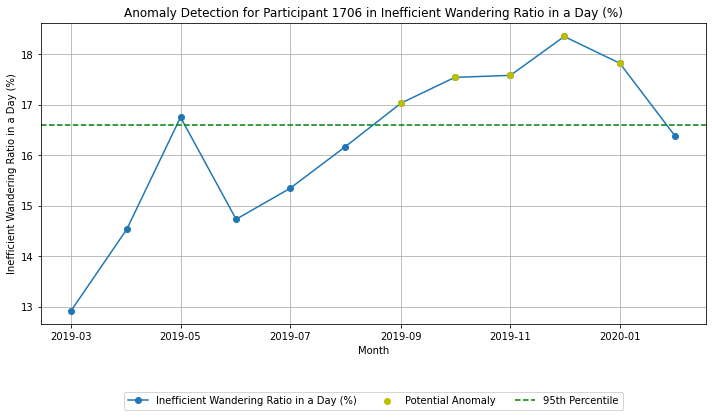

Inefficient_Ratio_Daily From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daily From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daily From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daily From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 Increasing Trend
Inefficient_Ratio_Daily From 2019-07-01 00:00:00 to 2019-12-01 00:00:00 Increasing Trend
Inefficient_Ratio_Daily From 2019-08-01 00:00:00 to 2020-01-01 00:00:00 Increasing Trend
Inefficient_Ratio_Daily From 2019-09-01 00:00:00 to 2020-02-01 00:00:00 No Trend 0.2 0.7194444444444444


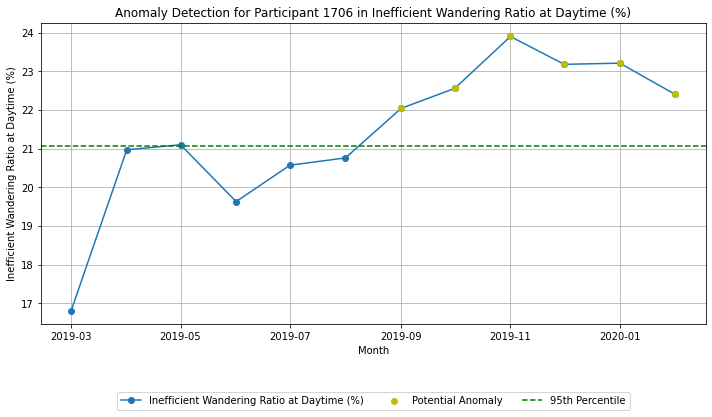

Inefficient_Ratio_Daytime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Daytime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.2 0.7194444444444444
Inefficient_Ratio_Daytime From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Daytime From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 Increasing Trend
Inefficient_Ratio_Daytime From 2019-07-01 00:00:00 to 2019-12-01 00:00:00 Increasing Trend
Inefficient_Ratio_Daytime From 2019-08-01 00:00:00 to 2020-01-01 00:00:00 No Trend 0.7333333333333333 0.05555555555555555
Inefficient_Ratio_Daytime From 2019-09-01 00:00:00 to 2020-02-01 00:00:00 No Trend 0.2 0.7194444444444444


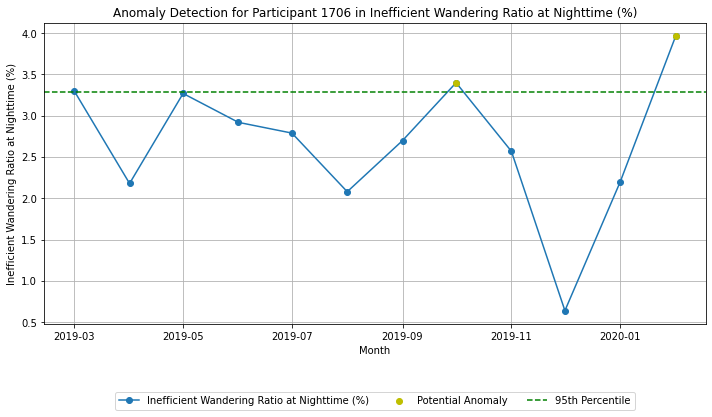

Inefficient_Ratio_Nighttime From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend -0.6 0.1361111111111111
Inefficient_Ratio_Nighttime From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Nighttime From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2019-07-01 00:00:00 to 2019-12-01 00:00:00 No Trend -0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Nighttime From 2019-08-01 00:00:00 to 2020-01-01 00:00:00 No Trend -0.2 0.7194444444444444
Inefficient_Ratio_Nighttime From 2019-09-01 00:00:00 to 2020-02-01 00:00:00 No Trend -0.06666666666666665 1.0


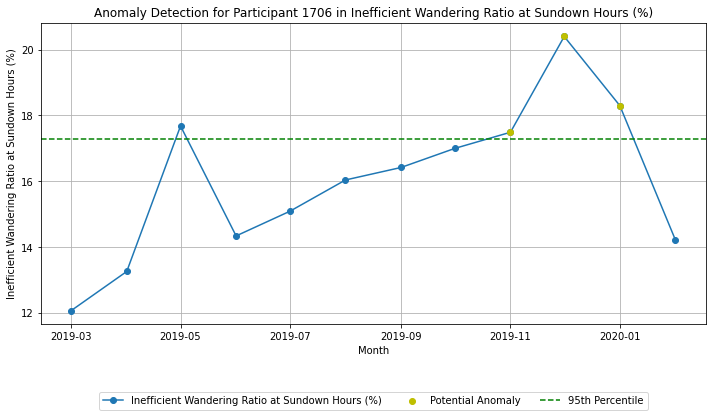

Inefficient_Ratio_Sundowning From 2019-03-01 00:00:00 to 2019-08-01 00:00:00 No Trend 0.6 0.1361111111111111
Inefficient_Ratio_Sundowning From 2019-04-01 00:00:00 to 2019-09-01 00:00:00 No Trend 0.4666666666666666 0.2722222222222222
Inefficient_Ratio_Sundowning From 2019-05-01 00:00:00 to 2019-10-01 00:00:00 No Trend 0.3333333333333333 0.46944444444444444
Inefficient_Ratio_Sundowning From 2019-06-01 00:00:00 to 2019-11-01 00:00:00 Increasing Trend
Inefficient_Ratio_Sundowning From 2019-07-01 00:00:00 to 2019-12-01 00:00:00 Increasing Trend
Inefficient_Ratio_Sundowning From 2019-08-01 00:00:00 to 2020-01-01 00:00:00 Increasing Trend
Inefficient_Ratio_Sundowning From 2019-09-01 00:00:00 to 2020-02-01 00:00:00 No Trend 0.2 0.7194444444444444


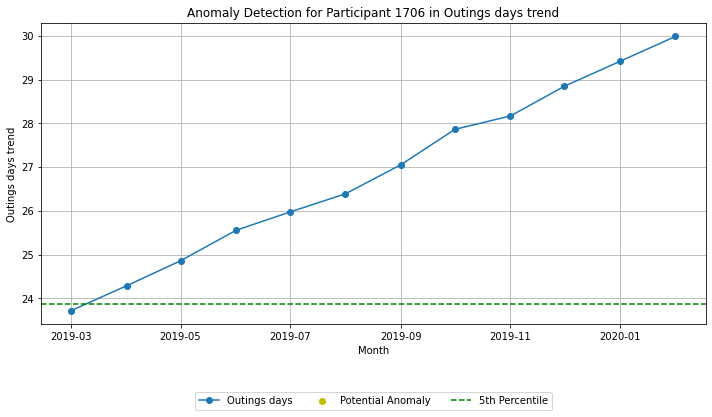

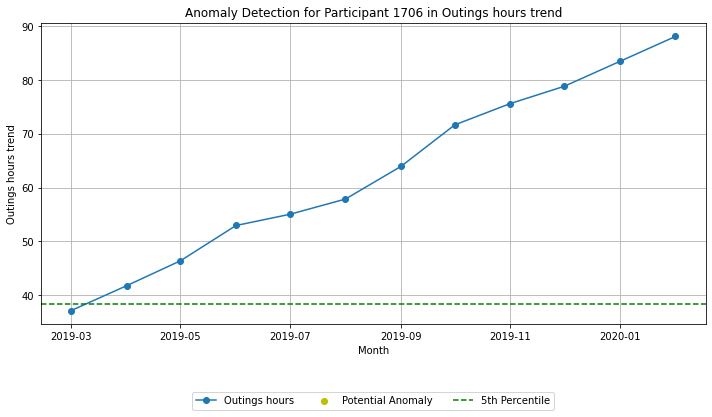

1706 Earliest detected deterioration: (Timestamp('2019-09-01 00:00:00'), 'Inefficient_Ratio_Daily') second_assessment date 2020-02-21 00:00:00


In [33]:
final_anomaly={}
users_evaluation_dfs = {}
period_training = 6
for patient in patients:
    final_anomaly[patient]={}
    users_evaluation_dfs[patient]=[]
    #(1.1) read Outings
    outing_data=readData_dfs(patient)
    outing_data['Month'] = pd.to_datetime(outing_data['Month'])
    

    #(1.2) read Wandering
    wandering_data = readData_wandering(patient)
    wandering_data['Month'] = pd.to_datetime(wandering_data['Month'])

    # Replace all columns except 'Month' in wandering_data where outing_data has NaN for the same 'Month'
    matching_nan_months = outing_data.loc[outing_data.isna().any(axis=1), 'Month']
    wandering_data.loc[wandering_data['Month'].isin(matching_nan_months), wandering_data.columns.difference(['Month'])] = np.nan


    # Find months in outing_data that are missing in wandering_data
    missing_months = outing_data.loc[~outing_data['Month'].isin(wandering_data['Month']), 'Month']
    
    # Create a DataFrame with these missing months and NaN values for other columns
    missing_rows = pd.DataFrame(
        {col: np.nan for col in wandering_data.columns}, 
        index=missing_months.index
    )
    missing_rows['Month'] = missing_months.values

    # Append the missing rows to wandering_data and sort by Month
    wandering_data = pd.concat([wandering_data, missing_rows], ignore_index=True).sort_values('Month')

    # Reset index for consistency
    wandering_data.reset_index(drop=True, inplace=True)


#     #(2) only keep month that we have clinical information
#     outing_data['health_status'] = outing_data.apply(determine_health_status, axis=1, patient=patient)
#     outing_data.sort_values('Month', inplace=True)
#     outing_data = outing_data[outing_data['health_status'] != 'Unknown']
    
    #(2) # fill missing with the average of the previous 3 months data &  decompose outings (find trend)
    for feature in outing_data.columns.tolist()[1:3]:
        manual_rolling_mean(outing_data, feature, window=3) #fill the Nan
        
        #removes the seasonal component from the data but does not smooth the data.
        outing_data[feature]=decompose_series(outing_data[feature],period_training)
        
        # smooth the data
#         rolling_means(outing_data, feature, window=3)
     
    #(2)fill missing with the average of the previous 3 months data 
    for feature in wandering_data.columns.tolist()[1:]:
        manual_rolling_mean(wandering_data, feature, window=3) #fill the Nan
        
#         rolling_means(wandering_data, feature, window=3)
        
        
        
#         wandering_data[feature]=smooth_series_with_moving_average(wandering_data[feature],period_training)
#         wandering_data[feature]=decompose_series(wandering_data[feature],period_training)

#     # Reset index to make 'month' a column again
#     wandering_data.reset_index(inplace=True)

#     # Rename the index column to 'Month'
    wandering_data.rename(columns={'index': 'Month'}, inplace=True)

    # (3) Merge the outing data with wandering data
    df = pd.merge(wandering_data, outing_data, on='Month', how='inner')

    df['Month'] = pd.to_datetime(df['Month'])

    df['health_status'] = df.apply(determine_health_status, axis=1, patient=patient)
    df.sort_values('Month', inplace=True)
    df = df[df['health_status'] != 'Unknown']

    
    # Determine cutoff months directly based on assessments
    first_assessment = pd.Timestamp(
        str(list(filtered_clinical[(filtered_clinical['home_id'] == patient) & (
            filtered_clinical['redcap_event_name'] == 'baseline_visit_arm_1')]['date_screen'])[0])
    )
    second_assessment = pd.Timestamp(
        str(list(filtered_clinical[(filtered_clinical['home_id'] == patient) & (
            filtered_clinical['redcap_event_name'] == 'month_12_arm_1')]['date_screen'])[0])
    )

    df['Testing Month'] = range(1, len(df) + 1)
    cutoff_month = df[df['Month'] <= second_assessment]['Testing Month'].max()
    df = df[df['Testing Month'] <= cutoff_month]
    print("Patient", patient,"Months we have data:", df['Month'])
    
    
    # (4) Find feature data
    numeric_columns = df.drop(['Month', 'health_status','Testing Month'], axis=1)
    
    


    #(3) Find feature data
    #Anomaly detection
    for col_name in numeric_columns:
        final_anomaly[patient][col_name]={}

    #     results_cusum=anomaly_cusum(df, col_name, period_training)
        results_threshold=anomaly_detection(df, col_name, period_training)
#         results_IsolationForest=anomaly_detectionIsolationForest(df, col_name, period_training)
        results_mann = mann_kendall_test_by_segments(df, col_name, period_training)
        final_anomaly[patient][col_name]=[results_threshold,results_mann]

    results=final_anomaly[patient]
    trend_periods = extract_and_expand_mann_kendall_periods(results)
    combined_anomalies = find_combined_anomalies(results, trend_periods)

    # Determine months that are consistently flagged as anomalous across all three methods
    final_anomalies = {feature: sorted(list(dates)) for feature, dates in combined_anomalies.items() if dates}
    # Assessment dates
    first_assessment = pd.Timestamp(str(list(filtered_clinical[(filtered_clinical['home_id']==patient) & (
        filtered_clinical['redcap_event_name']=='baseline_visit_arm_1')]['date_screen'])[0]))

    second_assessment = pd.Timestamp(pd.Timestamp(str(list(filtered_clinical[(filtered_clinical['home_id']==patient) & (
        filtered_clinical['redcap_event_name']=='month_12_arm_1')]['date_screen'])[0])))

    # Combine all detected anomalies into a single set
    all_anomalies = []
    for feature, anomaly_list in final_anomalies.items():
        for date in anomaly_list:
            all_anomalies.append((date, feature))
        
    # Sort anomalies
    all_anomalies.sort(key=lambda x: x[0])

    # Identify potential health deterioration
#     early_warnings = [date for date in all_anomalies if date < second_assessment]
    early_warnings = [(date, feature) for date, feature in all_anomalies if date < second_assessment]

    # Determine the earliest detected deterioration
    earliest_deterioration = early_warnings[0] if early_warnings else None

    print(patient, f"Earliest detected deterioration: {earliest_deterioration}",'second_assessment date',second_assessment)

    # Create a DataFrame to evaluate model performance based on the existing months in df
    evaluation_df = df[['Month']].copy()

#     # Mark health status based on assessments
    evaluation_df['Predicted Health Status'] = df[['health_status']].copy()
    # Mark health status based on assessments
    evaluation_df['Actual Health Status'] = df[['health_status']].copy()

    # Flag early warnings
#     evaluation_df['Detected Anomaly'] = evaluation_df['Month'].isin(all_anomalies)
#     evaluation_df['Detected Features'] = evaluation_df['Month'].isin(features)

    # Create a dictionary to map months to detected features
    detected_features = {date: [] for date, _ in all_anomalies}
    for date, feature in all_anomalies:
        detected_features[date].append(feature)

#     # Flag early warnings
    evaluation_df['Detected Anomaly'] = evaluation_df['Month'].isin([date for date, _ in all_anomalies])

    # Function to get features for a given month
    def get_features_for_month(month):
        return detected_features.get(month, [])

    # Apply the function to get the detected features for each month
    evaluation_df['Contributing Features'] = evaluation_df['Month'].apply(get_features_for_month)
 
    # Optional: Convert the list of features to a string for better readability
    evaluation_df['Contributing Features'] = evaluation_df['Contributing Features'].apply(lambda x: ', '.join(x) if x else None)



    # Apply condition based on 'Detected_Anomaly'
    evaluation_df['Predicted Health Status'] = np.where(
        evaluation_df['Detected Anomaly'],  # Condition
        'Potential Deterioration',          # Value if True
        'No change'                         # Value if False
    )
    
#     # Adjust the health status for months flagged as anomalies before the second assessment
#     evaluation_df.loc[(evaluation_df['Month'] < second_assessment) & (evaluation_df['Detected Anomaly']), 'Predicted Health Status'] = 'Potential Deterioration'

#     # Adjust the health status for months flagged as anomalies after the second assessment
#     evaluation_df.loc[(evaluation_df['Month'] > second_assessment) & (evaluation_df['Detected Anomaly']), 'Predicted Health Status'] = 'Potential Deterioration'

#     print(evaluation_df)
    users_evaluation_dfs[patient]=evaluation_df

In [34]:
# final_anomaly={}
# users_evaluation_dfs = {}
# period_training = 6
# for patient in patients:
#     final_anomaly[patient]={}
#     users_evaluation_dfs[patient]=[]
#     #(1.1) read Outings
#     outing_data=readData_dfs(patient)
#     outing_data['Month'] = pd.to_datetime(outing_data['Month'])
    

#     #(1.2) read Wandering
#     wandering_data = readData_wandering(patient)
#     wandering_data['Month'] = pd.to_datetime(wandering_data['Month'])

#     # Replace all columns except 'Month' in wandering_data where outing_data has NaN for the same 'Month'
#     matching_nan_months = outing_data.loc[outing_data.isna().any(axis=1), 'Month']
#     wandering_data.loc[wandering_data['Month'].isin(matching_nan_months), wandering_data.columns.difference(['Month'])] = np.nan


#     # Find months in outing_data that are missing in wandering_data
#     missing_months = outing_data.loc[~outing_data['Month'].isin(wandering_data['Month']), 'Month']
    
#     # Create a DataFrame with these missing months and NaN values for other columns
#     missing_rows = pd.DataFrame(
#         {col: np.nan for col in wandering_data.columns}, 
#         index=missing_months.index
#     )
#     missing_rows['Month'] = missing_months.values

#     # Append the missing rows to wandering_data and sort by Month
#     wandering_data = pd.concat([wandering_data, missing_rows], ignore_index=True).sort_values('Month')

#     # Reset index for consistency
#     wandering_data.reset_index(drop=True, inplace=True)


# #     #(2) only keep month that we have clinical information
# #     outing_data['health_status'] = outing_data.apply(determine_health_status, axis=1, patient=patient)
# #     outing_data.sort_values('Month', inplace=True)
# #     outing_data = outing_data[outing_data['health_status'] != 'Unknown']
    
#     #(2) # fill missing with the average of the previous 3 months data &  decompose outings (find trend)
#     for feature in outing_data.columns.tolist()[1:3]:
#         manual_rolling_mean(outing_data, feature, window=3) #fill the Nan
#         outing_data[feature]=decompose_series(outing_data[feature],period_training)
#         rolling_means(outing_data, feature, window=3)
#      # 
#     #(2)fill missing with the average of the previous 3 months data 
#     for feature in wandering_data.columns.tolist()[1:]:
#         manual_rolling_mean(wandering_data, feature, window=3) #fill the Nan
        
#         # Step 1: Remove residuals
#         cleaned_ratios, trend, residuals = remove_residuals(wandering_data[feature], window=3)


#         # Step 2: Apply smoothing
#         smoothed_ratios = smooth_series(cleaned_ratios, window=3)

        
        
# #         rolling_means(wandering_data, feature, window=3)
        
        
        
# #         wandering_data[feature]=smooth_series_with_moving_average(wandering_data[feature],period_training)
# #         wandering_data[feature]=decompose_series(wandering_data[feature],period_training)

# #     # Reset index to make 'month' a column again
# #     wandering_data.reset_index(inplace=True)

# #     # Rename the index column to 'Month'
#     wandering_data.rename(columns={'index': 'Month'}, inplace=True)

#     # (3) Merge the outing data with wandering data
#     df = pd.merge(wandering_data, outing_data, on='Month', how='inner')

#     df['Month'] = pd.to_datetime(df['Month'])

#     df['health_status'] = df.apply(determine_health_status, axis=1, patient=patient)
#     df.sort_values('Month', inplace=True)
#     df = df[df['health_status'] != 'Unknown']

    
#     # Determine cutoff months directly based on assessments
#     first_assessment = pd.Timestamp(
#         str(list(filtered_clinical[(filtered_clinical['home_id'] == patient) & (
#             filtered_clinical['redcap_event_name'] == 'baseline_visit_arm_1')]['date_screen'])[0])
#     )
#     second_assessment = pd.Timestamp(
#         str(list(filtered_clinical[(filtered_clinical['home_id'] == patient) & (
#             filtered_clinical['redcap_event_name'] == 'month_12_arm_1')]['date_screen'])[0])
#     )

#     df['Testing Month'] = range(1, len(df) + 1)
#     cutoff_month = df[df['Month'] <= second_assessment]['Testing Month'].max()
#     df = df[df['Testing Month'] <= cutoff_month]
#     print("Patient", patient,"Months we have data:", df['Month'])
    
    
#     # (4) Find feature data
#     numeric_columns = df.drop(['Month', 'health_status','Testing Month'], axis=1)
    
    

    
    

#     #(3) Find feature data



#     #Anomaly detection
#     for col_name in numeric_columns:
#         final_anomaly[patient][col_name]={}

#     #     results_cusum=anomaly_cusum(df, col_name, period_training)
#         results_threshold=anomaly_detection(df, col_name, period_training)
# #         results_IsolationForest=anomaly_detectionIsolationForest(df, col_name, period_training)
#         results_mann = mann_kendall_test_by_segments(df, col_name, period_training)
#         final_anomaly[patient][col_name]=[results_threshold,results_mann]

#     results=final_anomaly[patient]
#     trend_periods = extract_and_expand_mann_kendall_periods(results)
#     combined_anomalies = find_combined_anomalies(results, trend_periods)

#     # Determine months that are consistently flagged as anomalous across all three methods
#     final_anomalies = {feature: sorted(list(dates)) for feature, dates in combined_anomalies.items() if dates}
#     # Assessment dates
#     first_assessment = pd.Timestamp(str(list(filtered_clinical[(filtered_clinical['home_id']==patient) & (
#         filtered_clinical['redcap_event_name']=='baseline_visit_arm_1')]['date_screen'])[0]))

#     second_assessment = pd.Timestamp(pd.Timestamp(str(list(filtered_clinical[(filtered_clinical['home_id']==patient) & (
#         filtered_clinical['redcap_event_name']=='month_12_arm_1')]['date_screen'])[0])))

#     # Combine all detected anomalies into a single set
#     all_anomalies = []
#     for feature, anomaly_list in final_anomalies.items():
#         for date in anomaly_list:
#             all_anomalies.append((date, feature))
        
#     # Sort anomalies
#     all_anomalies.sort(key=lambda x: x[0])

#     # Identify potential health deterioration
# #     early_warnings = [date for date in all_anomalies if date < second_assessment]
#     early_warnings = [(date, feature) for date, feature in all_anomalies if date < second_assessment]

#     # Determine the earliest detected deterioration
#     earliest_deterioration = early_warnings[0] if early_warnings else None

#     print(patient, f"Earliest detected deterioration: {earliest_deterioration}",'second_assessment date',second_assessment)

#     # Create a DataFrame to evaluate model performance based on the existing months in df
#     evaluation_df = df[['Month']].copy()

# #     # Mark health status based on assessments
#     evaluation_df['Predicted Health Status'] = df[['health_status']].copy()
#     # Mark health status based on assessments
#     evaluation_df['Actual Health Status'] = df[['health_status']].copy()

#     # Flag early warnings
# #     evaluation_df['Detected Anomaly'] = evaluation_df['Month'].isin(all_anomalies)
# #     evaluation_df['Detected Features'] = evaluation_df['Month'].isin(features)

#     # Create a dictionary to map months to detected features
#     detected_features = {date: [] for date, _ in all_anomalies}
#     for date, feature in all_anomalies:
#         detected_features[date].append(feature)

# #     # Flag early warnings
#     evaluation_df['Detected Anomaly'] = evaluation_df['Month'].isin([date for date, _ in all_anomalies])

#     # Function to get features for a given month
#     def get_features_for_month(month):
#         return detected_features.get(month, [])

#     # Apply the function to get the detected features for each month
#     evaluation_df['Contributing Features'] = evaluation_df['Month'].apply(get_features_for_month)
 
#     # Optional: Convert the list of features to a string for better readability
#     evaluation_df['Contributing Features'] = evaluation_df['Contributing Features'].apply(lambda x: ', '.join(x) if x else None)



#     # Apply condition based on 'Detected_Anomaly'
#     evaluation_df['Predicted Health Status'] = np.where(
#         evaluation_df['Detected Anomaly'],  # Condition
#         'Potential Deterioration',          # Value if True
#         'No change'                         # Value if False
#     )
    
# #     # Adjust the health status for months flagged as anomalies before the second assessment
# #     evaluation_df.loc[(evaluation_df['Month'] < second_assessment) & (evaluation_df['Detected Anomaly']), 'Predicted Health Status'] = 'Potential Deterioration'

# #     # Adjust the health status for months flagged as anomalies after the second assessment
# #     evaluation_df.loc[(evaluation_df['Month'] > second_assessment) & (evaluation_df['Detected Anomaly']), 'Predicted Health Status'] = 'Potential Deterioration'

# #     print(evaluation_df)
#     users_evaluation_dfs[patient]=evaluation_df

### To detect health deterioration before the second assessment and accurately evaluating the model's performance, we can implement an approach that dynamically evaluates the detection results as new data comes in. 

#### Treat detected anomalies before the second assessment as potential indicators of health deterioration.


Early Warning Period: Define a period before the second assessment where Potential_Deterioration should not be considered a false positive.


In [35]:
# Iterate through each user's evaluation DataFrame
for user_id, df in users_evaluation_dfs.items():
    # Find the corresponding cutoff date for the user in the `second_year` DataFrame
    cutoff_date = second_year.loc[second_year['home_id'] == user_id, 'date_screen'].values[0]
    df['Month'] = pd.to_datetime(df['Month'])
    
    df['Testing Month'] = range(1, len(df) + 1)
    cutoff_month = df[df['Month'] <= cutoff_date]['Testing Month'].max()
    # Filter out months that are after the cutoff date
    users_evaluation_dfs[user_id] = df[df['Testing Month'] <= cutoff_month]

In [36]:
def calculate_metrics(evaluation_df):
    no_change=Potential_Deterioration=tp = tn = fp = fn = delays = 0
    
    for _, row in evaluation_df.iterrows():
        actual = row['Actual Health Status']
        predicted = row['Predicted Health Status']
        features = row['Contributing Features']
        
        if (actual == 'Healthy' or actual == 'Potential Healthy')  and (predicted != 'Potential Deterioration'):
            tn += 1  
                
            
        elif (actual == 'Healthy' or actual == 'Potential Healthy')  and (predicted == 'Potential Deterioration'):
#             if features is not None and 'Inefficient' in features:
            fp += 1  # False Alert
#             else:
#                 tn += 1  
            
        elif (actual == 'Potential Healthy')  and (predicted == 'Potential Deterioration'):
            Potential_Deterioration += 1  
        
#         elif (actual == 'MCI')  and (predicted =='Potential Deterioration'):
#             tp  += 1
        
           
#         elif (actual == 'Potential MCI') and (predicted == 'Potential Deterioration'):
#             Potential_Deterioration += 1 
          
#         elif (actual == 'MCI')  and (predicted !='Potential Deterioration'):  
#             no_change+=1
            

#         elif (actual == 'Potential MCI') and (predicted !='Potential Deterioration'):
#             fn += 1  # Delay

    return tp, tn-6, fp, fn, Potential_Deterioration,no_change

In [37]:
#evaluate seperately

all_healthy_user=all_healthy.keys()
from_healthy_to_mci_users=from_healthy_to_mci.keys()
remain_mci_users=remain_mci .keys()

# 1. All_healthy_user

In [38]:
physical_healthy=[1541,1559, 1572, 1582, 1586, 1592,1617, 1706]
all_healthy_user=[a for a in all_healthy_user if a not in physical_healthy]

### When dealing with a subset of users who are always healthy (i.e., no true positives or false negatives), traditional metrics like TP, FN, precision, recall, and F1 score become less meaningful. However, we can still consider other metrics to evaluate the model's performance for these users.

Metrics to Consider for Always Healthy Users
* True Negatives (TN): The number of correctly identified healthy instances.
* False Positives (FP): The number of instances incorrectly identified as potential deterioration.
* Accuracy: The proportion of true results (both true positives and true negatives) among the total number of cases examined.
* Specificity (True Negative Rate): The proportion of actual negatives that are correctly identified (TN / (TN + FP)).

In [39]:
def calculate_performance_metrics(tp, tn, fp, fn):
    # Ensure we handle cases where denominators are zero
    precision = round(tp / (tp + fp),2) if (tp + fp) != 0 else None
    recall = round(tp / (tp + fn),2) if (tp + fn) != 0 else None
    accuracy = round((tp + tn) / (tp + tn + fp + fn),2) if (tp + tn + fp + fn) != 0 else None
    f1_score = round(2 * (precision * recall) / (precision + recall),2) if (precision is not None and recall is not None and (precision + recall) != 0) else None
    specificity = round(tn / (tn + fp),2) if (tn + fp) != 0 else None
#     tpr = round(tp / (tp + fn),2) if (tp + fn) != 0 else None
    tnv = round(tn / (tn + fp),2) if (tn + fp) != 0 else None
    fpr = round(fp / (tn + fp),2) if (tn + fp) != 0 else None
    return precision, recall, accuracy, f1_score,specificity,tnv,fpr

In [40]:
all_healthy_user = [1135,1497,1504]

In [41]:
# Initialize lists to store metrics for all users
TNR, FPR,False_Alerts = [], [], []
for patient,user_evaluation_df in users_evaluation_dfs.items():
    if patient in list(all_healthy_user):
        tp, tn, fp, fn, Potential_Deterioration,no_change = calculate_metrics(user_evaluation_df)

        print("User", patient)
#         print(f"True Positives (TP): {tp}")
        print(f"True Negatives (TN): {tn}")
        print(f"False Alerts (FP): {fp}")
#         print(f"Delays/Fluctuations (FN): {fn}")
        precision, recall, accuracy, f1_score,specificity,tnv,fpr=calculate_performance_metrics(tp, tn, fp, fn)
        
#         Accuracy.append(accuracy)
        FPR.append(fpr)
        TNR.append(tnv)
        False_Alerts.append(fp)
#         Specificity.append(specificity)
#         print("Accuracy:", accuracy)
#         print("Precision:", precision)
#         print("Recall:", recall)
#         print("F1 Score:", f1_score)
#         print("Specificity:", specificity)
        print("TNR:", tnv)
        print("FPR:", fpr)
#         print(f"Potential_Deterioration (tp): {Potential_Deterioration}")
#         print(f"No change (MCI): {no_change}")
        print("\n")


User 1135
True Negatives (TN): 6
False Alerts (FP): 1
TNR: 0.86
FPR: 0.14


User 1497
True Negatives (TN): 6
False Alerts (FP): 0
TNR: 1.0
FPR: 0.0


User 1504
True Negatives (TN): 5
False Alerts (FP): 0
TNR: 1.0
FPR: 0.0




In [42]:
def cal_result(Specificity):
    import statistics

    # Calculate mean
    mean_A = round(statistics.mean(Specificity),2)

    # Calculate standard deviation
    std_dev_A = round(statistics.stdev(Specificity),2)

    print(mean_A,std_dev_A)

In [43]:
cal_result(TNR),cal_result(FPR),cal_result(False_Alerts)

0.95 0.08
0.05 0.08
0.33 0.58


(None, None, None)

### Conitively healthy but physical unhealthy

In [44]:
Conitively_healthy_user=[1450,1660,1615]


In [45]:
# Initialize lists to store metrics for all users
TNR, FPR,False_Alerts = [], [], []
for patient,user_evaluation_df in users_evaluation_dfs.items():
    if patient in list(Conitively_healthy_user):
        tp, tn, fp, fn, Potential_Deterioration,no_change = calculate_metrics(user_evaluation_df)

        print("User", patient)
#         print(f"True Positives (TP): {tp}")
        print(f"True Negatives (TN): {tn}")
        print(f"False Alerts (FP): {fp}")
#         print(f"Delays/Fluctuations (FN): {fn}")
        precision, recall, accuracy, f1_score,specificity,tnv,fpr=calculate_performance_metrics(tp, tn, fp, fn)
        
#         Accuracy.append(accuracy)
        FPR.append(fpr)
        TNR.append(tnv)
        False_Alerts.append(fp)
#         Specificity.append(specificity)
#         print("Accuracy:", accuracy)
#         print("Precision:", precision)
#         print("Recall:", recall)
#         print("F1 Score:", f1_score)
#         print("Specificity:", specificity)
        print("TNR:", tnv)
        print("FPR:", fpr)
#         print(f"Potential_Deterioration (tp): {Potential_Deterioration}")
#         print(f"No change (MCI): {no_change}")
        print("\n")


User 1450
True Negatives (TN): 0
False Alerts (FP): 6
TNR: 0.0
FPR: 1.0


User 1615
True Negatives (TN): 4
False Alerts (FP): 0
TNR: 1.0
FPR: 0.0


User 1660
True Negatives (TN): 0
False Alerts (FP): 4
TNR: 0.0
FPR: 1.0




In [46]:
cal_result(TNR),cal_result(FPR),cal_result(False_Alerts)

0.33 0.58
0.67 0.58
3.33 3.06


(None, None, None)

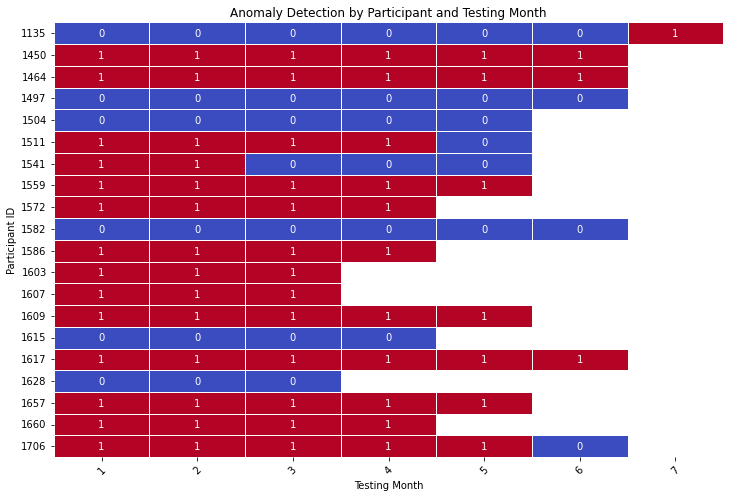

In [47]:
import seaborn as sns


unique_features = ['Inefficient_Ratio_Daytime', 'Inefficient_Ratio_Nighttime', 
                   'Inefficient_Ratio_Sundowning','Inefficient_Ratio_Total',  'Outings_days','Outings_hours']

# Create a feature map that assigns a unique integer to each contributing feature
feature_map = {feature: idx + 1 for idx, feature in enumerate(unique_features)}

for user_id, df in users_evaluation_dfs.items():
    df["Anomaly Indicator"] = df["Detected Anomaly"].astype(int)

# Update the heatmap data preparation
heatmap_data = []

for user_id, df in users_evaluation_dfs.items():
    df["User ID"] = user_id
    df = df.iloc[6:].reset_index(drop=True) 
    df["Testing Month"] = range(1, len(df) + 1)
    # Append to the heatmap data list with Testing Month and Anomaly Indicator
    heatmap_data.append(df[["User ID", "Testing Month", "Anomaly Indicator"]])

# Combine all users' data into a single DataFrame for visualization
combined_df = pd.concat(heatmap_data)

# Ensure that the Anomaly Indicator column is an integer
combined_df["Anomaly Indicator"] = combined_df["Anomaly Indicator"].astype(int)

# Pivot the data again for heatmap with Testing Month as the x-axis
heatmap_df = combined_df.pivot("User ID", "Testing Month", "Anomaly Indicator")

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_df, annot=True,  cmap="coolwarm", cbar=False, linewidths=.5)

plt.title("Anomaly Detection by Participant and Testing Month")
plt.xlabel("Testing Month")
plt.ylabel("Participant ID")
plt.xticks(rotation=45)
plt.show()

In [48]:
import pandas as pd

# Initialize a dictionary to store total ratios per user
user_feature_ratios = {}

# Calculate total ratios for each user
for user_id, df in users_evaluation_dfs.items():
    df = df.iloc[6:].reset_index(drop=True)  # Only consider testing months
    
    # Calculate the ratio of each feature across all testing months
    feature_ratios = {}
    for feature in df["Contributing Features"].dropna().unique():
        count_feature = df["Contributing Features"].apply(lambda x: feature in x if pd.notna(x) else False).sum()
        feature_ratio = count_feature / len(df)
        feature_ratios[feature] = feature_ratio
    
    user_feature_ratios[user_id] = feature_ratios

# # Display the total ratios for each user
# for user_id, ratios in user_feature_ratios.items():
#     print(f"User {user_id}:")
#     for feature, ratio in ratios.items():
#         print(f"  {feature}: {ratio:.2f}")


In [49]:
# Provided order of users
user_order = [1135, 1497, 1504, 
              1450, 1660, 1615, 
              1559, 1582, 1586,1617,
              1511, 1541,1607, 
              1603, 1609, 1628, 1657, 1464,  
              1572, 1706]

# Preparing the heatmap data to show each feature occurrence on a new line
heatmap_data = []

for user_id, df in users_evaluation_dfs.items():
    df = df.iloc[6:].reset_index(drop=True)  # Only consider testing months
    df["User ID"] = user_id
    df["Testing Month"] = range(1, len(df) + 1)  # Add Testing Month column
    df["Anomaly Indicator"] = df["Detected Anomaly"].astype(int)  # Add Anomaly Indicator column
    
    # List the features that occurred in each month, each feature on a new line
    df["Feature Occurrence"] = df["Contributing Features"].map(lambda x: "\n".join(x.split(';')) if pd.notna(x) else '')
    heatmap_data.append(df[["User ID", "Testing Month", "Anomaly Indicator", "Feature Occurrence"]])

# Combine all users' data into a single DataFrame for visualization
combined_df = pd.concat(heatmap_data)

# Reorder the DataFrame based on the user_order
combined_df["User ID"] = pd.Categorical(combined_df["User ID"], categories=user_order, ordered=True)
combined_df = combined_df.sort_values("User ID")

# # Pivot the data for heatmap with Testing Month as the x-axis
# heatmap_df = combined_df.pivot("User ID", "Testing Month", "Anomaly Indicator")

# # Create a corresponding annotation pivot for the heatmap
# annotation_df = combined_df.pivot("User ID", "Testing Month", "Feature Occurrence")

# plt.figure(figsize=(40, 33))

# # Plot the heatmap with feature occurrences, replacing underscores with spaces
# sns.heatmap(
#     heatmap_df,
#     annot=annotation_df.applymap(lambda x: x.replace('_', ' ').replace(',', '\n') if isinstance(x, str) else ''), 
#     fmt='', 
#     cmap="coolwarm", 
#     cbar=False, 
#     linewidths=.5,
#     annot_kws={"size": 16, "verticalalignment": "top", "horizontalalignment": "center"}  # Increased font size
# )

# plt.title("Contributing Feature Occurrences by Participants and Testing Month", fontsize=20)
# plt.xlabel("Testing Month", fontsize=18)
# plt.ylabel("Participants ID", fontsize=18)
# plt.xticks(rotation=45, fontsize=16)
# plt.yticks(rotation=0, fontsize=16)
# plt.show()


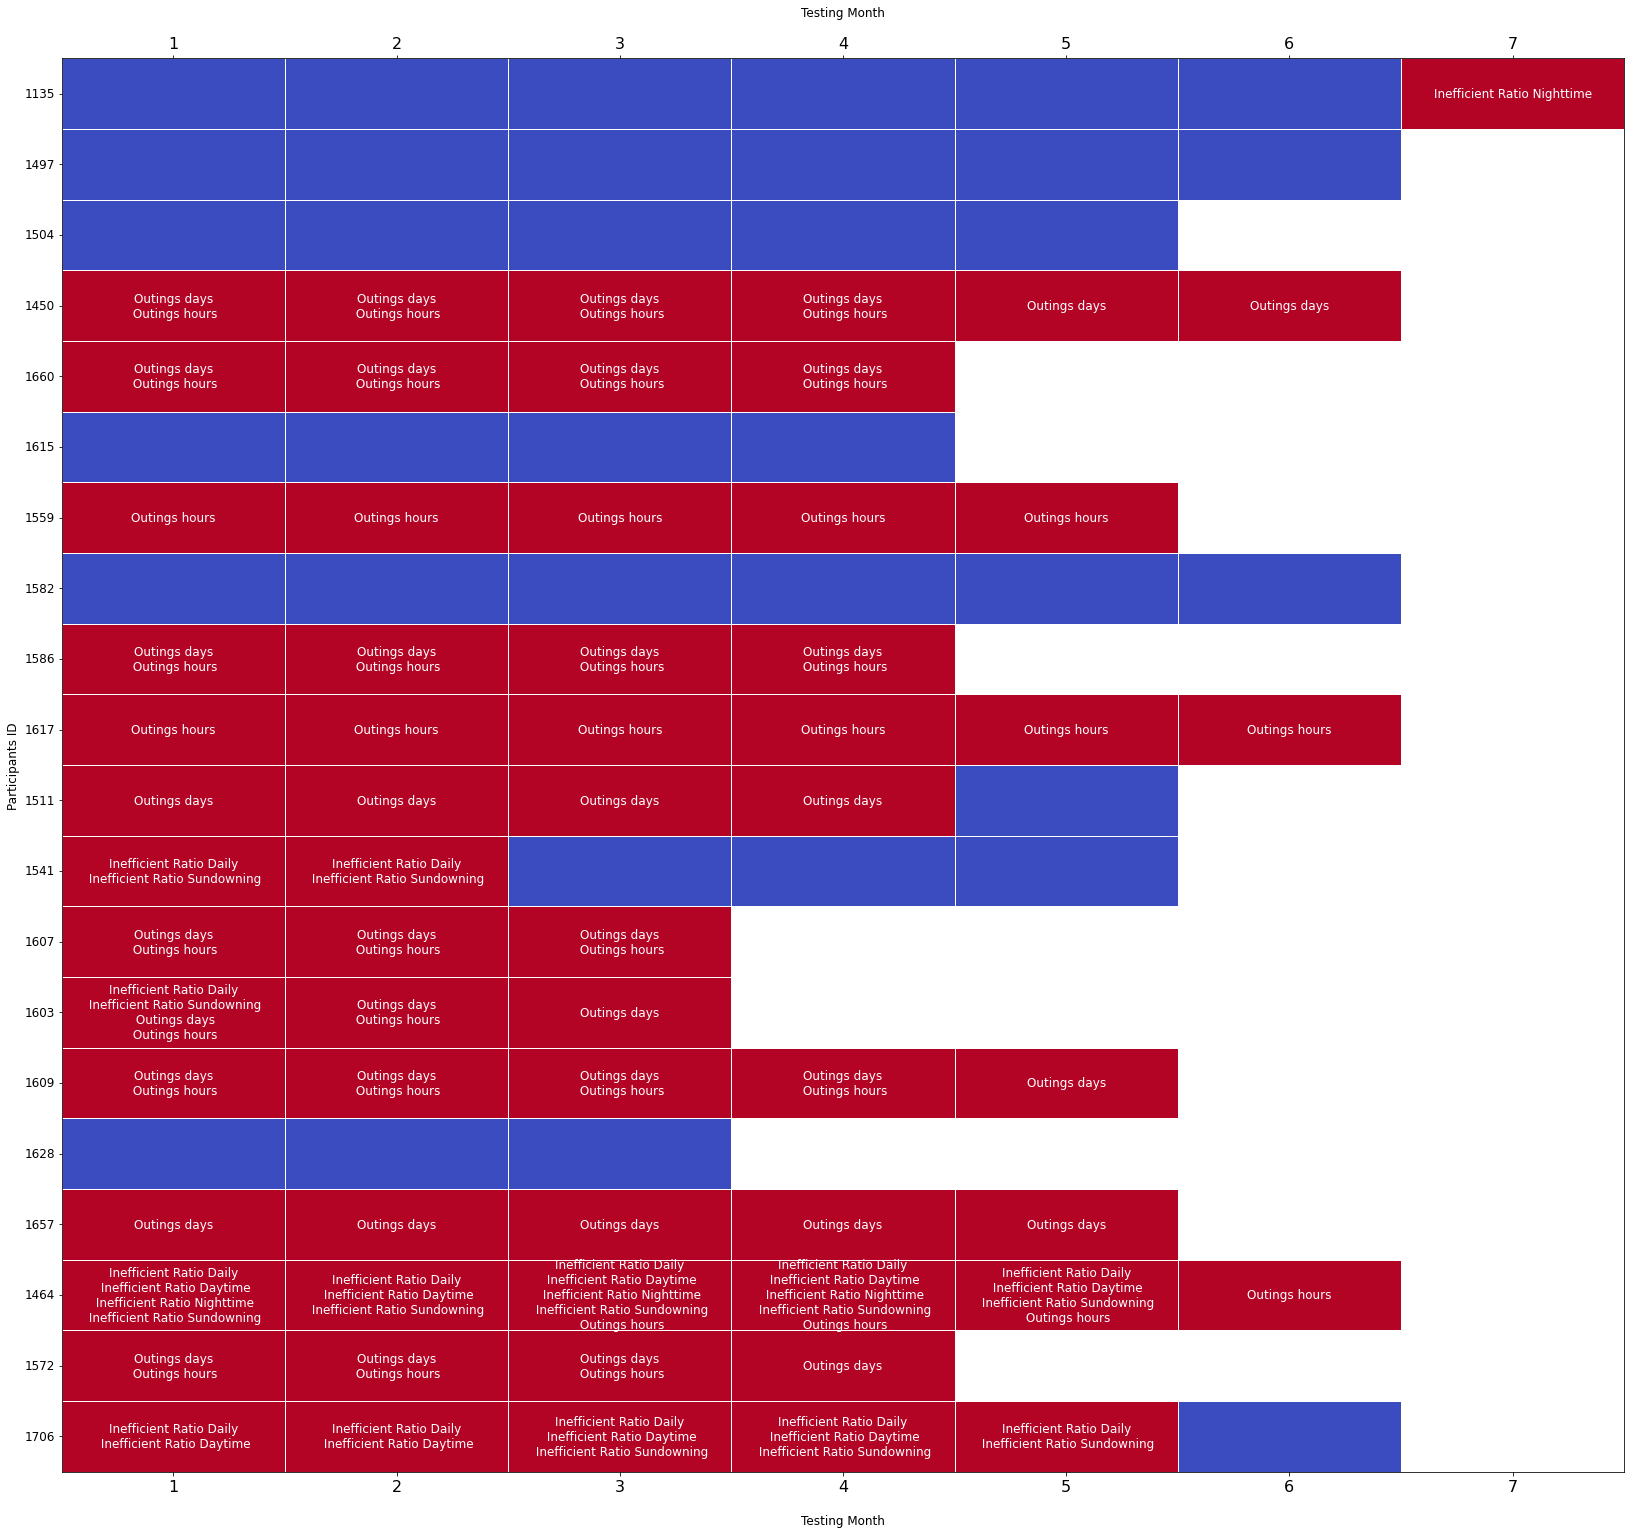

In [50]:
# Pivot the data for heatmap with Testing Month as the x-axis
heatmap_df = combined_df.pivot("User ID", "Testing Month", "Anomaly Indicator")

# Create a corresponding annotation pivot for the heatmap
annotation_df = combined_df.pivot("User ID", "Testing Month", "Feature Occurrence")

# Generate the heatmap


# # Manually apply the row colors based on the length of each row
# for idx, user_id in enumerate(heatmap_df.index):
#     row_length = heatmap_df.loc[user_id].count()  # Determine the length of this row (number of columns)
#     if user_id in [1450, 1660, 1615]:
#         ax.add_patch(plt.Rectangle((0, idx), row_length, 1, fill=False, edgecolor='yellow', lw=3))
#     if user_id in [1541, 1559, 1582, 1586, 1617]:
#         ax.add_patch(plt.Rectangle((0, idx), row_length, 1, fill=False, edgecolor='black', lw=3))
#     if user_id in [1511, 1607]:
#         ax.add_patch(plt.Rectangle((0, idx), row_length, 1, fill=False, edgecolor='orange', lw=3))


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming heatmap_df and annotation_df are defined

# Generate the heatmap
plt.figure(figsize=(28, 26))
ax = sns.heatmap(
    heatmap_df,
    annot=annotation_df.applymap(lambda x: x.replace('_', ' ').replace(',', '\n') if isinstance(x, str) else ''), 
    fmt='', 
    cmap="coolwarm", 
    cbar=False, 
    linewidths=.5,
    annot_kws={"size": 12, "verticalalignment": "top", "horizontalalignment": "center"}  # Increased font size for annotations
)

# Move the primary x-axis label and ticks to the top

ax.xaxis.tick_top()
ax.set_xlabel("Testing Month", fontsize=12, labelpad=20)  # Set label position at the top

# Set the x-axis tick labels for the top
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=16)

# Add a twin x-axis at the bottom for the bottom label
ax_bottom = ax.twiny()  # Create a twin x-axis sharing the same y-axis
ax_bottom.set_xticks(ax.get_xticks())  # Match the ticks with the top axis
ax_bottom.set_xlim(ax.get_xlim())  # Match the limits with the top axis
ax_bottom.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=16)
ax_bottom.set_xlabel("Testing Month", fontsize=12, labelpad=20)  # Set label position at the bottom

# Adjust y-axis labels for participants with consistent font
ax.set_ylabel("Participants ID", fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)  # Ensure y-tick labels match the label font size

plt.show()


In [51]:
xx

NameError: name 'xx' is not defined

In [ ]:
def clean_column_data(value):
    if isinstance(value, str):
        # Replace underscores with spaces and commas with newlines
        return value.replace('_', ' ').replace(',', '\n')
    return value

# Apply the cleaning function to all cells in the dataframe
df_cleaned = annotation_df.applymap(clean_column_data)


In [ ]:
# Define the path for the CSV file
csv_file_path = 'monthly_summary.xlsx'

# Save the cleaned and color-coded DataFrame to a new Excel file

df_cleaned.to_excel(csv_file_path, index=True)

In [ ]:
# Save DataFrame to CSV
df_cleaned.to_csv(csv_file_path, index=True)

In [ ]:
unique_features = ['Inefficient_Ratio_Daytime', 'Inefficient_Ratio_Nighttime', 
                   'Inefficient_Ratio_Sundowning','Inefficient_Ratio_Total',  'Outings_days','Outings_hours']

In [ ]:
# Initialize a dictionary to store total ratios per user
user_feature_ratios = {}


# Calculate total ratios for each user
for user_id, df in users_evaluation_dfs.items():
    df = df.iloc[6:].reset_index(drop=True)  # Only consider testing months
    
    # Initialize a dictionary to hold ratios for all features, starting with zero
    feature_ratios = {feature: 0 for feature in unique_features}
    
    # Calculate the ratio of each feature across all testing months
    for feature in unique_features:
        count_feature = df["Contributing Features"].apply(lambda x: feature in x if pd.notna(x) else False).sum()
        feature_ratio = count_feature / len(df)
        feature_ratios[feature] = feature_ratio
    
    user_feature_ratios[user_id] = feature_ratios

# Convert the dictionary to a DataFrame for easier visualization
ratios_df = pd.DataFrame(user_feature_ratios).T

   
# Round the ratios to 2 decimal places
ratios_df = ratios_df.round(2)

# Display the resulting DataFrame
ratios_df

In [ ]:
# Convert the resulting DataFrame to a LaTeX table
latex_table = ratios_df.to_latex(index=True, caption="Ratios of Contributing Features per Participant", label="tab:ratios", column_format="|c|" + "c|" * len(ratios_df.columns))

# Display the LaTeX table
print(latex_table)

In [ ]:
U1135=users_evaluation_dfs[1135]
# Selecting part of the columns
selected_columns = ['Month', 'Actual Health Status','Detected Anomaly']
U1135 = U1135[selected_columns]
U1135

In [ ]:
# Convert Month format to yyyy-mm
U1135['Month'] = pd.to_datetime(U1135['Month']).dt.strftime('%Y-%m')
U1135

In [ ]:
U1511 =users_evaluation_dfs[1511]
# Selecting part of the columns
selected_columns = ['Month', 'Actual Health Status','Detected Anomaly']
U1511 = U1511[selected_columns]
# Convert Month format to yyyy-mm
U1511['Month'] = pd.to_datetime(U1511['Month']).dt.strftime('%Y-%m')
U1511

In [ ]:
users_evaluation_dfs[1541]


In [ ]:
U1657 =users_evaluation_dfs[1657]
# Selecting part of the columns
selected_columns = ['Month', 'Actual Health Status','Detected Anomaly']
U1657 = U1657[selected_columns]
# Convert Month format to yyyy-mm
U1657['Month'] = pd.to_datetime(U1657['Month']).dt.strftime('%Y-%m')
U1657

In [ ]:
U1607 =users_evaluation_dfs[1607]
# Selecting part of the columns
selected_columns = ['Month', 'Actual Health Status','Detected Anomaly']
U1607 = U1607[selected_columns]
U1607

In [ ]:
U1541 =users_evaluation_dfs[1541]
# Selecting part of the columns
selected_columns = ['Month', 'Actual Health Status','Detected Anomaly']
U1541 = U1541[selected_columns]
U1541

# Convert Month format to yyyy-mm
U1607['Month'] = pd.to_datetime(U1607['Month']).dt.strftime('%Y-%m')
U1607

In [ ]:
users_evaluation_dfs[1450]

In [ ]:
unknown_healthy=[1559,1582,1586,1617]

def calculate_metrics(evaluation_df):
    no_change=Potential_Deterioration=tp = tn = fp = fn = delays = 0
    
    for _, row in evaluation_df.iterrows():
        actual = row['Actual Health Status']
        predicted = row['Predicted Health Status']
        features = row['Contributing Features']
        
        if (actual == 'Potential Healthy/MCI (Unknown)' or actual == 'Potential Healthy')  and (predicted != 'Potential Deterioration'):
            tn += 1  
                
            
        elif (actual == 'Potential Healthy/MCI (Unknown)' or actual == 'Potential Healthy')  and (predicted == 'Potential Deterioration'):
#             if features is not None and 'Inefficient' in features:
            fp += 1  # False Alert
#             else:
#                 tn += 1  
            
#         elif (actual == 'Potential Healthy')  and (predicted == 'Potential Deterioration'):
#             Potential_Deterioration += 1  
        
#         elif (actual == 'MCI')  and (predicted =='Potential Deterioration'):
#             tp  += 1
        
           
#         elif (actual == 'Potential MCI') and (predicted == 'Potential Deterioration'):
#             Potential_Deterioration += 1 
          
#         elif (actual == 'MCI')  and (predicted !='Potential Deterioration'):  
#             no_change+=1
            

#         elif (actual == 'Potential MCI') and (predicted !='Potential Deterioration'):
#             fn += 1  # Delay

    return tp, tn-6, fp, fn, Potential_Deterioration,no_change



In [ ]:

# Initialize lists to store metrics for all users
TNR, FPR,False_Alerts = [], [], []
for patient,user_evaluation_df in users_evaluation_dfs.items():
    if patient in list(unknown_healthy):
        tp, tn, fp, fn, Potential_Deterioration,no_change = calculate_metrics(user_evaluation_df)

        print("User", patient)
#         print(f"True Positives (TP): {tp}")
        print(f"True Negatives (TN): {tn}")
        print(f"False Alerts (FP): {fp}")
#         print(f"Delays/Fluctuations (FN): {fn}")
        precision, recall, accuracy, f1_score,specificity,tnv,fpr=calculate_performance_metrics(tp, tn, fp, fn)
        
#         Accuracy.append(accuracy)
        FPR.append(fpr)
        TNR.append(tnv)
        False_Alerts.append(fp)
#         Specificity.append(specificity)
#         print("Accuracy:", accuracy)
#         print("Precision:", precision)
#         print("Recall:", recall)
#         print("F1 Score:", f1_score)
#         print("Specificity:", specificity)
        print("TNR:", tnv)
        print("FPR:", fpr)
#         print(f"Potential_Deterioration (tp): {Potential_Deterioration}")
#         print(f"No change (MCI): {no_change}")
        print("\n")

# 2. From_healthy_to_mci_users

In [ ]:
def calculate_metrics(evaluation_df):
    no_change=Potential_Deterioration=tp = tn = fp = fn = delays = 0
    
    for _, row in evaluation_df.iterrows():
        actual = row['Actual Health Status']
        predicted = row['Predicted Health Status']

        if (actual == 'Potential Healthy')  and (predicted != 'Potential Deterioration'):
            tn += 1  
            
        elif (actual == 'Healthy')  and (predicted == 'Potential Deterioration'):
            fp += 1  # False Alert
            
            
        elif (actual == 'Potential Healthy')  and (predicted == 'Potential Deterioration'):
            Potential_Deterioration += 1  
        
        elif (actual == 'MCI')  and (predicted =='Potential Deterioration'):
            tp  += 1
        
           
       
          
        elif (actual == 'MCI')  and (predicted !='Potential Deterioration'):  
            no_change+=1
            

        elif (actual == 'MCI') and (predicted !='Potential Deterioration'):
            fn += 1  # Delay

    return tp, tn, fp, fn, Potential_Deterioration,no_change

In [ ]:
from_healthy_to_mci_users

In [ ]:
# Initialize lists to store metrics for all users
Accuracy, Precision, Recall, F1_score,Specificity = [], [], [], [],[]
for patient,user_evaluation_df in users_evaluation_dfs.items():
    if patient in list(from_healthy_to_mci_users):
        tp, tn, fp, fn, Potential_Deterioration,no_change = calculate_metrics(user_evaluation_df)
        
#         #Potential_Deterioration HERE IS actually TP here (no detoriation)
        tp+=Potential_Deterioration
        
        
        print("User", patient)
        print(f"True Positives (TP): {tp}")
        print(f"True Negatives (TN): {tn}")
        print(f"False Alerts (FP): {fp}")
        print(f"Delays/Fluctuations (FN): {fn}")
        
        precision, recall, accuracy, f1_score,specificity,tnv,fpr=calculate_performance_metrics(tp, tn, fp, fn)
        
        Accuracy.append(accuracy)
        Precision.append(precision)
        Recall.append(recall)
        F1_score.append(f1_score)
        Specificity.append(specificity)
        print("Accuracy:", accuracy)
#         print("Precision:", precision)
#         print("Recall:", recall)
#         print("F1 Score:", f1_score)
#         print("Specificity:", specificity)
        print("TNR:", tnv)
        print("FPR:", fpr)
#         print(f"Potential_Deterioration (tp): {Potential_Deterioration}")
#         print(f"No change (MCI): {no_change}")
        print("\n")


In [ ]:
test_list=[0,0.5,0]
cal_result(test_list)

In [ ]:
test_list=[2,4,4]
cal_result(test_list)

In [ ]:
#1511
users_evaluation_dfs[1511]

In [ ]:
#1607
users_evaluation_dfs[1607]

# 3. Remain_mci_users

For users who are always unhealthy, where true negatives (TN) will always be zero, we can focus on metrics that emphasize TP and FP. 

True Positive Rate (TPR) or Recall: 

* TPR=TP/(TP+FN)

 
This metric isn't applicable when TN is zero, but it's included here for completeness.

In [ ]:
def calculate_metrics(evaluation_df):
    no_change=Potential_Deterioration=tp = tn = fp = fn = delays = 0
    
    for _, row in evaluation_df.iterrows():
        actual = row['Actual Health Status']
        predicted = row['Predicted Health Status']

#         if (actual == 'Healthy' or actual == 'Potential Healthy')  and (predicted != 'Potential Deterioration'):
#             tn += 1  
            
#         elif (actual == 'Healthy')  and (predicted == 'Potential Deterioration'):
#             fp += 1  # False Alert
            
            
#         elif (actual == 'Potential Healthy')  and (predicted == 'Potential Deterioration'):
#             Potential_Deterioration += 1  
        
        if (actual == 'MCI' or actual == 'Potential MCI')  and (predicted !='Potential Deterioration'):
            tn  += 1
        
          
        
        elif (actual == 'MCI' or actual == 'Potential MCI')  and (predicted =='Potential Deterioration'):  
            fp += 1  # Delay

    return tp, tn-6, fp, fn, Potential_Deterioration,no_change

In [ ]:
physicalhealthy__mci_users=[1609,1628]

In [ ]:
# Initialize lists to store metrics for all users
TNR, FPR,False_Alerts = [], [], []
for patient,user_evaluation_df in users_evaluation_dfs.items():
    if patient in list(physicalhealthy__mci_users):
        tp, tn, fp, fn, Potential_Deterioration,no_change = calculate_metrics(user_evaluation_df)

        print("User", patient)
#         print(f"True Positives (TP): {tp}")
        print(f"True Negatives (TN): {tn}")
        print(f"False Alerts (FP): {fp}")
#         print(f"Delays/Fluctuations (FN): {fn}")
        precision, recall, accuracy, f1_score,specificity,tnv,fpr=calculate_performance_metrics(tp, tn, fp, fn)
        
#         Accuracy.append(accuracy)
        FPR.append(fpr)
        TNR.append(tnv)
        False_Alerts.append(fp)
#         Specificity.append(specificity)
#         print("Accuracy:", accuracy)
#         print("Precision:", precision)
#         print("Recall:", recall)
#         print("F1 Score:", f1_score)
#         print("Specificity:", specificity)
        print("TNR:", tnv)
        print("FPR:", fpr)
#         print(f"Potential_Deterioration (tp): {Potential_Deterioration}")
#         print(f"No change (MCI): {no_change}")
        print("\n")


In [ ]:
cal_result(TNR),cal_result(FPR),cal_result(False_Alerts)

In [ ]:
remain_mci_users

In [ ]:
remain_mci_users_update=[1464, 1603, 1657]

In [ ]:
calculate_metrics(users_evaluation_dfs[1464])

In [ ]:
# Initialize lists to store metrics for all users
TNR, FPR,False_Alerts = [], [], []
for patient,user_evaluation_df in users_evaluation_dfs.items():
    if patient in list(remain_mci_users_update):
        tp, tn, fp, fn, Potential_Deterioration,no_change = calculate_metrics(user_evaluation_df)

        print("User", patient)
#         print(f"True Positives (TP): {tp}")
        print(f"True Negatives (TN): {tn}")
        print(f"False Alerts (FP): {fp}")
#         print(f"Delays/Fluctuations (FN): {fn}")
        precision, recall, accuracy, f1_score,specificity,tnv,fpr=calculate_performance_metrics(tp, tn, fp, fn)
        
#         Accuracy.append(accuracy)
        FPR.append(fpr)
        TNR.append(tnv)
        False_Alerts.append(fp)
#         Specificity.append(specificity)
#         print("Accuracy:", accuracy)
#         print("Precision:", precision)
#         print("Recall:", recall)
#         print("F1 Score:", f1_score)
#         print("Specificity:", specificity)
        print("TNR:", tnv)
        print("FPR:", fpr)
#         print(f"Potential_Deterioration (tp): {Potential_Deterioration}")
#         print(f"No change (MCI): {no_change}")
        print("\n")


In [ ]:
TNR

In [ ]:
cal_result(TNR),cal_result(FPR),cal_result(False_Alerts)

In [ ]:
users_evaluation_dfs[1464]

In [ ]:
users_evaluation_dfs[1603]

In [ ]:
users_evaluation_dfs[1609]

In [ ]:
users_evaluation_dfs[1628]

In [ ]:
users_evaluation_dfs[1617]

In [ ]:
#1628
users_evaluation_dfs[1657]

In [ ]:
users_evaluation_dfs[1450]

## 4 Unknown users

In [ ]:
remain_mci_users

In [ ]:
physical_healthy=[1541,1559, 1572, 1582, 1586, 1592,1617, 1706]


In [ ]:
# Step 1: Identify Users in physical_healthy
for user in physical_healthy:
    if user in all_healthy:
        # Step 2: Retrieve the second date from all_healthy
        second_date = all_healthy[user][1]
        # Step 3: Filter rows in users_evaluation_dfs
        users_evaluation_dfs[user] = users_evaluation_dfs[user][users_evaluation_dfs[user]['Month'] <= second_date]

# Now users_evaluation_dfs contains the filtered data for applicable users.

In [ ]:
# Step 1: Identify Users in physical_healthy
for user in remain_mci_users:
    if user in remain_mci:
        # Step 2: Retrieve the second date from all_healthy
        second_date = remain_mci[user][1]
        # Step 3: Filter rows in users_evaluation_dfs
        users_evaluation_dfs[user] = users_evaluation_dfs[user][users_evaluation_dfs[user]['Month'] <= second_date]

users_evaluation_dfs[1464]

In [ ]:
import pandas as pd

# Initialize lists to store the results
users = []
statuses = []
total_months = []
total_no_change = []
total_potential_deterioration = []
prediction_lags = []
contributing_features = []

# Iterate through each user's DataFrame to compute the required metrics
for user, df in users_evaluation_dfs.items():
    users.append(user)
    
    if user in all_healthy_user:
        current_status = 'Healthy'
    elif user in remain_mci_users:
        current_status = 'MCI'
    elif user in from_healthy_to_mci_users:
        current_status = 'Healthy to MCI'
    else:
        current_status = 'Unknown'
    
    statuses.append(current_status)
    
    total_months.append(len(df))
    
    no_change_count = (df['Predicted Health Status'] == 'No change').sum()
    total_no_change.append(no_change_count)
    
    potential_deterioration_count = (df['Predicted Health Status'] == 'Potential Deterioration').sum()
    total_potential_deterioration.append(potential_deterioration_count)
    
    if current_status == 'Healthy to MCI':
        # Find the first occurrence of 'Potential Deterioration'
        try:
            prediction_lag = (df['Predicted Health Status'] == 'Potential Deterioration').idxmax() + 1
        except ValueError:
            prediction_lag = None
    else:
        prediction_lag = None
    prediction_lags.append(prediction_lag)
    
    # Initialize a dictionary to count occurrences of each contributing feature
    feature_counts = {}
    
    # Iterate over each row in the DataFrame
    for _, row in df[df['Detected Anomaly']].iterrows():
        # Get the contributing features for the current row
        features = row['Contributing Features']
        if pd.notna(features):
            for feature in features.split(', '):
                if feature in feature_counts:
                    feature_counts[feature] += 1
                else:
                    feature_counts[feature] = 1
    
    # Format the feature counts into a string
    formatted_features = ', '.join(f'{k}: {v}' for k, v in feature_counts.items())
    contributing_features.append(formatted_features)

# Create the data dictionary
data = {
    'User': users,
    'Status': statuses,
    'Total Months': total_months,
    'Total Deterioration': total_potential_deterioration,
    'Contributing Features': contributing_features
}

# Convert to DataFrame
result_df = pd.DataFrame(data)

# Display the DataFrame
result_df


In [ ]:
# Define the path for the CSV file
csv_file_path = 'result_summary.csv'

# Save DataFrame to CSV
result_df.to_csv(csv_file_path, index=False)



In [ ]:
xx

In [ ]:
# # Initialize lists to store the results
# users = []
# statuses = []
# total_months = []
# total_no_change = []
# total_potential_deterioration = []
# prediction_lags = []
# contributing_features = []

# # Iterate through each user's DataFrame to compute the required metrics
# for user, df in users_evaluation_dfs.items():
#     users.append(user)
    
#     if user in all_healthy_user:
#         current_status = 'Healthy'
#     elif user in remain_mci_users:
#         current_status = 'MCI'
#     elif user in from_healthy_to_mci_users:
#         current_status = 'Healthy to MCI'
#     else:
#         current_status = 'Unknown'
    
#     statuses.append(current_status)
    
#     total_months.append(len(df))
    
#     no_change_count = (df['Predicted Health Status'] == 'No change').sum()
#     total_no_change.append(no_change_count)
    
#     potential_deterioration_count = (df['Predicted Health Status'] == 'Potential Deterioration').sum()
#     total_potential_deterioration.append(potential_deterioration_count)
    
#     if current_status == 'Healthy to MCI':
#         prediction_lag = (df['Predicted Health Status'] == 'Potential Deterioration').idxmax() + 1
#     else:
#         prediction_lag = None
#     prediction_lags.append(prediction_lag)
    
#     features = df[df['Detected Anomaly']]['Contributing Features'].dropna().unique()
#     contributing_features.append('; '.join(features))

# # Create the data dictionary
# data = {
#     'User': users,
#     'Status': statuses,
#     'Total Months': total_months,
#     'Total No Change': total_no_change,
#     'Total Deterioration': total_potential_deterioration,
# #     'Prediction Lag': prediction_lags,
#     'Contributing Features': contributing_features
# }

# # Convert to DataFrame
# result_df = pd.DataFrame(data)

# # Display the result DataFrame
# print(result_df)

# # Convert to LaTeX table with formatting adjustments
# latex_table = result_df.to_latex(index=False, column_format='|l|l|c|c|c|l|')

# # Print the LaTeX table
# print(latex_table)

In [ ]:
# Initialize lists to store the results
users = []
statuses = []
total_months = []
total_no_change = []
total_potential_deterioration = []
prediction_lags = []
contributing_features = []

# Iterate through each user's DataFrame to compute the required metrics
for user, df in users_evaluation_dfs.items():
    users.append(user)
    
    if user in all_healthy_user:
        current_status = 'Healthy'
    elif user in remain_mci_users:
        current_status = 'MCI'
    elif user in from_healthy_to_mci_users:
        current_status = 'Healthy to MCI'
    else:
        current_status = 'Unknown'
    
    statuses.append(current_status)
    
    total_months.append(len(df))
    
    no_change_count = (df['Predicted Health Status'] == 'No change').sum()
    total_no_change.append(no_change_count)
    
    potential_deterioration_count = (df['Predicted Health Status'] == 'Potential Deterioration').sum()
    total_potential_deterioration.append(potential_deterioration_count)
    
    if current_status == 'Healthy to MCI':
        prediction_lag = (df['Predicted Health Status'] == 'Potential Deterioration').idxmax() + 1
    else:
        prediction_lag = None
    prediction_lags.append(prediction_lag)
    
    # Ensure uniqueness of contributing features
    features = df[df['Detected Anomaly']]['Contributing Features'].dropna().unique()
    unique_features = set()
    for feature in features:
        unique_features.update(feature.split(', '))
    formatted_features = [f.replace('_', ' ') for f in unique_features]
    contributing_features.append('\\makecell{' + ' \\\\ '.join(formatted_features) + '}')

# Create the data dictionary
data = {
    'User': users,
    'Status': statuses,
    'Total Months': total_months,
    'Total Deterioration': total_potential_deterioration,
    'Contributing Features': contributing_features
}

# Convert to DataFrame
result_df = pd.DataFrame(data)

# Sort by Status
status_order = {'Healthy': 1, 'MCI': 2, 'Healthy to MCI': 3, 'Unknown': 4}
result_df['Status Order'] = result_df['Status'].map(status_order)
result_df.sort_values(by='Status Order', inplace=True)
result_df.drop('Status Order', axis=1, inplace=True)

# Ensure full text display for contributing_features in the LaTeX table
pd.set_option('display.max_colwidth', None)

# Convert to LaTeX table with formatting adjustments
latex_table = result_df.to_latex(
    index=False, 
    column_format='|l|l|c|c|p{8cm}|',  # Adjusted column format
    header=True,
    longtable=True,
    escape=False  # To allow LaTeX formatting
)

# Adjust the LaTeX table format
latex_table = latex_table.replace('\\toprule', '\\hline')
latex_table = latex_table.replace('\\midrule', '\\hline')
latex_table = latex_table.replace('\\bottomrule', '\\hline')
latex_table = latex_table.replace('\\begin{longtable}', '\\begin{table}[ht]\\centering\\resizebox{\\textwidth}{!}{%\\begin{tabular}')
latex_table = latex_table.replace('\\end{longtable}', '\\end{tabular}}\\end{table}')
latex_table = latex_table.replace(
    '{|l|l|c|c|p{8cm}|}\n\\hline\n',
    '{|l|l|c|c|p{8cm}|}\n\\hline\n \\textbf{User} &  \\textbf{Cognitive Status} &  \\textbf{Observed Months} &  \\textbf{\\makecell{Months Detected as \\\\Deterioration}} &  \\textbf{Contributing Features} \\\\ \\hline\n'
)

# Add \hline after each row
latex_table_rows = latex_table.splitlines()
new_latex_table = []
for row in latex_table_rows:
    new_latex_table.append(row)
    if '\\\\' in row and not row.startswith('\\hline'):
        new_latex_table.append('\\hline')

final_latex_table = '\n'.join(new_latex_table)

# Add font size command at the beginning and end of the table
final_latex_table = "\\small\n" + final_latex_table + "\n\\normalsize"

# Print the final LaTeX table
print(final_latex_table)


In [ ]:
result_df[result_df['User']==1450]['Contributing Features'].unique()

In [ ]:
xx